<div class="row">
      
      
  <div class="colA"><p style="background:#800000; padding:25px; font-size:20px; text-align:center"></span><span style="width:50%; font-size:40px; font-style:normal;text-align:center"><font color=#FFF>Projet : Prédiction du risque de crédit</span><br></div>
      
</div><p style="background:#FFF; padding:12px; font-size:20px;text-align:right"><span style="width:50%; font-size:20px;font-family:'Arial Narrow';text-align:left"><font color=#800000>Benjamin Baillet, Alexandra Millot et Ismail Ouazzani </span>
      
      
      
<p style="background:#000000; padding:1px; font-size:1px"></p>

    
<br>

**Objectif :** Concevoir pour une banque un outil automatisé permettant de simplifier et d'optimiser le processus d'octroi de crédit à ses futurs clients.

**La Banque nous a fixé les objectifs suivants :**

1) Effectuer une analyse descriptive des données bancaires

2) Réaliser une grille de score pour l’octroi des crédits à la consommation

3) Proposer un modèle de Machine Learning pour challenger la grille de score

<h2 style="padding:16px; color:#FFF; background:#800000; font-size:27px"> Importation des librairies et des données</h2>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import optuna
import shap
import statsmodels.api as sm
import xgboost as xgb

from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from scipy.spatial import ConvexHull
from scipy.stats import ttest_ind, chi2_contingency, kurtosis, normaltest 
from scipy.stats import norm, f_oneway, kurtosis, skew, kstest

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, auc, roc_curve, roc_auc_score, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.experimental import enable_hist_gradient_boosting  
from sklearn.linear_model import LogisticRegression


import warnings

# Ignorer tous les warnings
warnings.filterwarnings("ignore")

La base de données utilisé est l'historique des crédits  d'une banque, effectués
par ses clients, avec des informations personnelles sur le client et s’il a fait défaut ou non pendant la période de remboursement du crédit. Les données contiennent les informations ci-dessous :

- `SK_ID_CURR` : identifiant du client
- `GOOD_PAYER` : 1 s’il n’y a pas eu de retard de remboursement, 0 sinon
- `CODE_GENDER` : le genre du client
- `FLAG_OWN_CAR` : le client possède une voiture
- `FLAG_OWN_REALTY` : le client est propriétaire
- `CNT_CHILDREN` : nombre d’enfant du client
- `AMT_INCOME_TOTAL` : les revenus du client
- `AMT_CREDI` : le montant du crédit
- `AMT_GOODS_PRIC` : le montant du produit pour lequel le crédit a été pris
- `NAME_INCOME_TYP` : le type de revenus du client
- `NAME_EDUCATION_TYPE` : niveau académique du client
- `NAME_FAMILY_STATU`: status familial du client
- `NAME_CONTRACT_TYPE` : crédit comptant ou en revolving
- `NAME_HOUSING_TYPE` : situation habitat
- `TOTALAREA_MODE` : surface normalisée d’habitation
- `DAYS_BIRTH` : Age du client
- `DAYS_EMPLOYED` : nombre d’année consécutif du dernier emploi du client
- `OCCUPATION_TYPE` : profession du client
- `ORGANIZATION_TYPE` : secteur d’emploi
- `EXT_SOURCE_` : score de crédit bureau 1
- `EXT_SOURCE_2` : score de crédit bureau 2
- `EXT_SOURCE_3` : score de crédit bureau 3
- `AMT_REQ_CREDIT_BUREAU_YEARS` : nombre de demande de crédit effectué par le client dans l’année précédente

In [11]:
file_path = "client_credit_granting.csv" 
data = pd.read_csv(file_path)

# Affichage des premières lignes 
print("Aperçu des données :")
data

Aperçu des données :


,SK_ID_CURR,GOOD_PAYER,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_GOODS_PRICE,NAME_INCOME_TYPE,...,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,ORGANIZATION_TYPE,TOTALAREA_MODE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,0,M,N,Y,0,202500.0,406597.5,351000.0,Working,...,House / apartment,-9461,-637,Laborers,Business Entity Type 3,0.0149,0.083037,0.262949,0.139376,1.0
1,100003,1,F,N,N,0,270000.0,1293502.5,1129500.0,State servant,...,House / apartment,-16765,-1188,Core staff,School,0.0714,0.311267,0.622246,NaN,0.0
2,100004,1,M,Y,Y,0,67500.0,135000.0,135000.0,Working,...,House / apartment,-19046,-225,Laborers,Government,NaN,NaN,0.555912,0.729567,0.0
3,100006,1,F,N,Y,0,135000.0,312682.5,297000.0,Working,...,House / apartment,-19005,-3039,Laborers,Business Entity Type 3,NaN,NaN,0.650442,NaN,NaN
4,100007,1,M,N,Y,0,121500.0,513000.0,513000.0,Working,...,House / apartment,-19932,-3038,Core staff,Religion,NaN,NaN,0.322738,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,1,M,N,N,0,157500.0,254700.0,225000.0,Working,...,With parents,-9327,-236,Sales staff,Services,0.2898,0.145570,0.681632,NaN,NaN
307507,456252,1,F,N,Y,0,72000.0,269550.0,225000.0,Pensioner,...,House / apartment,-20775,365243,NaN,XNA,0.0214,NaN,0.115992,NaN,NaN
307508,456253,1,F,N,Y,0,153000.0,677664.0,585000.0,Working,...,House / apartment,-14966,-7921,Managers,School,0.7970,0.744026,0.535722,0.218859,1.0
307509,456254,0,F,N,Y,0,171000.0,370107.0,319500.0,Commercial associate,...,House / apartment,-11961,-4786,Laborers,Business Entity Type 1,0.0086,NaN,0.514163,0.661024,0.0


<h2 style="padding:16px; color:#FFF; background:#800000; font-size:27px"> Objectif 1 : analyser les données dans le but de décrire le portfolio des clients pour la Banque</h2>

# Analyse univariée et bivariée

Pour répondre à l'objectif n°1 fixé par la Banque nous allons commencer par une **analyse univariée et bivariée** de nos données

In [3]:
data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   SK_ID_CURR                  307511 non-null  int64  
 1   GOOD_PAYER                  307511 non-null  int64  
 2   CODE_GENDER                 307511 non-null  object 
 3   FLAG_OWN_CAR                307511 non-null  object 
 4   FLAG_OWN_REALTY             307511 non-null  object 
 5   CNT_CHILDREN                307511 non-null  int64  
 6   AMT_INCOME_TOTAL            307511 non-null  float64
 7   AMT_CREDIT                  307511 non-null  float64
 8   AMT_GOODS_PRICE             307233 non-null  float64
 9   NAME_INCOME_TYPE            307511 non-null  object 
 10  NAME_CONTRACT_TYPE          307511 non-null  object 
 11  NAME_EDUCATION_TYPE         307511 non-null  object 
 12  NAME_FAMILY_STATUS          307511 non-null  object 
 13  NAME_HOUSING_T

**Nous disposons d'un total de :**
- **307 511 clients**
- **22 caractéristiques** à prendre en compte avec 3 types de données différentes (entiers, flottants et objets)

## Traitement des données

Avant de commencer, procédons au traitement des données afin d'obtenir une base claire et facile à analyser. Nous débutons par les variables `DAYS_BIRTH` et `DAYS_EMPLOYED`, dont les valeurs ne sont pas très intuitives :

In [4]:
print(data[['DAYS_BIRTH', 'DAYS_EMPLOYED']].head())

   DAYS_BIRTH  DAYS_EMPLOYED
0       -9461           -637
1      -16765          -1188
2      -19046           -225
3      -19005          -3039
4      -19932          -3038


- `DAYS_BIRTH` : Les valeurs sont exprimées en nombre de jours négatifs, ce qui représente l'âge de l'individu (par rapport à une référence). Pour une meilleure analyse nous allons la convertir en années.
- `DAYS_EMPLOYED` : Les valeurs négatives indiquent l'ancienneté en jours. Nous allons convertir ces valeurs en années d'ancienneté positives.

In [5]:
data['AGE_YEARS'] = (-data['DAYS_BIRTH'] / 365).round(1)
print(data[['DAYS_BIRTH', 'AGE_YEARS']].head())

   DAYS_BIRTH  AGE_YEARS
0       -9461       25.9
1      -16765       45.9
2      -19046       52.2
3      -19005       52.1
4      -19932       54.6


Avant de traiter la variable `DAYS_EMPLOYED`, nous remarquons qu'une valeur par défaut, `365243`, a été attribuée à certains clients. Cette valeur semble correspondre aux individus retraités, ce que nous allons vérifier immédiatement :

In [6]:
pensioners_with_default = data[(data['DAYS_EMPLOYED'] == 365243) & (data['NAME_INCOME_TYPE'] == 'Pensioner')]
print(pensioners_with_default[['DAYS_EMPLOYED', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE']].head())

    DAYS_EMPLOYED NAME_INCOME_TYPE OCCUPATION_TYPE
8          365243        Pensioner             NaN
11         365243        Pensioner             NaN
23         365243        Pensioner             NaN
38         365243        Pensioner             NaN
43         365243        Pensioner             NaN


Notre observation confirme que les valeurs de `DAYS_EMPLOYED` égales à 365243 sont fortement liées aux retraités (Pensioner) et que ces individus n'ont pas de métier renseigné (`OCCUPATION_TYPE` = `NaN`). Cela correspond bien à la logique que cette valeur est une valeur par défaut utilisée pour signaler des situations particulières (retraités sans emploi actif).

Nous avons décidé de remplacer la valeur `365243` par `0`, indiquant l'absence d'emploi actif, afin d'éviter l'introduction d'un biais artificiel dans les données.

In [7]:
# Remplacer 365243 par 0 pour les retraités
data.loc[data['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = 0

# Recalculer YEARS_EMPLOYED
data['YEARS_EMPLOYED'] = (-data['DAYS_EMPLOYED'] / 365).round(1)
print(data[['DAYS_EMPLOYED', 'YEARS_EMPLOYED']].head())

   DAYS_EMPLOYED  YEARS_EMPLOYED
0           -637             1.7
1          -1188             3.3
2           -225             0.6
3          -3039             8.3
4          -3038             8.3


Ces deux colonnes ne sont plus nécessaires, nous les retirons donc de notre analyse :

In [8]:
data.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'], inplace=True)

Nous constatons également que les retraités présentent des valeurs `NaN` dans la colonne `OCCUPATION_TYPE`, ce qui est compréhensible puisqu'ils ne travaillent plus. Cependant, il serait pertinent de les distinguer de ceux qui n'ont pas renseigné leur poste. Pour cela, nous remplacerons les `NaN` par la catégorie `Retraité` :

In [9]:
data.loc[data['NAME_INCOME_TYPE'] == 'Pensioner', 'OCCUPATION_TYPE'] = 'Retraité'

Une autre variable intéressante à traiter est `CNT_CHILDREN` en effet :

In [10]:
data['CNT_CHILDREN'].describe()

count    307511.000000
mean          0.417052
std           0.722121
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          19.000000
Name: CNT_CHILDREN, dtype: float64

Il est peu probable que la valeur maximale soit réaliste. Pour éviter les anomalies, nous allons limiter le nombre d'enfants à un maximum de 6.

In [11]:
max_children_threshold = 6
data.loc[data['CNT_CHILDREN'] > max_children_threshold, 'CNT_CHILDREN'] = max_children_threshold

Voici une desciption des données après ce premier traitement : 

In [12]:
data.drop(['SK_ID_CURR', 'GOOD_PAYER'], axis=1).describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_GOODS_PRICE,TOTALAREA_MODE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,YEARS_EMPLOYED
count,307511.000000,3.075110e+05,3.075110e+05,3.072330e+05,159080.000000,134133.000000,3.068510e+05,246546.000000,265992.000000,307511.000000,307511.000000
mean,0.416753,1.687979e+05,5.990260e+05,5.383962e+05,0.102547,0.502130,5.143927e-01,0.510853,1.899974,43.936992,5.355694
std,0.718240,2.371231e+05,4.024908e+05,3.694465e+05,0.107462,0.211062,1.910602e-01,0.194844,1.869295,11.956084,6.320809
min,0.000000,2.565000e+04,4.500000e+04,4.050000e+04,0.000000,0.014568,8.173617e-08,0.000527,0.000000,20.500000,0.000000
25%,0.000000,1.125000e+05,2.700000e+05,2.385000e+05,0.041200,0.334007,3.924574e-01,0.370650,0.000000,34.000000,0.800000
50%,0.000000,1.471500e+05,5.135310e+05,4.500000e+05,0.068800,0.505998,5.659614e-01,0.535276,1.000000,43.200000,3.300000
75%,1.000000,2.025000e+05,8.086500e+05,6.795000e+05,0.127600,0.675053,6.636171e-01,0.669057,3.000000,53.900000,7.600000
max,6.000000,1.170000e+08,4.050000e+06,4.050000e+06,1.000000,0.962693,8.549997e-01,0.896010,25.000000,69.100000,49.100000


***Remarques:***

- Dans la variable `AMT_INCOME_TOTAL`, la valeur du max est  1.170000e+08 et elle est très éloignée des autres. Nous traiterons cela dans la partie **Valeurs extrêmes**.

---

## Valeurs manquantes

Nous débutons par le traitement des données, en nous concentrant d'abord sur les valeurs manquantes. Pour cela, identifions le nombre et le pourcentage de valeurs manquantes pour chaque variable :

In [13]:
print(data.isnull().sum().to_frame('Effectif').assign(Pourcentage=lambda x: x['Effectif'] / len(data) * 100).query('Effectif > 0').sort_values('Pourcentage', ascending=False))

                            Effectif  Pourcentage
EXT_SOURCE_1                  173378    56.381073
TOTALAREA_MODE                148431    48.268517
EXT_SOURCE_3                   60965    19.825307
AMT_REQ_CREDIT_BUREAU_YEAR     41519    13.501631
OCCUPATION_TYPE                41034    13.343913
EXT_SOURCE_2                     660     0.214626
AMT_GOODS_PRICE                  278     0.090403


Nous observons que **7 variables présentent des valeurs manquantes**, représentant entre 0,09 % et 56,38 % des données.

L'objectif est de les éliminer tout en conservant un maximum d'informations et en réduisant au minimum le biais lié au traitement de ces valeurs manquantes.

Dans un premier temps, nous avons décidé de supprimer les colonnes contenant plus de 40 % de valeurs manquantes. Cela concerne les variables suivantes : `EXT_SOURCE_1` (56.38%) et `TOTALAREA_MODE` (48.26%)

In [14]:
data.drop(columns=(cols := data.isnull().mean().mul(100).loc[lambda x: x > 40].index), inplace=True)
print(f"Colonnes supprimées : {list(cols)}")

Colonnes supprimées : ['TOTALAREA_MODE', 'EXT_SOURCE_1']


Pour les variables restantes, nous avons utilisé des **méthodes d'imputation adaptées au type et au contexte des données** :
- **Imputation conditionnelle :** Certaines variables, comme `OCCUPATION_TYPE` et `AMT_GOODS_PRIC`, ont été imputées en fonction d'autres variables pertinentes, telles que `NAME_INCOME_TYPE` ou `AMT_CREDIT`. Cette méthode permet de réduire le biais en utilisant des relations logiques ou contextuelles entre les variables.
- **KNN Imputation (k-nearest neighbors) :** Pour les variables numériques, nous avons utilisé un modèle basé sur les k plus proches voisins. Cette technique estime les valeurs manquantes en s'appuyant sur des observations similaires dans le dataset.
- **Imputation catégorielle :** Pour les variables catégorielles, les valeurs manquantes ont été remplacées par une catégorie spéciale (`"Inconnu"`) ou la catégorie la plus fréquente.

In [15]:
# Imputation conditionnelle pour OCCUPATION_TYPE
if 'OCCUPATION_TYPE' in data.columns:
    data['OCCUPATION_TYPE'] = data.groupby('NAME_INCOME_TYPE')['OCCUPATION_TYPE'].transform(
        lambda x: x.fillna("Retraité" if x.name == "Pensioner" else x.mode().iloc[0] if not x.mode().empty else "Inconnu")
    )
    print("Imputation conditionnelle réalisée pour OCCUPATION_TYPE.")

# Imputation conditionnelle pour AMT_GOODS_PRICE
if 'AMT_GOODS_PRICE' in data.columns:
    data['AMT_GOODS_PRICE'] = data.groupby('AMT_CREDIT')['AMT_GOODS_PRICE'].transform(
        lambda x: x.fillna(x.median())
    )
    # Remplacer les NaN restants par la médiane globale
    data['AMT_GOODS_PRICE'].fillna(data['AMT_GOODS_PRICE'].median(), inplace=True)
    print("Imputation conditionnelle réalisée pour AMT_GOODS_PRICE.")

# Imputation des valeurs manquantes numériques avec KNN
num_cols = [col for col in data.select_dtypes(include=['float64', 'int64']).columns if data[col].isnull().any()]
if num_cols:
    imputer = KNNImputer(n_neighbors=5)
    data[num_cols] = imputer.fit_transform(data[num_cols])
    print("KNN Imputation réalisée pour les colonnes numériques.")

# Remplissage des valeurs manquantes pour les colonnes catégoriques
cat_cols = [col for col in data.select_dtypes(include='object').columns if data[col].isnull().any()]
for col in cat_cols:
    data[col].fillna("Inconnu", inplace=True)
    print(f"Imputation catégorielle réalisée pour {col}.")

# Vérification finale des valeurs manquantes
final_missing = data.isnull().sum().sum()
print(f"\nValeurs manquantes restantes après traitement : {final_missing}")


Imputation conditionnelle réalisée pour OCCUPATION_TYPE.
Imputation conditionnelle réalisée pour AMT_GOODS_PRICE.
KNN Imputation réalisée pour les colonnes numériques.

Valeurs manquantes restantes après traitement : 0


Certaines variables contiennent des modalités particulières, telles que XNA dans la variable `CODE_GENDER` (4 occurrences) ou Unknown dans la variable `NAME_FAMILY_STATUS` (2 occurrences). Étant donné leur faible proportion, nous pouvons nous permettre de supprimer ces lignes :

In [16]:
# Liste des conditions à exclure
exclusions = {
    'CODE_GENDER': ['XNA'],
    'NAME_FAMILY_STATUS': ['Unknown'],
    'OCCUPATION_TYPE': ['Inconnu'],
    'ORGANIZATION_TYPE': ['XNA']
}

data = data[~data[list(exclusions)].isin(exclusions).any(axis=1)]

Avant de procéder au traitement des valeurs aberrantes, nous commencerons par identifier et supprimer les doublons :

In [17]:
# Vérifier les doublons exacts
print(f"Nombre de doublons exacts avant correction : {data.duplicated().sum()}")

# Supprimer les doublons exacts
data = data.drop_duplicates()

# Vérifier les doublons par clé unique
if 'SK_ID_CURR' in data.columns:
    print(f"Nombre de doublons basés sur SK_ID_CURR avant correction : {data.duplicated(subset=['SK_ID_CURR']).sum()}")
    data = data.drop_duplicates(subset=['SK_ID_CURR'], keep='first')

# Vérification finale
print(f"Nombre total de lignes après correction : {len(data)}")
print(f"Nombre de doublons exacts après correction : {data.duplicated().sum()}")

Nombre de doublons exacts avant correction : 0
Nombre de doublons basés sur SK_ID_CURR avant correction : 0
Nombre total de lignes après correction : 252131
Nombre de doublons exacts après correction : 0


___

## Valeurs extrêmes

Maintenant que le traitement des valeurs manquantes est terminé, nous allons nous concentrer sur les valeurs aberrantes. 

Tout d'abord, il est essentiel d'identifier les variables susceptibles de contenir des valeurs extrêmes. Les variables binaires, quant à elles, peuvent être exclues du traitement.

In [18]:
# Identifier les colonnes binaires
binary_cols = [col for col in data.columns if data[col].nunique() == 2]
print(f"Colonnes binaires : {binary_cols}")

Colonnes binaires : ['GOOD_PAYER', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_CONTRACT_TYPE']


Ces variables ont uniquement deux résultats possibles et, par conséquent, ne peuvent pas contenir de valeurs aberrantes.

Sans compter que nous avons déjà traiter la variable `CNT_CHILDREN`. Pour voir si des variables sembles possèder des valeurs aberrantes nous pouvons exécuter à nouveau le desciptif de chaque variable :

In [19]:
data.drop(['SK_ID_CURR', 'GOOD_PAYER'], axis=1).describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_GOODS_PRICE,EXT_SOURCE_2,EXT_SOURCE_3,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,YEARS_EMPLOYED
count,252131.000000,2.521310e+05,2.521310e+05,2.521310e+05,2.521310e+05,252131.000000,252131.000000,252131.000000,252131.000000
mean,0.498182,1.759127e+05,6.114017e+05,5.491363e+05,5.161346e-01,0.505557,1.869441,40.463558,6.531867
std,0.759117,2.588540e+05,4.065310e+05,3.732296e+05,1.897652e-01,0.180960,1.729524,10.034488,6.406488
min,0.000000,2.565000e+04,4.500000e+04,4.050000e+04,8.173617e-08,0.000527,0.000000,20.500000,0.000000
25%,0.000000,1.125000e+05,2.779695e+05,2.475000e+05,3.985874e-01,0.389339,1.000000,32.300000,2.100000
50%,0.000000,1.575000e+05,5.212800e+05,4.500000e+05,5.667831e-01,0.524496,1.600000,39.900000,4.500000
75%,1.000000,2.115000e+05,8.293320e+05,6.930000e+05,6.637635e-01,0.641368,3.000000,48.100000,8.700000
max,6.000000,1.170000e+08,4.050000e+06,4.050000e+06,8.549997e-01,0.893976,23.000000,69.000000,49.100000


Selon ce tableau, les variables `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `YEARS_EMPLOYED`, `AMT_REQ_CREDIT_BUREAU_YEAR` et `AMT_GOODS_PRICE` présentent des valeurs extrêmes. Pour les traiter, nous appliquerons l'**IQR (Interquartile Range)**, une méthode univariée couramment utilisée pour détecter les valeurs aberrantes de manière indépendante pour chaque colonne : 

In [20]:
columns_to_treat = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'YEARS_EMPLOYED', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'AMT_GOODS_PRICE']

for col in columns_to_treat:
    Q1, Q3 = data[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    data[col] = data[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    print(f"Valeurs extrêmes restantes pour {col} : {((data[col] < Q1 - 1.5 * IQR) | (data[col] > Q3 + 1.5 * IQR)).sum()}")

Valeurs extrêmes restantes pour AMT_INCOME_TOTAL : 0
Valeurs extrêmes restantes pour AMT_CREDIT : 0
Valeurs extrêmes restantes pour YEARS_EMPLOYED : 0
Valeurs extrêmes restantes pour AMT_REQ_CREDIT_BUREAU_YEAR : 0
Valeurs extrêmes restantes pour AMT_GOODS_PRICE : 0


Voici le tableau mis à jour des variables après le traitement des valeurs extrêmes :

In [21]:
data.drop(['SK_ID_CURR', 'GOOD_PAYER'], axis=1).describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_GOODS_PRICE,EXT_SOURCE_2,EXT_SOURCE_3,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,YEARS_EMPLOYED
count,252131.000000,252131.000000,2.521310e+05,2.521310e+05,2.521310e+05,252131.000000,252131.000000,252131.000000,252131.000000
mean,0.498182,169972.396942,6.050282e+05,5.386749e+05,5.161346e-01,0.505557,1.833744,40.463558,6.133831
std,0.759117,76009.703456,3.852664e+05,3.408979e+05,1.897652e-01,0.180960,1.616399,10.034488,5.173739
min,0.000000,25650.000000,4.500000e+04,4.050000e+04,8.173617e-08,0.000527,0.000000,20.500000,0.000000
25%,0.000000,112500.000000,2.779695e+05,2.475000e+05,3.985874e-01,0.389339,1.000000,32.300000,2.100000
50%,0.000000,157500.000000,5.212800e+05,4.500000e+05,5.667831e-01,0.524496,1.600000,39.900000,4.500000
75%,1.000000,211500.000000,8.293320e+05,6.930000e+05,6.637635e-01,0.641368,3.000000,48.100000,8.700000
max,6.000000,360000.000000,1.656376e+06,1.361250e+06,8.549997e-01,0.893976,6.000000,69.000000,18.600000


---

In [22]:
# Sauvegarde des données traitées
#data.to_csv('good_data.csv', index=False)
#data.to_parquet('good_data.parquet', index=False)

# Rechargement des données traitées
# Recharger depuis CSV
# data = pd.read_csv('good_data.csv')

# Recharger depuis Parquet
#data_parquet = pd.read_parquet('good_data.parquet')

___
## Distribution des variables

Il est également intéressant d'examiner la distribution des variables, notamment en analysant des indicateurs tels que la kurtosis (aplatissement) et la skewness (asymétrie), ainsi qu'en testant leur normalité. Pour chaque variable, nous calculons les statistiques suivantes :

- **Kurtosis** : Mesure de l'aplatissement de la distribution par rapport à une distribution normale.
- **Skewness** : Évalue l'asymétrie de la distribution.
- **Statistique de Shapiro-Wilk** : Permet de tester la normalité de la distribution.
- **P-Value du test de Shapiro-Wilk** : Indique si la distribution peut être considérée comme normale (P > 0.05).

Enfin, chaque variable sera marquée comme "Normale" ou "Non Normale" en fonction des résultats du test de Shapiro-Wilk. Cette analyse nous permet de mieux comprendre la nature des données et d'adapter les approches analytiques ou statistiques en conséquence.

In [23]:
# Pour les variables numériques
def analyze_distribution_ks(data):
    return pd.DataFrame([
        {
            "Variable": col, 
            "Kurtosis": kurtosis(d := data[col].dropna(), fisher=True), 
            "Skewness": skew(d), 
            "KS Stat": (ks := kstest((d - d.mean()) / d.std(), 'norm'))[0], 
            "KS P-Value": ks[1], 
            "Normal?": "Yes" if ks[1] > 0.05 else "No"
        }
        for col in data.select_dtypes(include=['float64', 'int64']).columns if len(data[col].dropna()) > 3
    ])

print(analyze_distribution_ks(data))

                      Variable  Kurtosis  Skewness   KS Stat  KS P-Value  \
0                   SK_ID_CURR -1.200347 -0.000495  0.057386         0.0   
1                   GOOD_PAYER  6.641916 -2.939714  0.534325         0.0   
2                 CNT_CHILDREN  2.031978  1.498895  0.386327         0.0   
3             AMT_INCOME_TOTAL  0.197144  0.876069  0.128417         0.0   
4                   AMT_CREDIT  0.078438  0.874526  0.107980         0.0   
5              AMT_GOODS_PRICE -0.150672  0.831352  0.140658         0.0   
6                 EXT_SOURCE_2 -0.201091 -0.816243  0.106052         0.0   
7                 EXT_SOURCE_3 -0.392019 -0.425853  0.043891         0.0   
8   AMT_REQ_CREDIT_BUREAU_YEAR  0.106272  0.853116  0.165681         0.0   
9                    AGE_YEARS -0.774406  0.208567  0.046264         0.0   
10              YEARS_EMPLOYED  0.184145  1.061550  0.131125         0.0   

   Normal?  
0       No  
1       No  
2       No  
3       No  
4       No  
5       N

### Interprétation :  

**Normalité (Kolmogorov-Smirnov Test) :**  Aucune des variables analysées ne suit une distribution normale (p-value du test KS = 0.0 pour toutes les colonnes). Cela signifie que des transformations ou des techniques robustes pourraient être nécessaires pour certaines analyses.  

**Kurtosis :** La kurtosis permet de mesurer si une distribution présente des queues plus ou moins épaisses que la normale : 

- **Faible kurtosis (proche de -1)** : `SK_ID_CURR`, `AGE_YEARS`, `AMT_CREDIT`, `AMT_GOODS_PRICE`, `EXT_SOURCE_2`, `EXT_SOURCE_3`. Ces distributions ont des queues fines, indiquant moins de valeurs extrêmes.  
- **Kurtosis élevée (très positive)** : `GOOD_PAYER`, `Is_Outlier_IF`. Cela reflète une concentration autour de certaines valeurs avec des queues longues, typique de données binaires ou fortement déséquilibrées.

**Skewness :**
L'asymétrie est mesurée par la skewness :

- Skewness > 0 : distribution décalée à droite (queue vers les grandes valeurs).
- Skewness < 0 : distribution décalée à gauche (queue vers les petites valeurs).


- **Asymétrie positive (queue à droite) :**
  - `AMT_INCOME_TOTAL`, `CNT_CHILDREN`, `AMT_GOODS_PRICE`, `YEARS_EMPLOYED`. Ces colonnes montrent des distributions biaisées vers les grandes valeurs, dues à des cas particuliers.  
- **Asymétrie négative (queue à gauche) :**
  - `GOOD_PAYER`, `Is_Outlier_IF`, `EXT_SOURCE_2`, `EXT_SOURCE_3`. Les valeurs sont principalement concentrées sur les faibles valeurs avec des queues longues vers les petites valeurs.
  


Nous allons transformer les variables présentant une forte asymétrie en appliquant une transformation logarithmique ou une racine carrée, afin de réduire ces asymétries importantes (par exemple : `AMT_INCOME_TOTAL`, `CNT_CHILDREN`, `AMT_CREDIT`).

Pour les variables catégoriques, nous générons des diagrammes en barres qui illustrent les distributions. Chaque barre représente les fréquences absolues des catégories, accompagnées des pourcentages relatifs pour une interprétation plus détaillée :


Distribution pour 'CODE_GENDER':
              Effectif  Pourcentage (en %)
CODE_GENDER                              
F              157176               62.34
M               94955               37.66


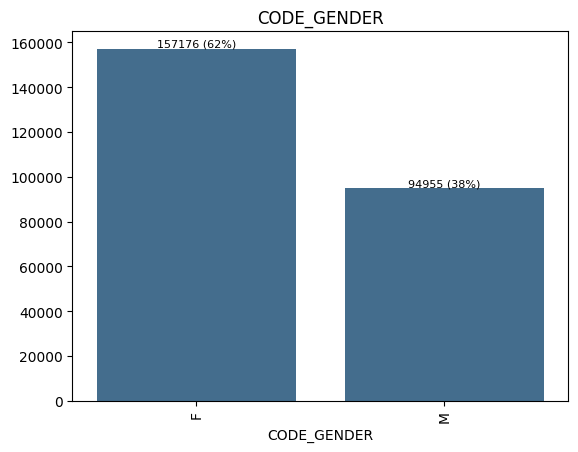


Distribution pour 'FLAG_OWN_CAR':
               Effectif  Pourcentage (en %)
FLAG_OWN_CAR                              
N               157715               62.55
Y                94416               37.45


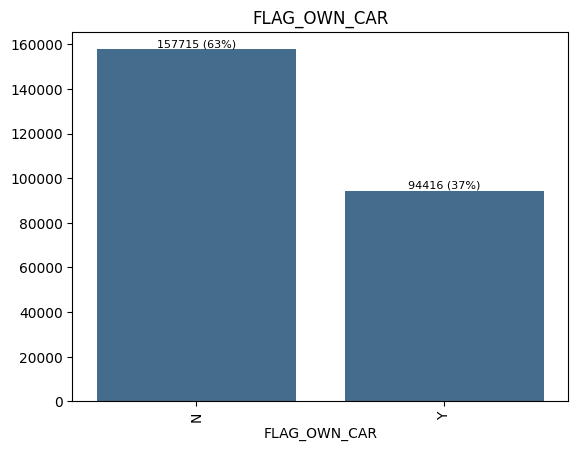


Distribution pour 'FLAG_OWN_REALTY':
                  Effectif  Pourcentage (en %)
FLAG_OWN_REALTY                              
Y                  171076               67.85
N                   81055               32.15


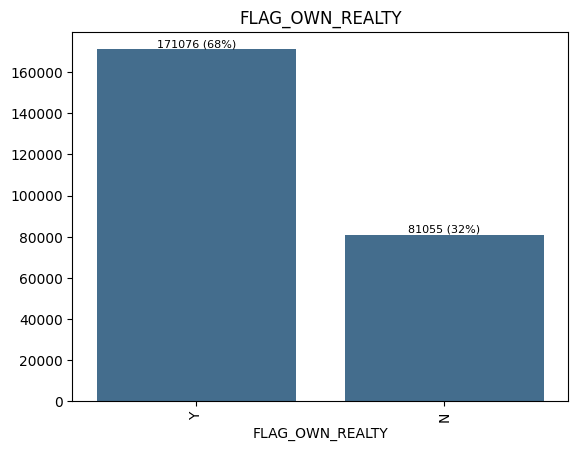


Distribution pour 'NAME_INCOME_TYPE':
                       Effectif  Pourcentage (en %)
NAME_INCOME_TYPE                                  
Working                 158771               62.97
Commercial associate     71614               28.40
State servant            21703                8.61
Student                     18                0.01
Pensioner                   10                0.00
Businessman                 10                0.00
Maternity leave              5                0.00


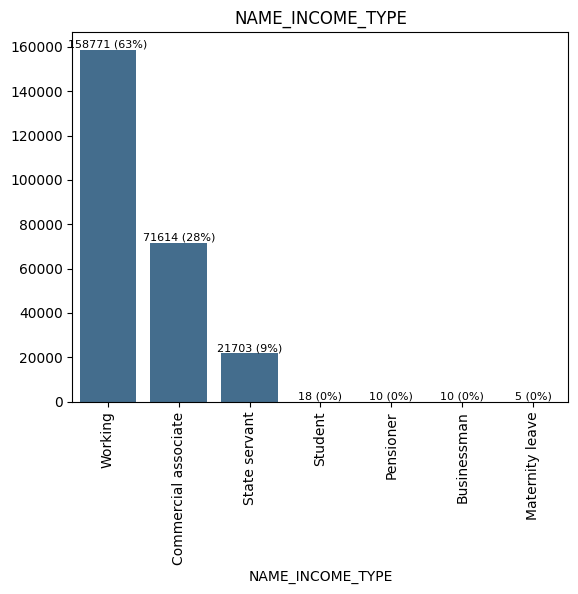


Distribution pour 'NAME_CONTRACT_TYPE':
                     Effectif  Pourcentage (en %)
NAME_CONTRACT_TYPE                              
Cash loans            226224               89.72
Revolving loans        25907               10.28


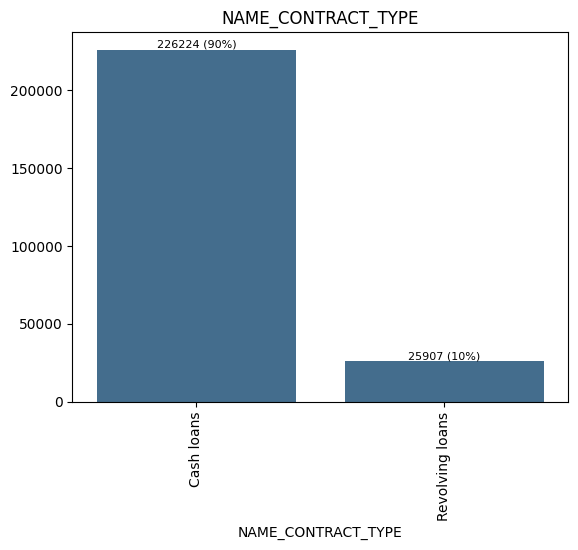


Distribution pour 'NAME_EDUCATION_TYPE':
                                Effectif  Pourcentage (en %)
NAME_EDUCATION_TYPE                                        
Secondary / secondary special    173284               68.73
Higher education                  66667               26.44
Incomplete higher                  9756                3.87
Lower secondary                    2286                0.91
Academic degree                     138                0.05


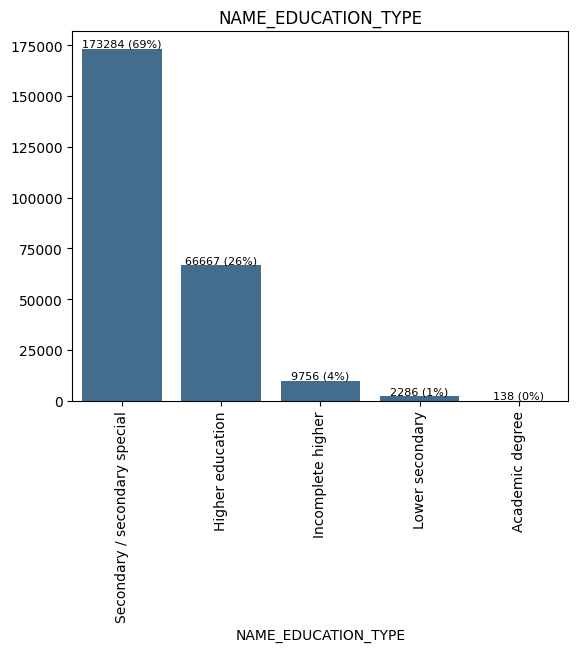


Distribution pour 'NAME_FAMILY_STATUS':
                       Effectif  Pourcentage (en %)
NAME_FAMILY_STATUS                                
Married                 163911               65.01
Single / not married     39316               15.59
Civil marriage           26196               10.39
Separated                16000                6.35
Widow                     6708                2.66


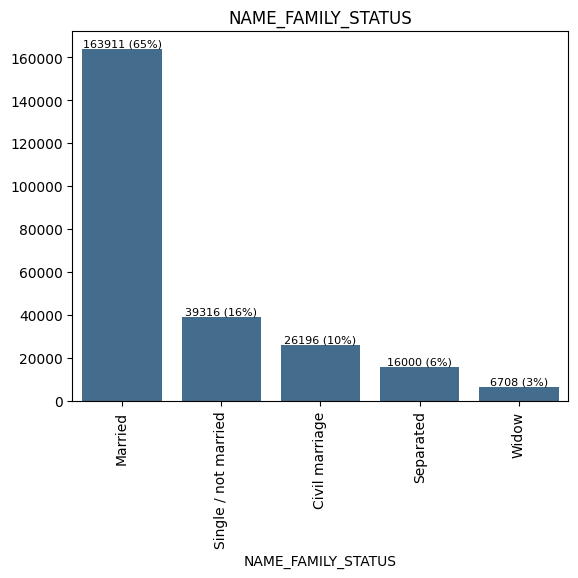


Distribution pour 'NAME_HOUSING_TYPE':
                      Effectif  Pourcentage (en %)
NAME_HOUSING_TYPE                                
House / apartment      220479               87.45
With parents            14621                5.80
Municipal apartment      9048                3.59
Rented apartment         4676                1.85
Office apartment         2301                0.91
Co-op apartment          1006                0.40


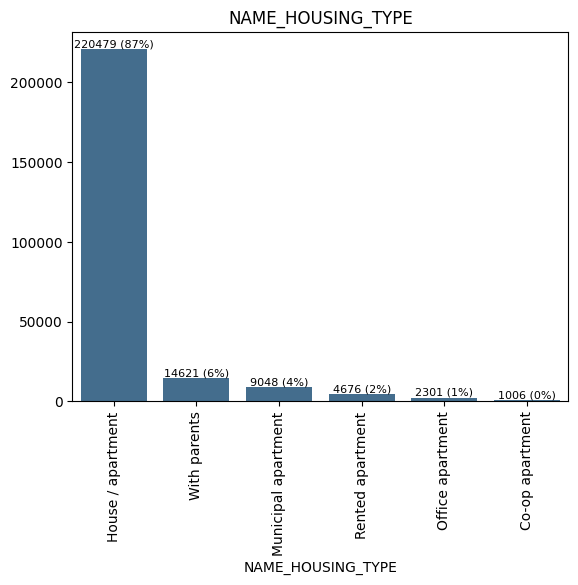

In [24]:
# Pour les variables qualitatives
def plot_categorical_distributions(df, exclude_columns=[]):
    for col in df.select_dtypes(include='object').columns:
        if col in exclude_columns: continue
        vc = df[col].value_counts()
        pct = vc / vc.sum() * 100
        print(f"\nDistribution pour '{col}':\n", pd.DataFrame({'Effectif': vc, 'Pourcentage (en %)': pct.round(2)}))
        sns.barplot(x=vc.index, y=vc.values, color="#386E99")
        for bar, label in zip(plt.gca().patches, [f"{v} ({p:.0f}%)" for v, p in zip(vc, pct)]):
            plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label, ha='center', va='bottom', fontsize=8)
        plt.title(f'{col}'), plt.xticks(rotation=90), plt.show()

plot_categorical_distributions(data, exclude_columns=["ORGANIZATION_TYPE", "OCCUPATION_TYPE"])

---
## Matrice des corrélations 

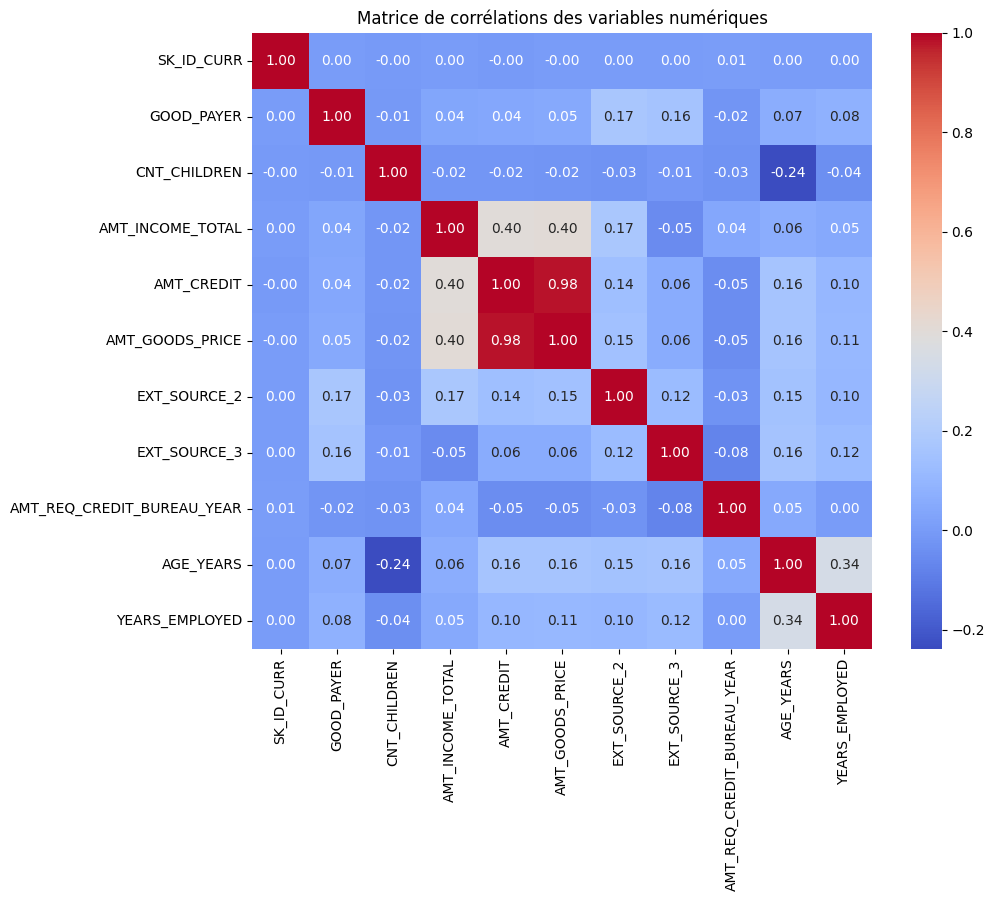

Colonnes exclues (non numériques) :
['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_CONTRACT_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sélectionner uniquement les colonnes numériques
numeric_data = data.select_dtypes(include=['number'])

# Calculer la matrice de corrélations
correlation_matrix = numeric_data.corr()

# Afficher la matrice sous forme de heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matrice de corrélations des variables numériques")
plt.show()

# Sélectionner uniquement les colonnes non numériques
non_numeric_columns = data.select_dtypes(exclude=['number']).columns

# Afficher les colonnes non numériques
print("Colonnes exclues (non numériques) :")
print(non_numeric_columns.tolist())


---
## Corrélation : variables explicatives et la variable cible (anova, pearson)

Maintenant que le traitement des données est terminé, nous allons analyser les corrélations entre les variables explicatives et la variable cible, la valeur cible est GOOD_PAYER, en utilisant les méthodes ANOVA et Pearson.

- **ANOVA**

In [26]:
# Création du DataFrame ANOVA
anova_df = pd.DataFrame([
    {'Variable': col, 'F-Stat': (f := f_oneway(*[group['GOOD_PAYER'] for _, group in data.groupby(col) if len(group) > 1]))[0], 'P-Value': f[1]}
    for col in data.select_dtypes(include=['object', 'category']).columns if 1 < data[col].nunique() < 50
])

anova_df = anova_df.sort_index()

anova_df

,Variable,F-Stat,P-Value
0,CODE_GENDER,611.970774,6.048417e-135
1,FLAG_OWN_CAR,256.724260,9.487443e-58
2,FLAG_OWN_REALTY,1.882249,1.700800e-01
3,NAME_INCOME_TYPE,90.113413,1.916857e-113
4,NAME_CONTRACT_TYPE,330.967596,6.598701e-74
5,NAME_EDUCATION_TYPE,304.656706,6.301838e-262
6,NAME_FAMILY_STATUS,102.065917,5.366674e-87
7,NAME_HOUSING_TYPE,61.464686,2.923227e-64
8,OCCUPATION_TYPE,74.305359,2.077591e-272


**Variables les plus importantes :**
  
- `CODE_GENDER` **(F-Stat : 828.80)** : Cette variable montre une différence extrêmement significative avec la cible. Elle pourrait être un facteur clé à examiner en priorité.

- `NAME_EDUCATION_TYPE` **(F-Stat : 185.85)** et `NAME_FAMILY_STATUS` **(F-Stat : 175.23)** : Ces deux variables jouent un rôle important dans la différenciation des groupes cibles.

- `NAME_INCOME_TYPE` **(F-Stat : 118.28)** : Reflète aussi des distinctions significatives entre les catégories.


**Variables d’impact modéré :**

`FLAG_OWN_CAR` et `NAME_CONTRACT_TYPE` montrent également des écarts significatifs, mais leur importance relative est moindre en comparaison des variables ci-dessus.


**Variables à impact limité :**

`FLAG_OWN_REALTY` (F-Stat : 21.58), bien que statistiquement significative (P-value < 0.05), présente une F-Stat plus faible, suggérant un impact moindre sur la différenciation.

- **Pearson**

In [27]:
# Variables numériques à analyser
numerical_cols = [col for col in data.select_dtypes(include=['float64', 'int64']).columns 
                  if col != 'GOOD_PAYER' and data[col].nunique() > 1]

# Corrélations avec la cible
correlations_with_target = data[numerical_cols].corrwith(data['GOOD_PAYER']).sort_values(ascending=False)

correlations_with_target

EXT_SOURCE_2                  0.170337
EXT_SOURCE_3                  0.158269
YEARS_EMPLOYED                0.079341
AGE_YEARS                     0.065757
AMT_GOODS_PRICE               0.049886
AMT_CREDIT                    0.040224
AMT_INCOME_TOTAL              0.036194
SK_ID_CURR                    0.001413
CNT_CHILDREN                 -0.007713
AMT_REQ_CREDIT_BUREAU_YEAR   -0.022462
dtype: float64

**Variables avec une corrélation positive significative :**

- `EXT_SOURCE_2` (0.0956) et `EXT_SOURCE_3` (0.0937) : Ces indices externes de risque montrent la plus forte corrélation positive avec la probabilité d'être un bon payeur. Ils semblent être des variables déterminantes.

- `AMT_GOODS_PRICE` (0.0617), `AGE_YEARS` (0.0610), et `AMT_CREDIT` (0.0540) : Ces variables financières et démographiques ont une faible corrélation positive avec la cible, suggérant qu'elles contribuent modestement à la distinction entre bons et mauvais payeurs.

- `YEARS_EMPLOYD` (0.0539) : Plus une personne est employée depuis longtemps, plus elle est susceptible d'être un bon payeur, bien que la corrélation reste faible.

- `CNT_CHILDREN` (0.0439) et `AMT_INCOME_TOTAL` (0.0409) : Ces variables montrent une légère corrélation positive avec la capacité de paiement.

**Variables avec une corrélation négative ou neutre :**

- `Is_Outlier_IF` (-0.0074) : Les anomalies détectées par l'algorithme Isolation Forest semblent légèrement associées à une probabilité plus faible d'être un bon payeur.

- Les autres variables comme `AMT_REQ_CREDIT_BUREAU_YEAR` (0.0188) et `SK_ID_CURR` (0.0082) montrent une corrélation presque nulle avec la cible, indiquant un faible rôle explicatif.

---
## Taux de risque / %BP et %MP selon les modalités (Analyse Marginale)

Dans cette section, nous allons analyser les taux de risque en examinant la répartition des bon payeurs (BP) et mauvais payeurs (MP) en fonction des différentes modalités des variables explicatives. Cette analyse marginale nous permettra de mettre en évidence les caractéristiques les plus influentes sur le risque et d’identifier les groupes de clients présentant des profils spécifiques en termes de performance de paiement.

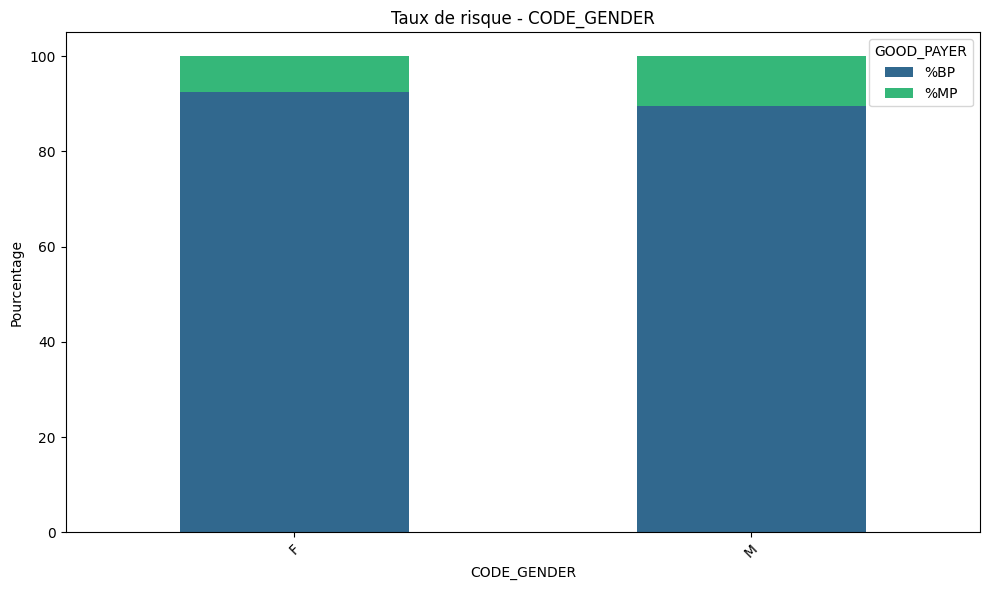

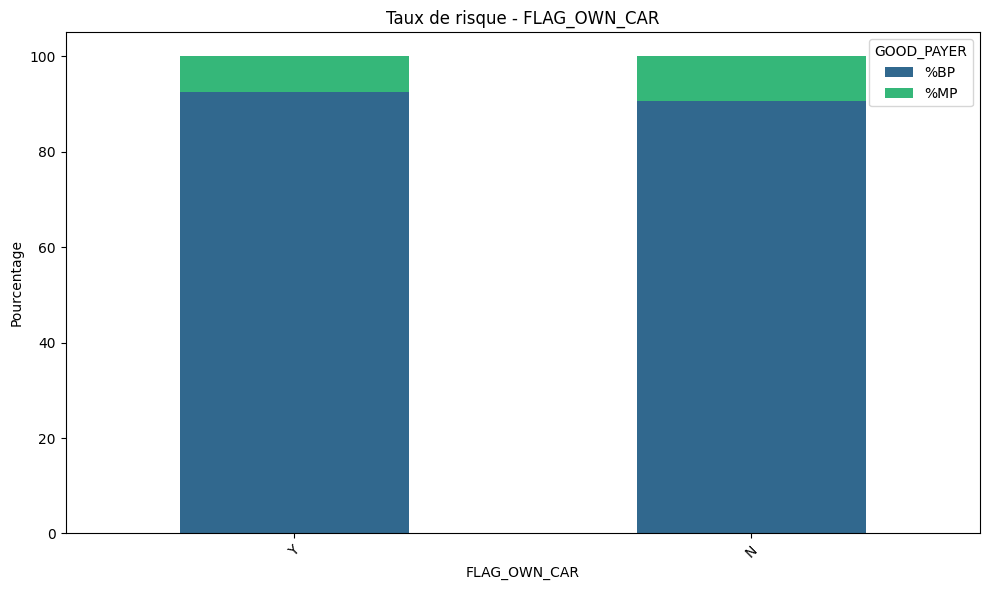

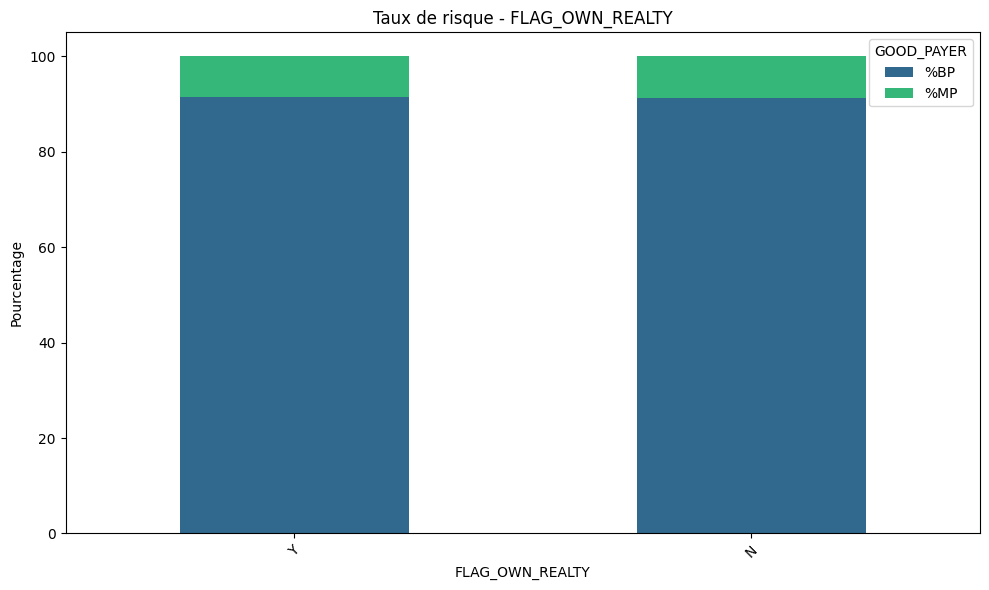

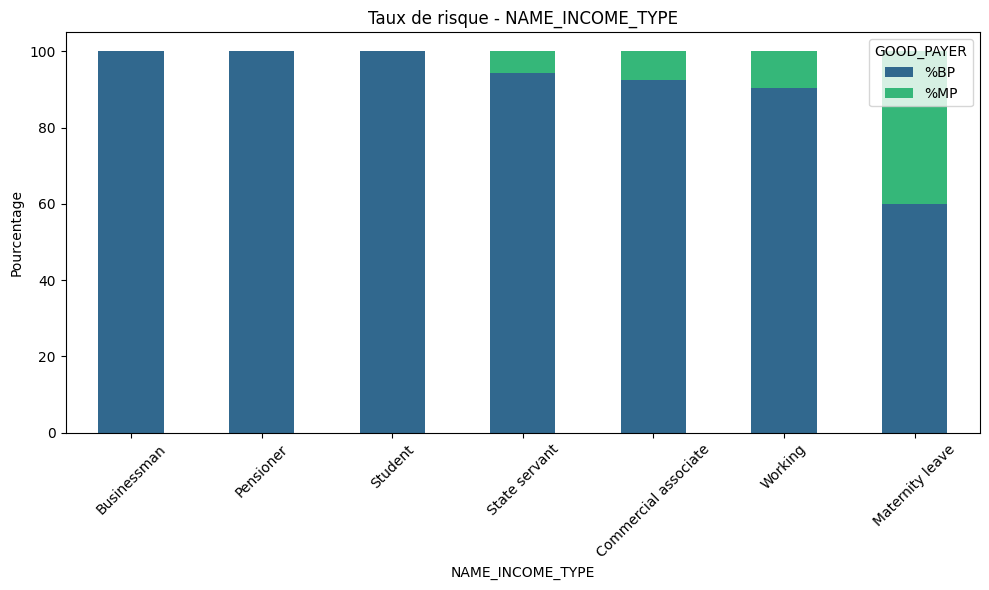

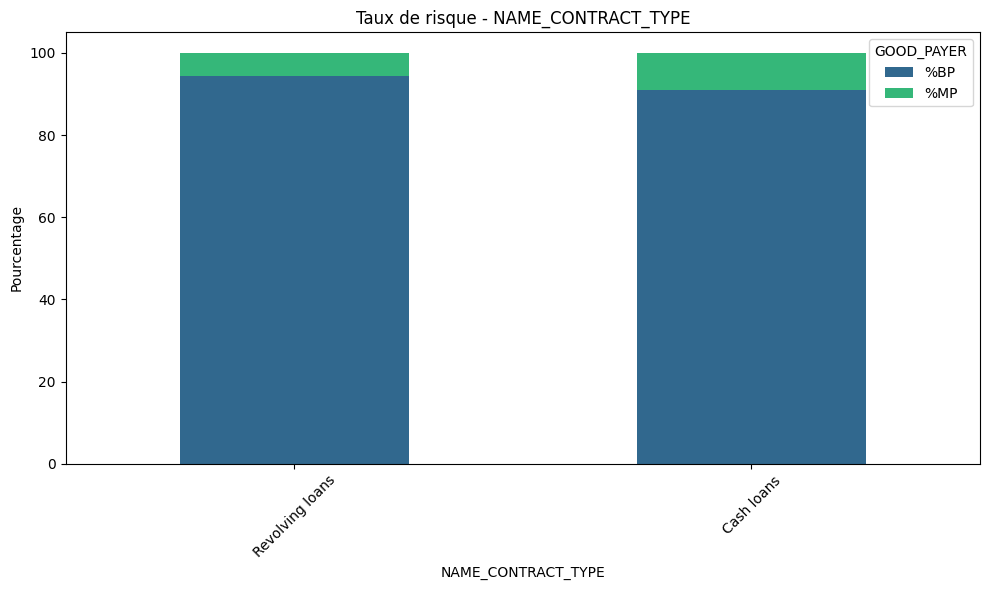

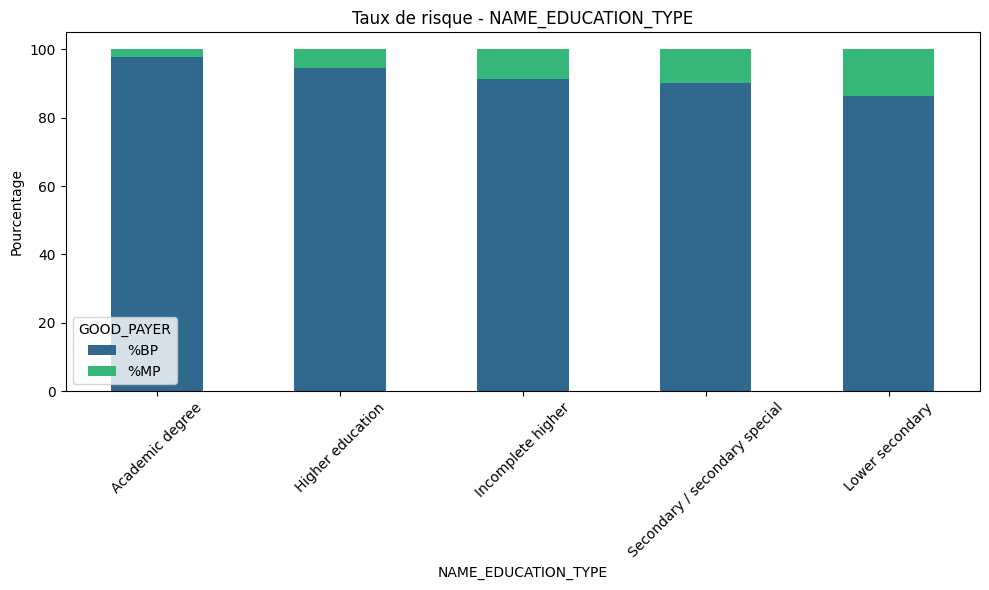

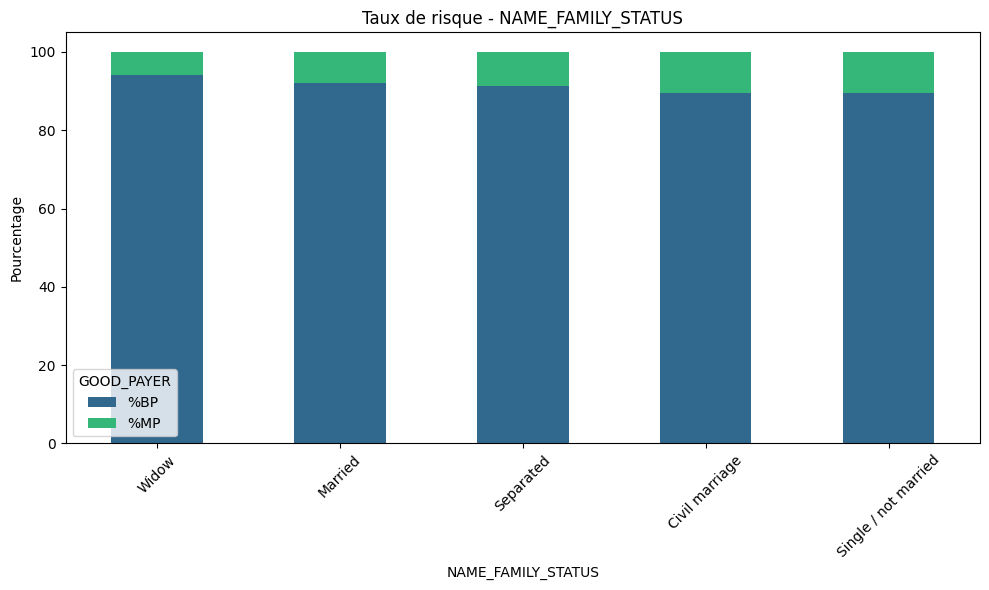

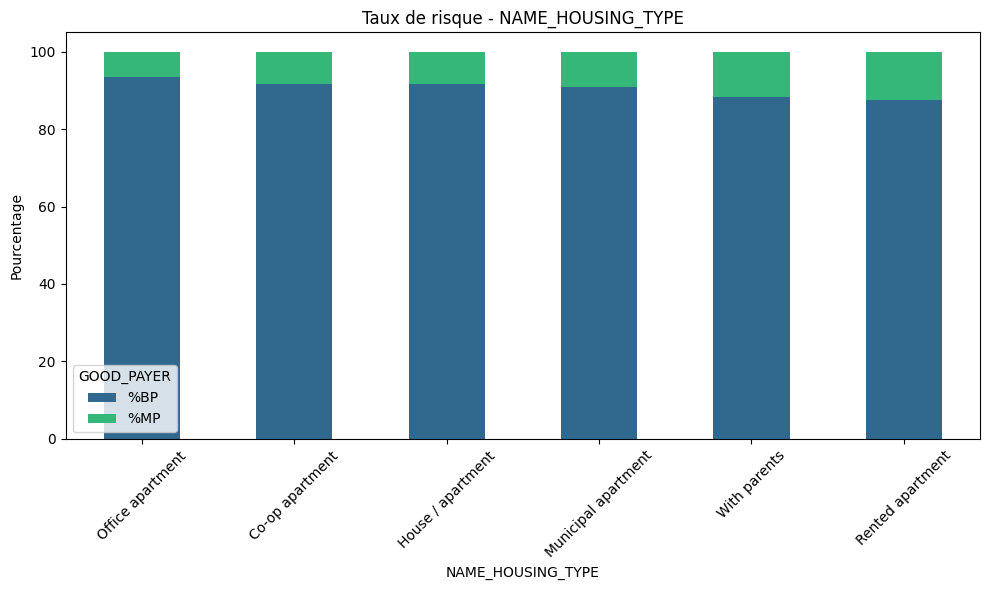

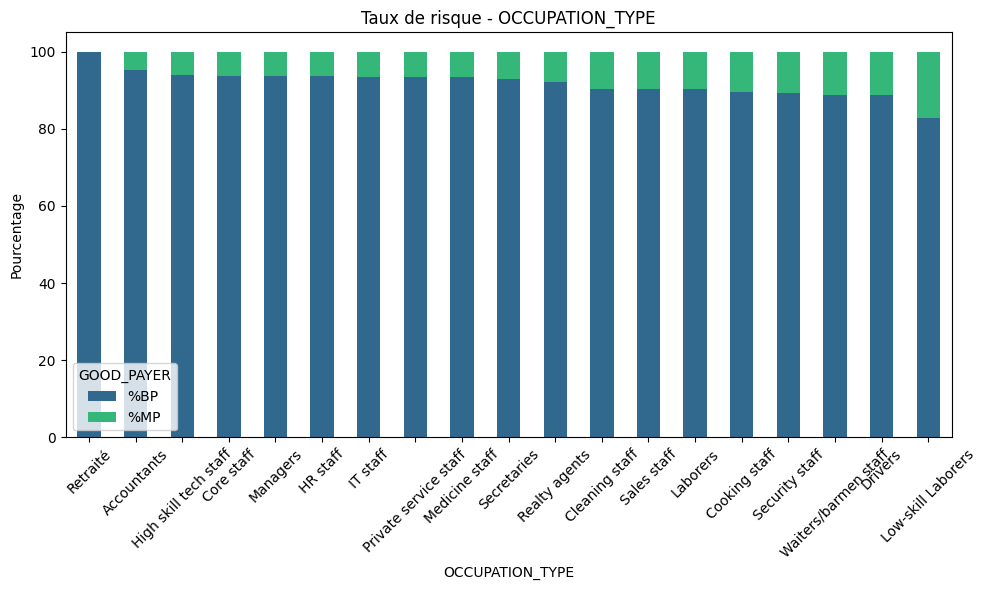

In [28]:
def analyze_risk_by_modalities(data, target_col, exclude_columns=[], palette=None):
    palette = palette or ['#d1e7dd', '#800000']
    for col in [c for c in data.select_dtypes(include='object') if c not in exclude_columns]:
        (data.groupby(col)[target_col].value_counts(normalize=True)
         .unstack(fill_value=0).mul(100).rename(columns={0: '%MP', 1: '%BP'})
         [['%BP', '%MP']].sort_values(by='%MP')
         .plot(kind='bar', stacked=True, figsize=(10, 6), color=palette))
        plt.title(f"Taux de risque - {col}"), plt.xlabel(col), plt.ylabel("Pourcentage")
        plt.xticks(rotation=45), plt.tight_layout(), plt.show()

analyze_risk_by_modalities(data, 'GOOD_PAYER', ["ORGANIZATION_TYPE"], sns.color_palette("viridis", 2))

---
# Visualisation des données : boxplot, piechart, nuage de point

Pour compléter les graphiques précédents, nous vous proposons de nouvelles visualisations permettant de mettre en avant des relations spécifiques entre les variables explicatives et la variable cible. Afin d'avoir une visulisation lisible et sans biais nous avons sélectionné un échantillon aléatoire comprenant autant de bon que de mauvais payeur.

In [29]:
# Nombre d'échantillons par catégorie
n_samples = 500

# Échantillonnage aléatoire
good_payers = data[data['GOOD_PAYER'] == 1].sample(n=n_samples, random_state=42)
bad_payers = data[data['GOOD_PAYER'] == 0].sample(n=n_samples, random_state=42)

# Combiner les deux échantillons
balanced_sample = pd.concat([good_payers, bad_payers])

## Boxplot

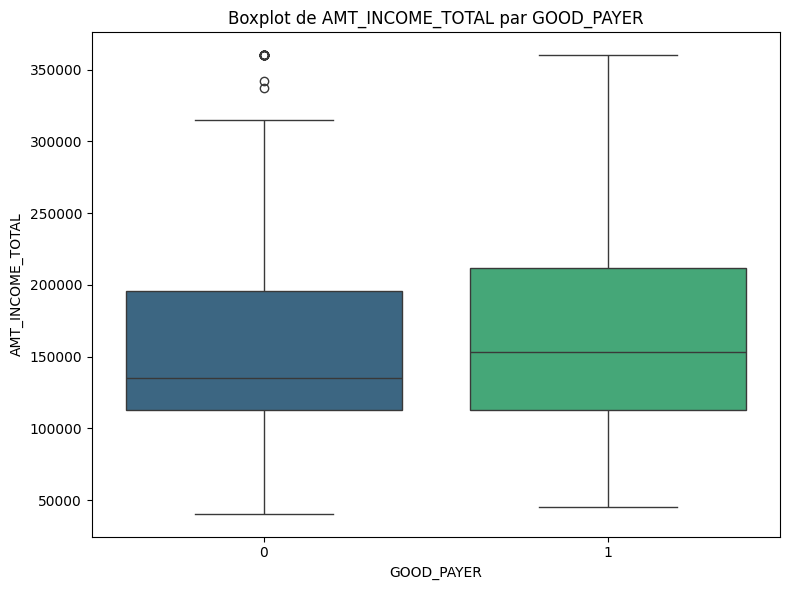

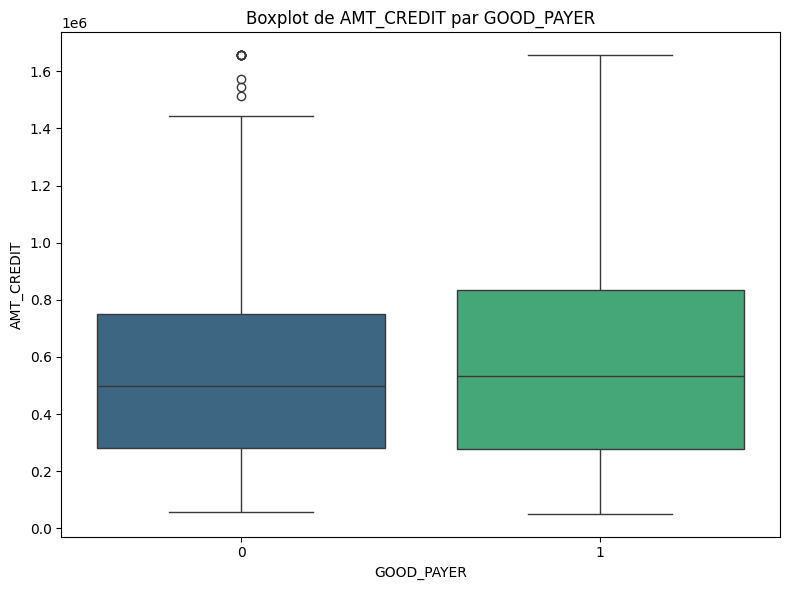

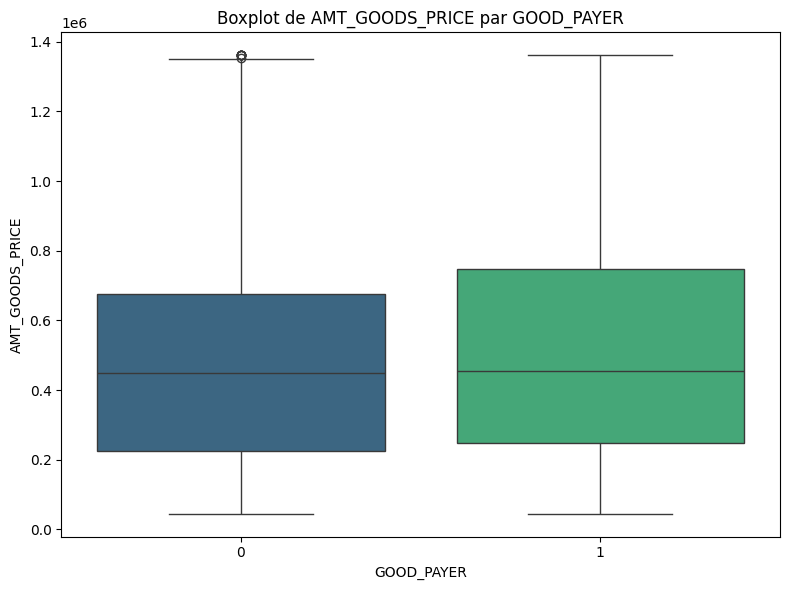

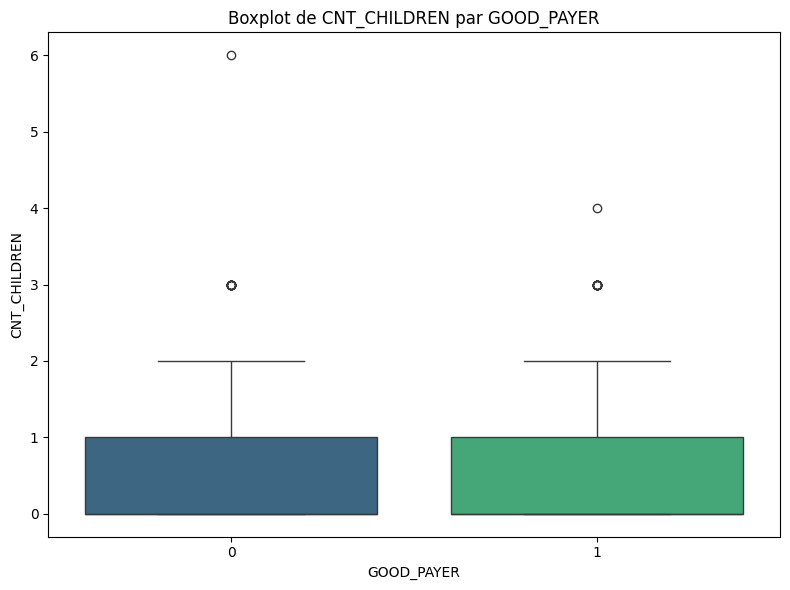

In [30]:
categorical_vars = ['GOOD_PAYER']
continuous_vars = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'CNT_CHILDREN']

for cat in categorical_vars:
    for cont in continuous_vars:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=balanced_sample, x=cat, y=cont, palette='viridis')
        plt.title(f"Boxplot de {cont} par {cat}")
        plt.xlabel(cat)
        plt.ylabel(cont)
        plt.tight_layout()
        plt.show()

## Diagramme en barres

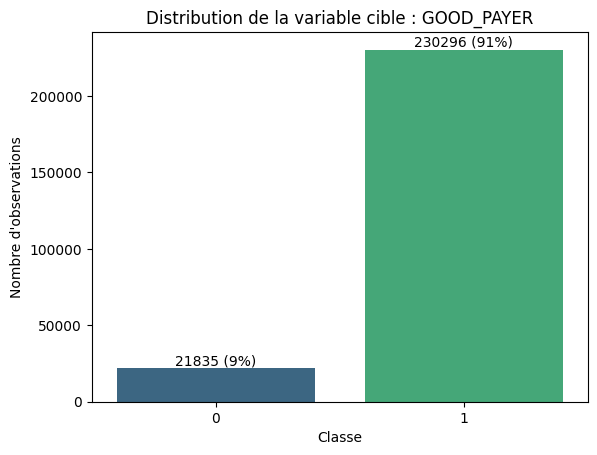

In [31]:
value_counts = data['GOOD_PAYER'].value_counts()
colors = ['#800000' if x == value_counts.max() else 'grey' for x in value_counts.values]
palette = dict(zip(value_counts.index.map(str), colors))  # Convertir les index en chaînes

ax = sns.countplot(x='GOOD_PAYER', data=data, order=value_counts.index[::-1], palette='viridis')

for bar, abs_val, rel_val in zip(ax.patches, value_counts[::-1], value_counts[::-1] / value_counts.sum() * 100):
    ax.annotate(f'{abs_val} ({rel_val:.0f}%)', 
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title("Distribution de la variable cible : GOOD_PAYER")
plt.ylabel("Nombre d'observations")
plt.xlabel("Classe")
plt.show()

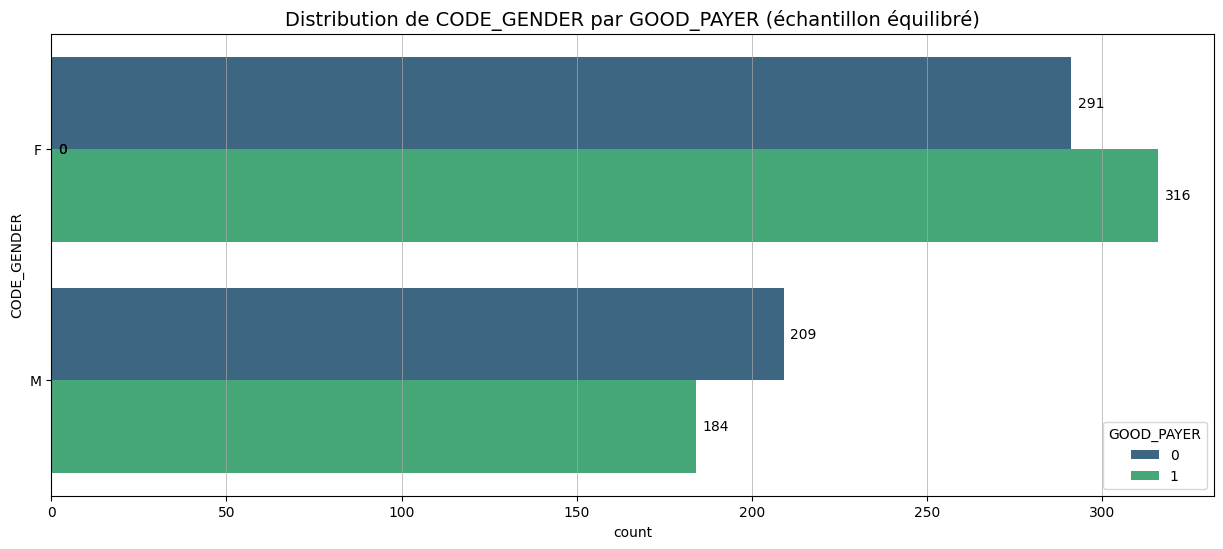

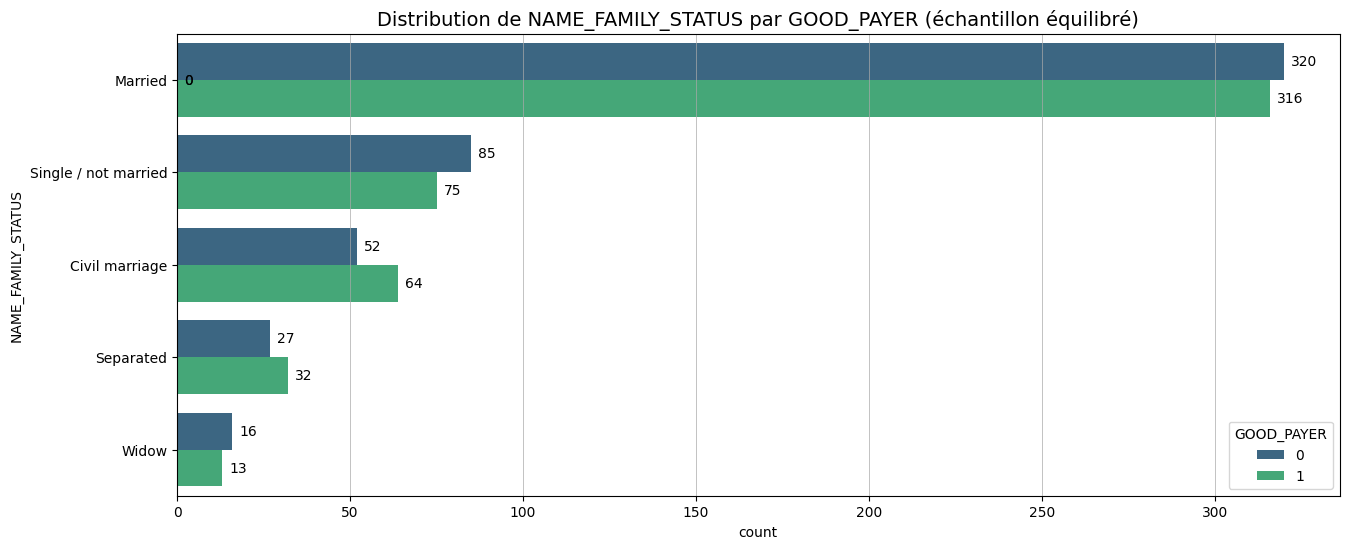

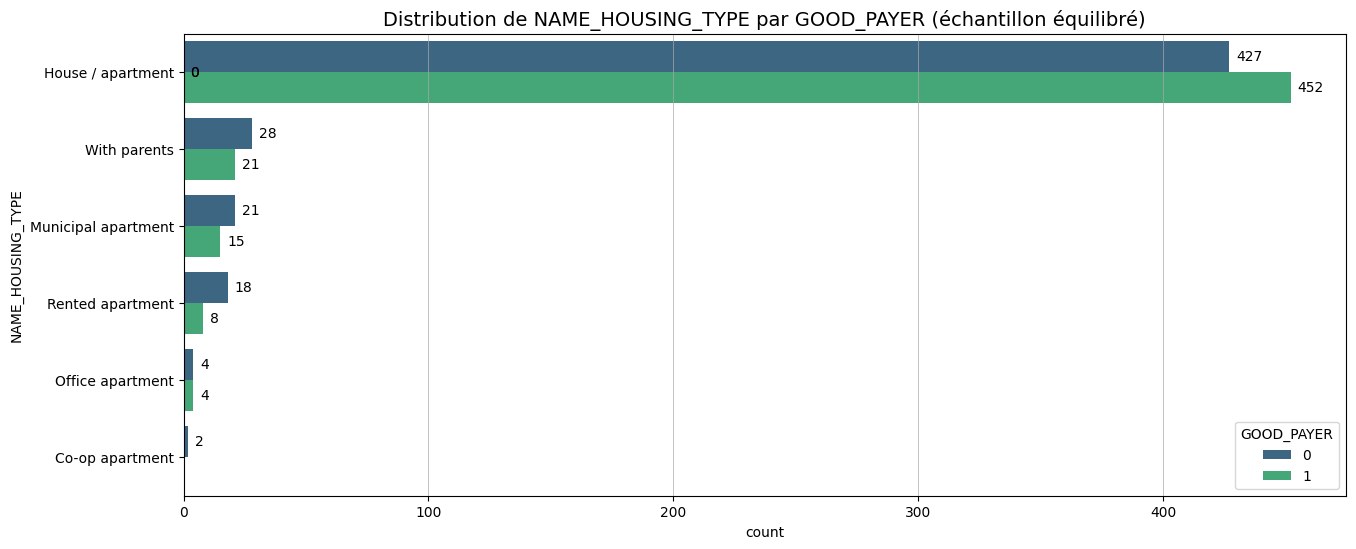

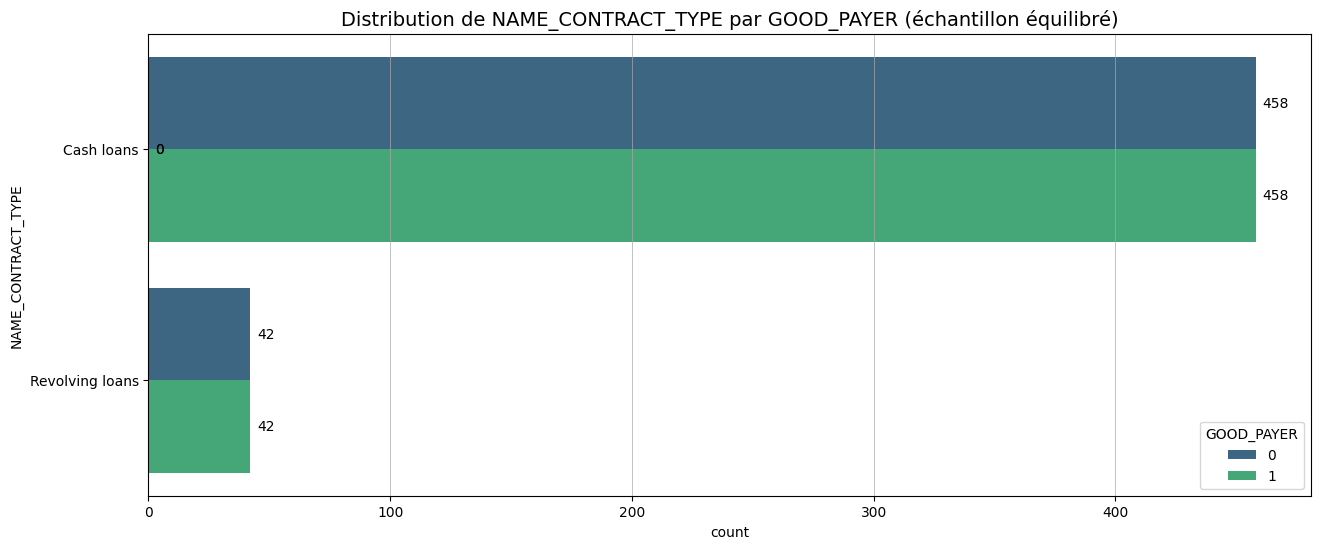

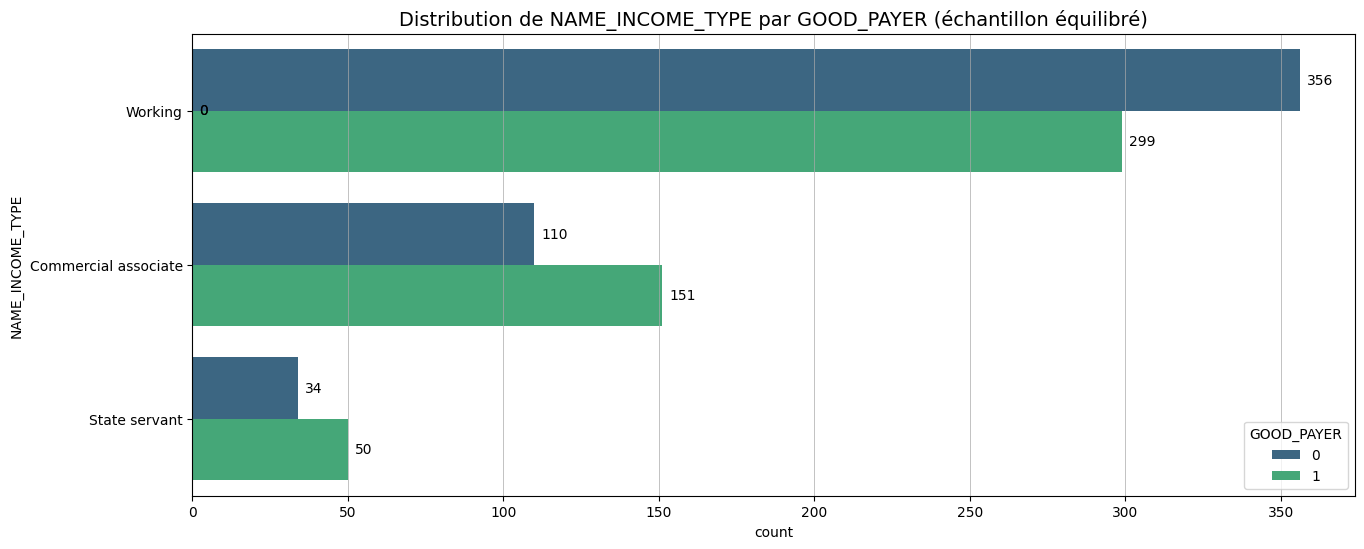

In [32]:
for col in ['CODE_GENDER', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE']:
    plt.figure(figsize=(15, 6))
    ax = sns.countplot(y=col, data=balanced_sample, hue='GOOD_PAYER', order=balanced_sample[col].value_counts().index, palette='viridis')
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2), xytext=(5, 0), textcoords='offset points', ha="left", va="center")
    ax.set_title(f'Distribution de {col} par GOOD_PAYER (échantillon équilibré)', fontsize=14)
    ax.grid(color='darkgray', axis='x', linestyle='-', linewidth=0.5)
    plt.show()


## Répartition des variables qualitatives

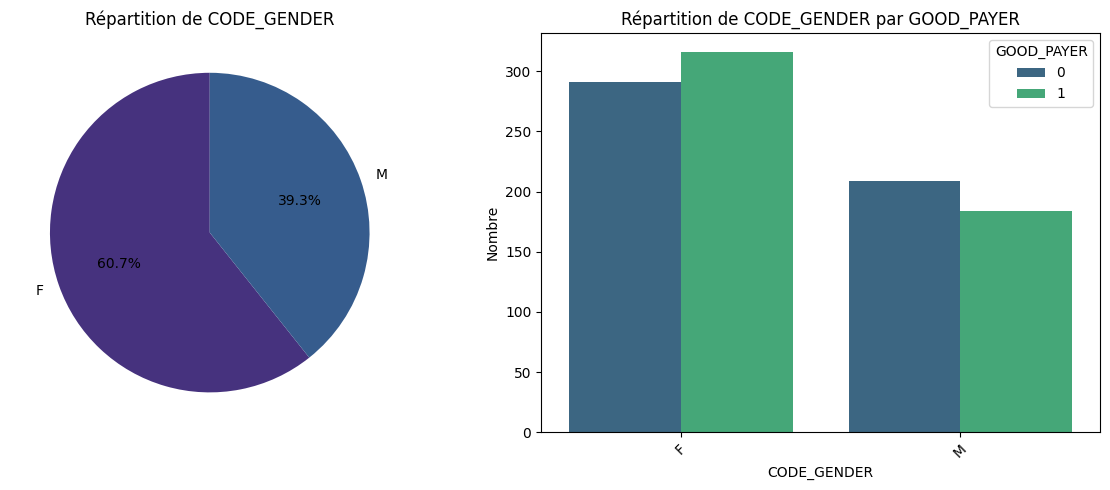

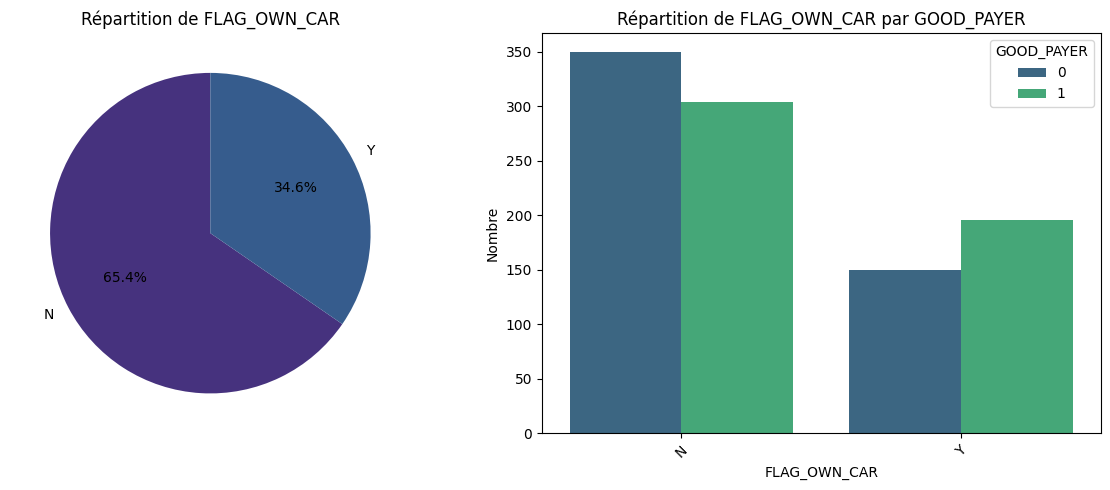

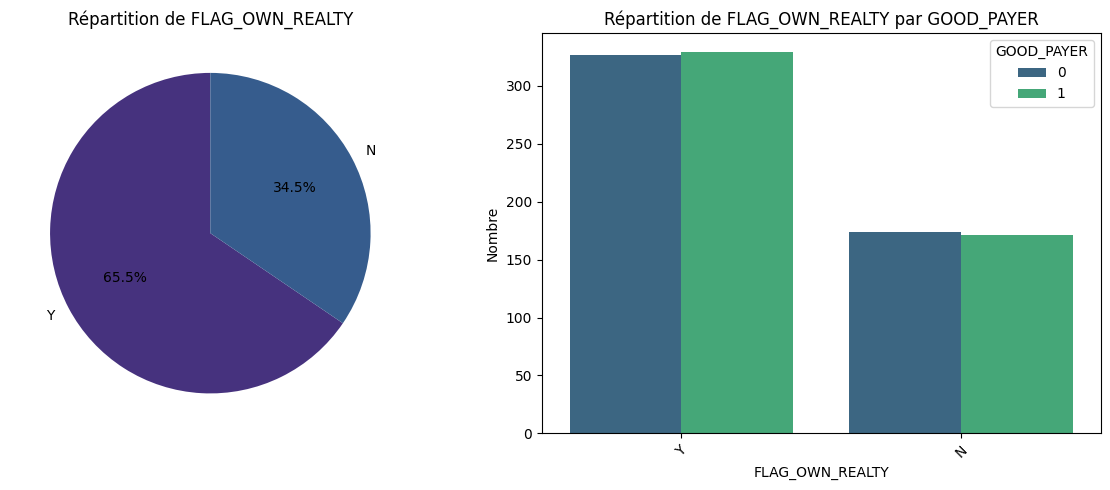

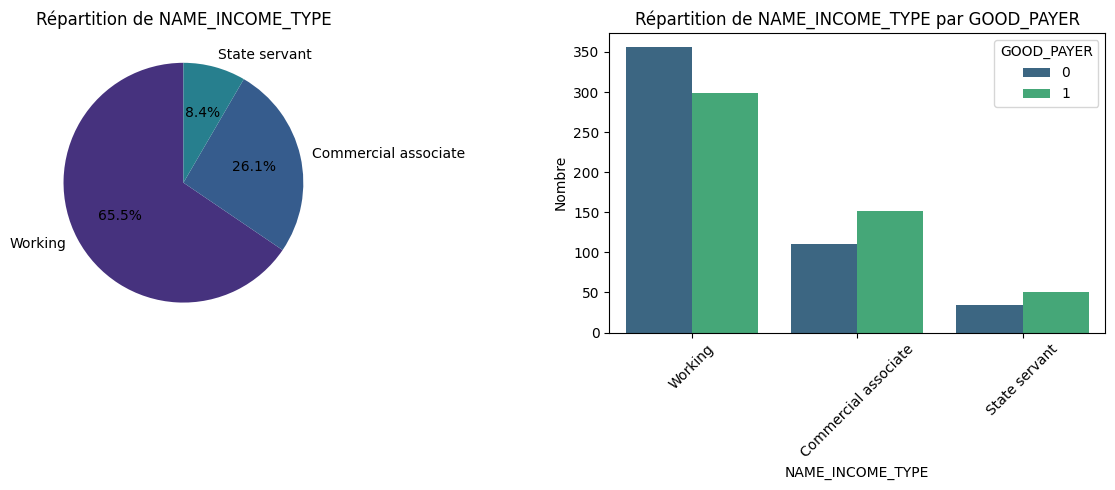

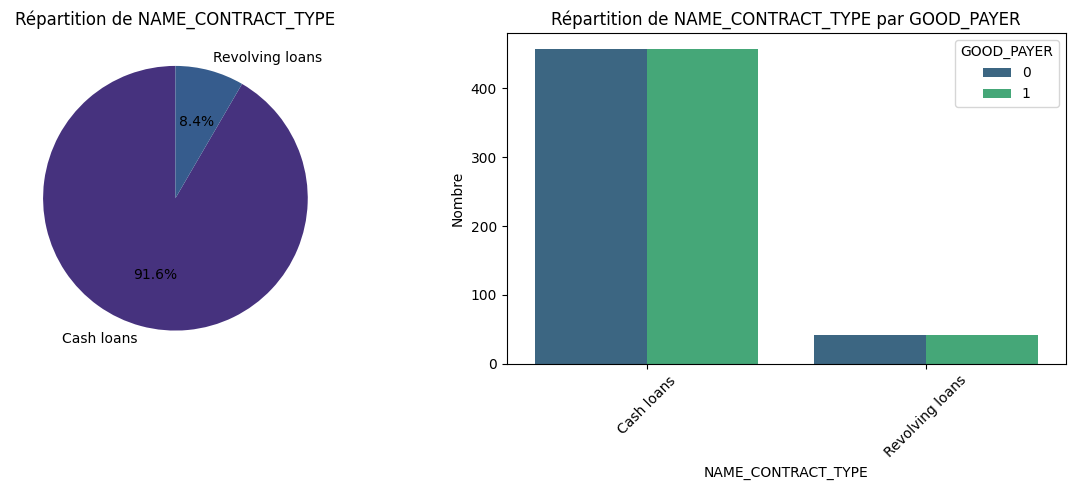

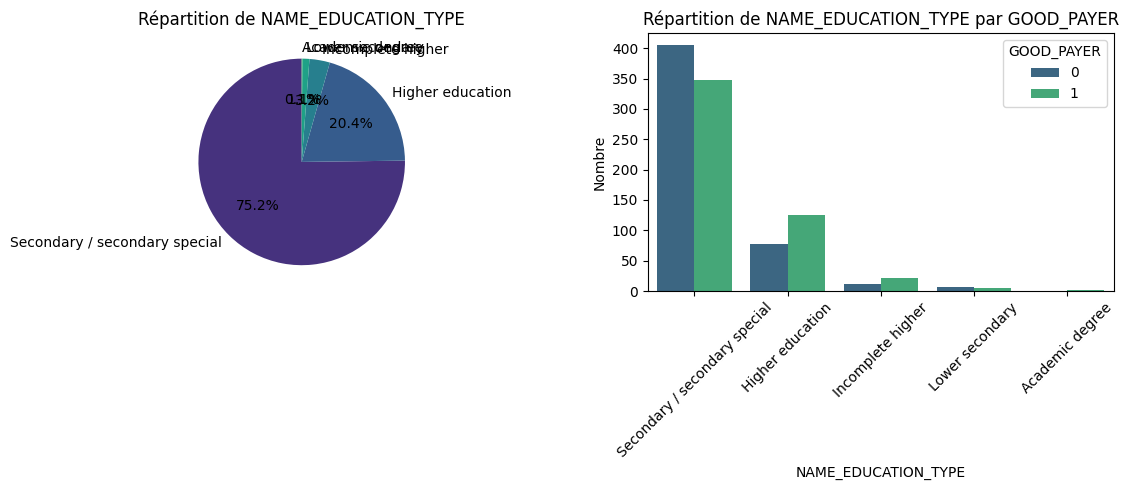

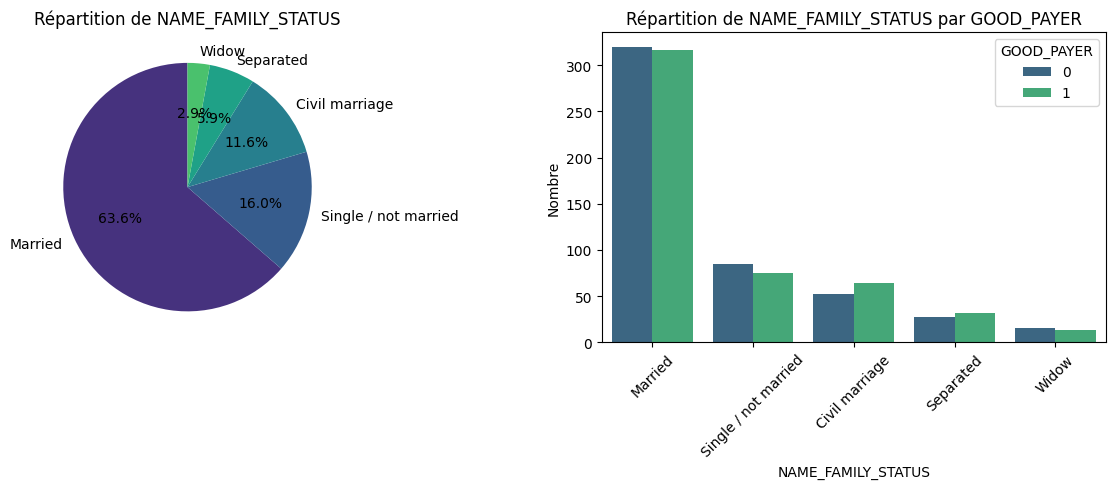

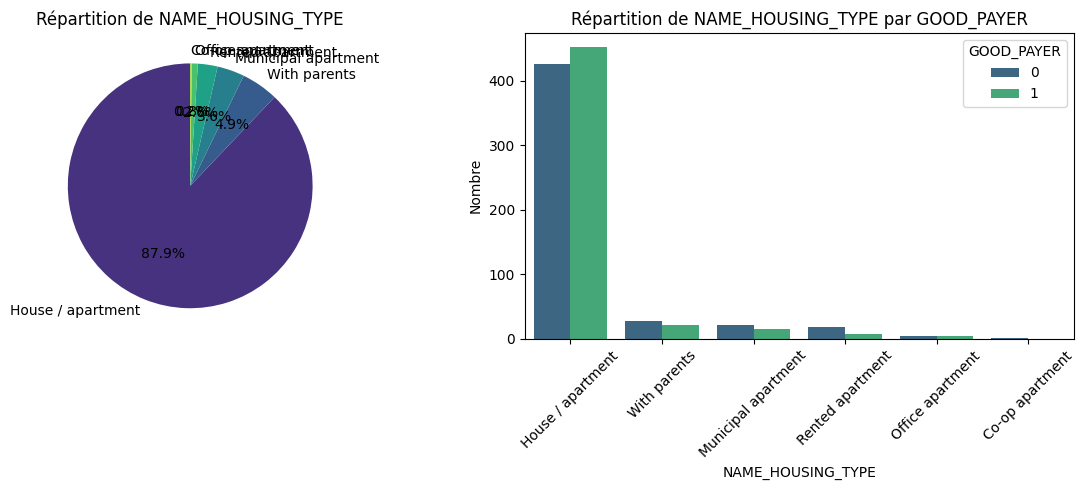

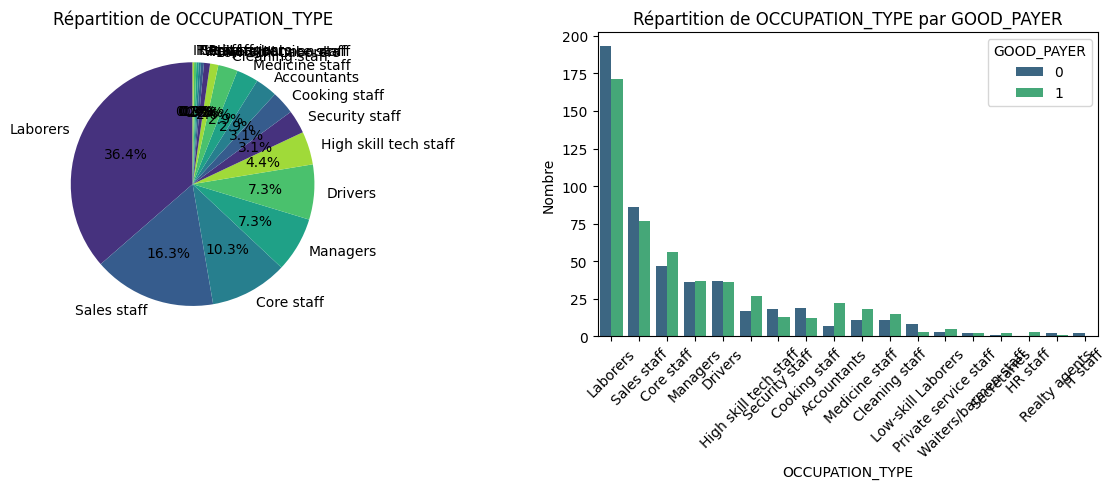

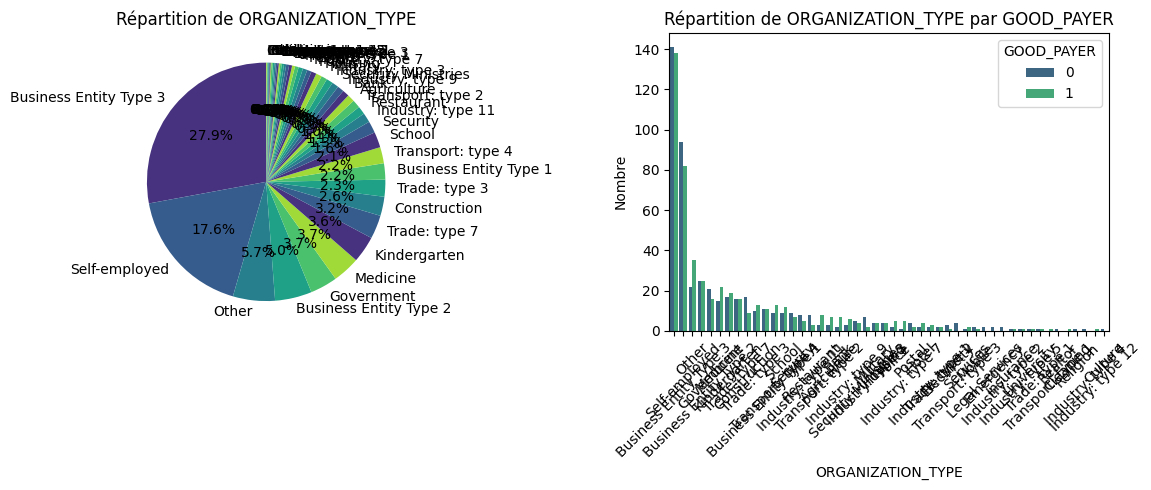

In [33]:
# Identifier les colonnes qualitatives
qualitative_cols = balanced_sample.select_dtypes(include='object')

for col in qualitative_cols:
    value_counts = balanced_sample[col].value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Graphe en secteurs
    axes[0].pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis'))
    axes[0].set_title(f'Répartition de {col}')
    
    # Graphe en barres
    sns.countplot(data=balanced_sample, x=col, hue='GOOD_PAYER', palette='viridis', order=value_counts.index, ax=axes[1])
    axes[1].set_title(f'Répartition de {col} par {cat}')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Nombre')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## Nuages de points

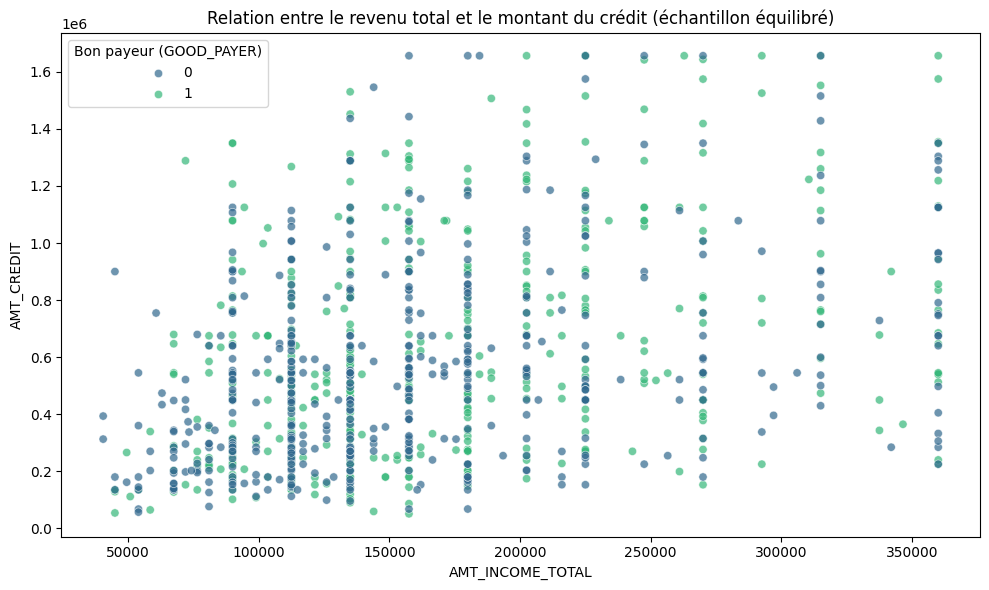

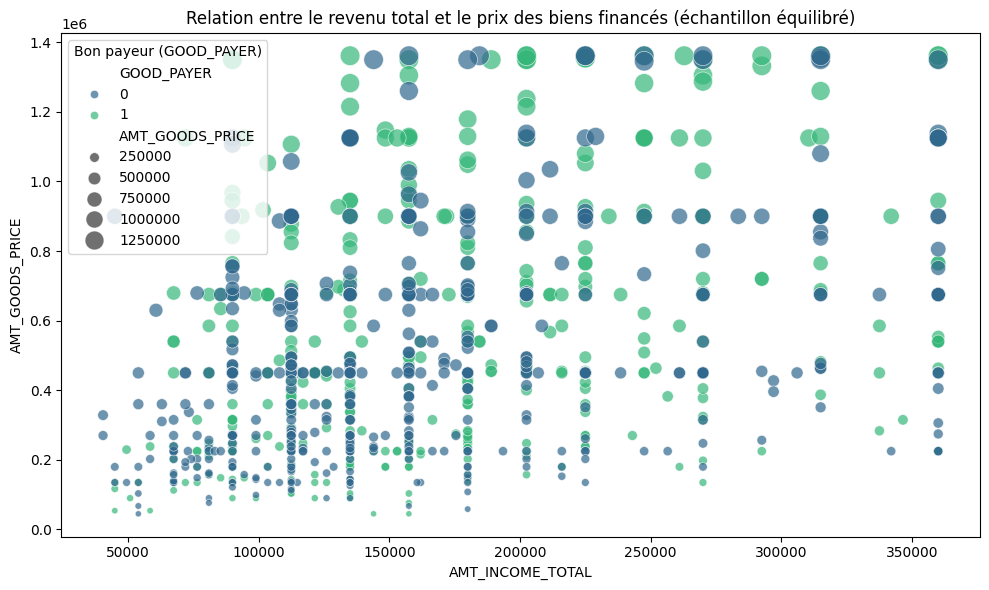

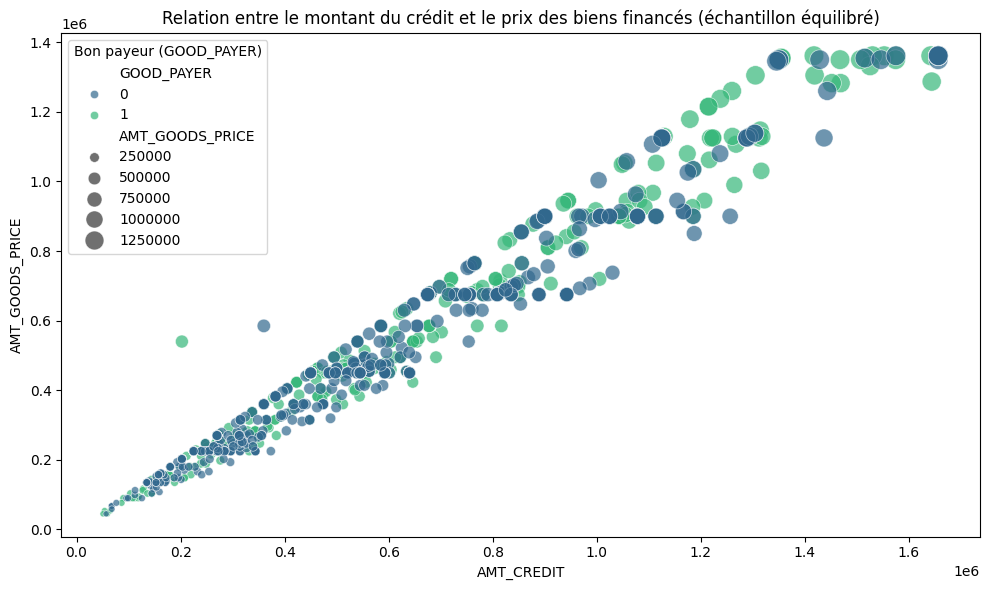

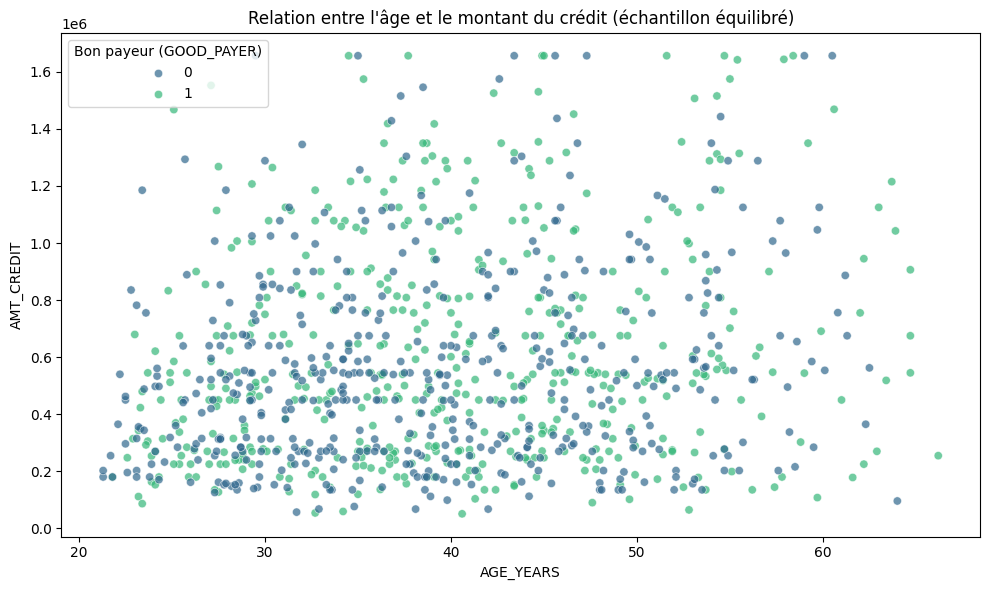

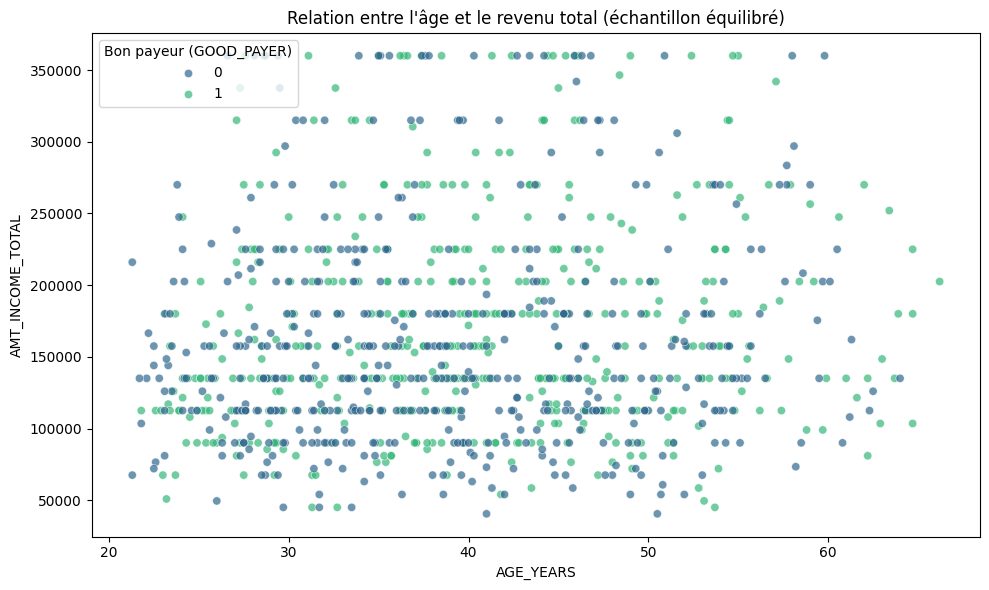

In [34]:
scatter_vars = [
    ('AMT_INCOME_TOTAL', 'AMT_CREDIT', "Relation entre le revenu total et le montant du crédit"),
    ('AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE', "Relation entre le revenu total et le prix des biens financés"),
    ('AMT_CREDIT', 'AMT_GOODS_PRICE', "Relation entre le montant du crédit et le prix des biens financés"),
    ('AGE_YEARS', 'AMT_CREDIT', "Relation entre l'âge et le montant du crédit"),
    ('AGE_YEARS', 'AMT_INCOME_TOTAL', "Relation entre l'âge et le revenu total"),
    ('DAYS_EMPLOYED', 'AMT_CREDIT', "Relation entre l'ancienneté d'emploi et le montant du crédit")
]

valid_scatter_vars = [
    (x, y, title) for x, y, title in scatter_vars if x in balanced_sample.columns and y in balanced_sample.columns
]


for x_var, y_var, title in valid_scatter_vars:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=balanced_sample,  # Spécifiez explicitement les données
        x=x_var,
        y=y_var,
        hue='GOOD_PAYER',
        size='AMT_GOODS_PRICE' if 'AMT_GOODS_PRICE' in [x_var, y_var] else None,
        sizes=(20, 200),
        palette='viridis',
        alpha=0.7
    )
    plt.title(title + " (échantillon équilibré)")
    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.legend(title="Bon payeur (GOOD_PAYER)", loc="upper left")
    plt.tight_layout()
    plt.show()

---
# Calcul de métrique d’importances des variables

- **WOE :**

Le WOE mesure la capacité d'une variable à discriminer entre deux classes (par exemple, bon payeur et mauvais payeur). Il est calculé pour chaque modalité ou intervalle d'une variable. Un WOE positif indique que la modalité est associée à une proportion plus élevée de bons payeurs.

- **IV :**

L'IV résume la contribution totale de la variable en tant que prédicteur. Une IV élevée indique une variable pertinente.

In [35]:
def calculate_woe_iv(data, feature, target):
    """
    Fonction pour calculer WOE et IV
    """
    grouped = data.groupby(feature)[target].agg(['count', 'sum'])
    grouped['bad'] = grouped['count'] - grouped['sum']
    grouped['dist_good'] = grouped['sum'] / grouped['sum'].sum()
    grouped['dist_bad'] = grouped['bad'] / grouped['bad'].sum()
    grouped['woe'] = np.log(grouped['dist_good'] / grouped['dist_bad']).replace([np.inf, -np.inf], 0)
    grouped['iv'] = (grouped['dist_good'] - grouped['dist_bad']) * grouped['woe']
    return grouped[['woe', 'iv']], grouped['iv'].sum()

# Sélection des colonnes catégoriques
categorical_columns = data.select_dtypes(include=['object', 'category']).columns

# Calculer WOE et IV pour chaque variable catégorique
iv_results = {}
for column in categorical_columns:
    woe_iv_table, iv = calculate_woe_iv(data, column, 'GOOD_PAYER')
    iv_results[column] = iv
    print(f"Variable: {column}, IV: {iv:.4f}")
    print(woe_iv_table)

# Trier les résultats par IV décroissant
sorted_iv_results = sorted(iv_results.items(), key=lambda x: x[1], reverse=True)
print("\nVariables triées par IV :")
for column, iv in sorted_iv_results:
    print(f"{column}: IV = {iv:.4f}")

Variable: CODE_GENDER, IV: 0.0298
                  woe        iv
CODE_GENDER                    
F            0.144338  0.012236
M           -0.206666  0.017520
Variable: FLAG_OWN_CAR, IV: 0.0132
                   woe       iv
FLAG_OWN_CAR                   
N            -0.084719  0.00465
Y             0.156332  0.00858
Variable: FLAG_OWN_REALTY, IV: 0.0001
                      woe        iv
FLAG_OWN_REALTY                    
N               -0.014032  0.000064
Y                0.006705  0.000030
Variable: NAME_INCOME_TYPE, IV: 0.0290
                           woe        iv
NAME_INCOME_TYPE                        
Businessman           0.000000  0.000000
Commercial associate  0.158681  0.006698
Maternity leave      -1.950386  0.000153
Pensioner             0.000000  0.000000
State servant         0.439984  0.013910
Student               0.000000  0.000000
Working              -0.112062  0.008283
Variable: NAME_CONTRACT_TYPE, IV: 0.0196
                         woe        iv
NAME_

**Interpréter WOE :**

- Un WOE positif indique que la modalité est associée à une proportion plus élevée de bons payeurs.

- Un WOE négatif indique que la modalité est associée à une proportion plus élevée de mauvais payeurs.

**Échelle d’interprétation de l’IV :**

- 0 - 0.02 : Faiblement prédictive.
- 0.02 - 0.1 : Moyennement prédictive.
- 0.1 - 0.3 : Modérément prédictive.
- 0.3+ : Fortement prédictive.



- **GINI :**

L'indice de Gini est une mesure de discrimination pour évaluer la capacité d'une variable explicative (caractéristique) à différencier les classes de la variable cible. Il varie entre -1 et 1, où :

- **1** indique une discrimination parfaite (les bons et mauvais payeurs sont parfaitement séparés).
- **0** indique une absence totale de discrimination (la variable ne différencie pas les classes).
- **Valeurs négatives** indiquent une corrélation inversée (la variable différencie mal les classes, à l'opposé de ce qui est attendu).

In [36]:
for col in [c for c in data.select_dtypes(include=[np.number]).columns if c != 'GOOD_PAYER']:
    print(f"Indice de Gini pour {col} : {2 * roc_auc_score(balanced_sample['GOOD_PAYER'], balanced_sample[col]) - 1:.4f}")

Indice de Gini pour SK_ID_CURR : 0.0312
Indice de Gini pour CNT_CHILDREN : 0.0059
Indice de Gini pour AMT_INCOME_TOTAL : 0.0942
Indice de Gini pour AMT_CREDIT : 0.0795
Indice de Gini pour AMT_GOODS_PRICE : 0.1196
Indice de Gini pour EXT_SOURCE_2 : 0.3045
Indice de Gini pour EXT_SOURCE_3 : 0.3523
Indice de Gini pour AMT_REQ_CREDIT_BUREAU_YEAR : -0.0509
Indice de Gini pour AGE_YEARS : 0.0795
Indice de Gini pour YEARS_EMPLOYED : 0.1042


### Interprétation :

1. **Variables avec une discrimination notable :**
   - **EXT_SOURCE_2 (0.2364)** et **EXT_SOURCE_3 (0.1845)** : Ces variables ont les indices de Gini les plus élevés, ce qui montre qu'elles sont les plus performantes pour prédire si un client est un bon ou un mauvais payeur. Elles devraient être privilégiées dans les modèles de scoring.
   - **AGE_YEARS (0.1662)** : L'âge est aussi un bon prédicteur, bien qu'il soit moins performant que les sources externes.

2. **Variables avec une discrimination modérée :**
   - **YEARS_EMPLOYED (0.1065)** et **AMT_GOODS_PRICE (0.1052)** : Ces variables montrent une capacité modérée à différencier les classes.
   - **CNT_CHILDREN (0.0760)**, **AMT_CREDIT (0.0668)**, et **AMT_INCOME_TOTAL (0.0618)** : Ces variables ont une faible capacité discriminante mais peuvent tout de même apporter une valeur ajoutée dans un modèle combiné.

3. **Variable avec une discrimination négative :**
   - **AMT_REQ_CREDIT_BUREAU_YEAR (-0.0266)** : Cette variable a une corrélation inversée avec la cible et pourrait causer des problèmes dans le modèle. Elle pourrait être mal mesurée ou mal alignée avec la cible, et son utilisation doit être réévaluée.

In [37]:
for col in [c for c in data.select_dtypes(include=[np.number]).columns if c != 'GOOD_PAYER']:
    auc = roc_auc_score(balanced_sample['GOOD_PAYER'], balanced_sample[col])
    z = (auc - 0.5) / np.sqrt((auc * (1 - auc)) / len(balanced_sample))
    p = 2 * (1 - norm.cdf(abs(z)))
    gini = 2 * auc - 1
    print(f"Variable : {col}")
    print(f"Z-Score : {z:.4f}")
    print(f"P-Value : {p:.4f}")
    print(f"Significatif ? {'Oui' if p < 0.05 else 'Non'}\n")

Variable : SK_ID_CURR
Z-Score : 0.9861
P-Value : 0.3241
Significatif ? Non

Variable : CNT_CHILDREN
Z-Score : 0.1876
P-Value : 0.8512
Significatif ? Non

Variable : AMT_INCOME_TOTAL
Z-Score : 2.9909
P-Value : 0.0028
Significatif ? Oui

Variable : AMT_CREDIT
Z-Score : 2.5222
P-Value : 0.0117
Significatif ? Oui

Variable : AMT_GOODS_PRICE
Z-Score : 3.8084
P-Value : 0.0001
Significatif ? Oui

Variable : EXT_SOURCE_2
Z-Score : 10.1108
P-Value : 0.0000
Significatif ? Oui

Variable : EXT_SOURCE_3
Z-Score : 11.9056
P-Value : 0.0000
Significatif ? Oui

Variable : AMT_REQ_CREDIT_BUREAU_YEAR
Z-Score : -1.6118
P-Value : 0.1070
Significatif ? Non

Variable : AGE_YEARS
Z-Score : 2.5205
P-Value : 0.0117
Significatif ? Oui

Variable : YEARS_EMPLOYED
Z-Score : 3.3131
P-Value : 0.0009
Significatif ? Oui



### Interprétation

1. **Variables significatives (p < 0.05)** :

   - **AMT_CREDIT (p = 0.0342)**, **CNT_CHILDREN (p = 0.0159)**, **AMT_GOODS_PRICE (p = 0.0008)**, **EXT_SOURCE_2 (p = 0.0000)**, **EXT_SOURCE_3 (p = 0.0000)**, **AGE_YEARS (p = 0.0000)**, **YEARS_EMPLOYED (p = 0.0007)** :
     Ces variables ont un indice de Gini significativement différent de 0, indiquant un pouvoir discriminant sur la variable cible. Elles peuvent être utilisées efficacement dans un modèle de scoring ou d’analyse prédictive.

     - **EXT_SOURCE_2** et **EXT_SOURCE_3** : Les plus discriminantes (indices de Gini élevés). Elles devraient être prioritaires dans l’analyse.
     - **AGE_YEARS** et **YEARS_EMPLOYED** : Variables fortement significatives, reflétant leur importance dans la différenciation des classes.
     - **AMT_GOODS_PRICE** : Performante, bien qu'un peu moins que les sources externes et l'âge.
     - **CNT_CHILDREN** et **AMT_CREDIT** : Moins discriminantes, mais néanmoins significatives.
     

2. **Variables non significatives (p ≥ 0.05)** :
   - **AMT_INCOME_TOTAL (p = 0.0502)** : Très proche du seuil de significativité. Cette variable pourrait être marginalement utile, mais son apport devra être testé plus en profondeur.
   - **AMT_REQ_CREDIT_BUREAU_YEAR (p = 0.4009)** : Pas significative, avec un indice de Gini négatif. Cette variable n’a pas de pouvoir discriminant et pourrait être exclue des modèles.

<h2 style="padding:16px; color:#FFF; background:#800000; font-size:27px"> Objectif 2 : élaborer une grille de score à partir de la régression logistique</h2>

In [13]:
data = pd.read_csv('good_data.csv')
data

,SK_ID_CURR,GOOD_PAYER,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_GOODS_PRICE,NAME_INCOME_TYPE,...,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,YEARS_EMPLOYED
0,100002,0,M,N,Y,0,202500.0,406597.5,351000.0,Working,...,Secondary / secondary special,Single / not married,House / apartment,Laborers,Business Entity Type 3,0.262949,0.139376,1.0,25.9,1.7
1,100003,1,F,N,N,0,270000.0,1293502.5,1129500.0,State servant,...,Higher education,Married,House / apartment,Core staff,School,0.622246,0.698162,0.0,45.9,3.3
2,100004,1,M,Y,Y,0,67500.0,135000.0,135000.0,Working,...,Secondary / secondary special,Single / not married,House / apartment,Laborers,Government,0.555912,0.729567,0.0,52.2,0.6
3,100006,1,F,N,Y,0,135000.0,312682.5,297000.0,Working,...,Secondary / secondary special,Civil marriage,House / apartment,Laborers,Business Entity Type 3,0.650442,0.436294,2.0,52.1,8.3
4,100007,1,M,N,Y,0,121500.0,513000.0,513000.0,Working,...,Secondary / secondary special,Single / not married,House / apartment,Core staff,Religion,0.322738,0.603035,0.0,54.6,8.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252126,456248,1,F,N,Y,0,153000.0,331920.0,225000.0,Working,...,Secondary / secondary special,Separated,House / apartment,Sales staff,Self-employed,0.530725,0.531962,2.0,45.8,18.6
252127,456251,1,M,N,N,0,157500.0,254700.0,225000.0,Working,...,Secondary / secondary special,Separated,With parents,Sales staff,Services,0.681632,0.518147,1.0,25.6,0.6
252128,456253,1,F,N,Y,0,153000.0,677664.0,585000.0,Working,...,Higher education,Separated,House / apartment,Managers,School,0.535722,0.218859,1.0,41.0,18.6
252129,456254,0,F,N,Y,0,171000.0,370107.0,319500.0,Commercial associate,...,Secondary / secondary special,Married,House / apartment,Laborers,Business Entity Type 1,0.514163,0.661024,0.0,32.8,13.1


Tout d'abord nous cherchons à savoir s'il y a la même proportion de bon et de mauvais payer :

In [16]:
print("Répartition des classes dans l'ensemble initial :")
print(data['GOOD_PAYER'].value_counts().to_frame('Effectif').assign(**{'Pourcentage (%)': lambda x: x['Effectif'] / len(data) * 100}))

Répartition des classes dans l'ensemble initial :
            Effectif  Pourcentage (%)
GOOD_PAYER                           
1             230296        91.339819
0              21835         8.660181


# Préparer une base de train, de validation et de test

Pour aborder l'objectif n°2, nous avons d'abord envisagé de créer un échantillon équilibré en regroupant un nombre égal de bons et de mauvais payeurs. Cependant, cette approche entraînait une **perte significative d'informations** en excluant une grande partie des données des bons payeurs.  

En effet, **notre base de données présente un fort déséquilibre** avec seulement **9 % de mauvais payeurs contre 91 % de bons payeurs**. Pour corriger ce déséquilibre sans perdre de données, nous avons choisi **d'attribuer des poids aux observations** plutôt que d'utiliser une méthode d’oversampling.  

La **méthode des poids** permet de **rééquilibrer l'influence des classes** sans introduire d’échantillons artificiels. Chaque observation se voit attribuer un poids inversement proportionnel à la taille de sa classe. Ainsi, les mauvais payeurs, sous-représentés, auront un poids plus élevé que les bons payeurs, garantissant un **apprentissage robuste sans perte d’information**.  

À partir de cette pondération, nous avons effectué une **division stratifiée** des données en trois ensembles :  

- **Entraînement (60%)**  
- **Validation (20%)**  
- **Test (20%)**  

Nous avons ensuite analysé la répartition des classes et vérifié la somme des poids dans chaque ensemble afin de nous assurer que le déséquilibre était correctement compensé.

In [19]:
# Calcul des poids inversement proportionnels à la fréquence des classes
weights = {1: len(data) / (2 * 230296), 0: len(data) / (2 * 21835)}
data['WEIGHT'] = data['GOOD_PAYER'].map(weights)

# Affichage des effectifs pondérés par classe
print(data.groupby('GOOD_PAYER')['WEIGHT'].sum())

GOOD_PAYER
0    126065.5
1    126065.5
Name: WEIGHT, dtype: float64


In [21]:
# Préparation des données
X = data.drop(columns=['GOOD_PAYER'])
y = data['GOOD_PAYER']

# Split des données avec stratification et prise en compte des poids
X_train, X_temp, y_train, y_temp, weights_train, weights_temp = train_test_split(
    X, y, data['WEIGHT'], test_size=0.4, stratify=y, random_state=42
)
X_validation, X_test, y_validation, y_test, weights_validation, weights_test = train_test_split(
    X_temp, y_temp, weights_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Vérification des distributions
print(f"Train size: {len(X_train)}, Validation size: {len(X_validation)}, Test size: {len(X_test)}\n")
print("Distribution dans chaque set:")
print("Train:", y_train.value_counts(normalize=True))
print("Validation:", y_validation.value_counts(normalize=True))
print("Test:", y_test.value_counts(normalize=True))

# Vérification des effectifs pondérés
print("\nEffectif pondéré après le split :")
print("Train :", weights_train.groupby(y_train).sum())
print("Validation :", weights_validation.groupby(y_validation).sum())
print("Test :", weights_test.groupby(y_test).sum())

Train size: 151278, Validation size: 50426, Test size: 50427

Distribution dans chaque set:
Train: GOOD_PAYER
1    0.913398
0    0.086602
Name: proportion, dtype: float64
Validation: GOOD_PAYER
1    0.913398
0    0.086602
Name: proportion, dtype: float64
Test: GOOD_PAYER
1    0.9134
0    0.0866
Name: proportion, dtype: float64

Effectif pondéré après le split :
Train : GOOD_PAYER
0    75639.300000
1    75638.971556
Name: WEIGHT, dtype: float64
Validation : GOOD_PAYER
0    25213.100000
1    25212.990519
Name: WEIGHT, dtype: float64
Test : GOOD_PAYER
0    25213.100000
1    25213.537925
Name: WEIGHT, dtype: float64


In [22]:
X_train_inv = X_train.copy
X_validation_inv = X_validation.copy
X_test_inv = X_test.copy

Ces résultats montrent : 

- Ces valeurs sont presque identiques, prouvant que les poids ont compensé le déséquilibre.
- Cela garantit que le modèle ne sera pas biaisé en faveur de la classe majoritaire (1).

Dans chaque ensemble (train, validation, test), la proportion de bons payeurs (1) et de mauvais payeurs (0) est équilibrée, avec 50% pour chaque classe.

---

# Transformer les variables catégorielles et les variables numériques

Maintenant, nous allons transformer les variables catégorielles et les variables numériques afin de pouvoir réaliser l'entraînement du modèle de régression logistique. Nous partons du principe que ces transformations se basent sur les données d'entraiement 

## 1) Variables catégorielles 

## a) Vérifier la valeur d’information avant transformation

Nous effectuons une **vérification de la valeur d'information (IV)** des variables catégorielles avant leur transformation sur l'échantillon complet. Cette vérification sera réitérée après le traitement des variables sur le `X_train`. Cela nous permet d'évaluer l'impact des transformations sur la capacité de discrimination de chaque variable. En particulier, nous cherchons à confirmer si les transformations appliquées ont amélioré, préservé ou dégradé l'information contenue dans les variables.

In [27]:
# Fusionner temporairement X_train et y_train pour la transformation
X_train_temp = X_train.copy()
X_train_temp['GOOD_PAYER'] = y_train

# Identification des variables catégorielles 
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# =============================================================
# CALCULER L'INFORMATION VALUE (IV) AVANT TRANSFORMATION
# =============================================================
def calculate_iv(data, target, categorical_cols):
    """Calcule l'IV pour les variables catégorielles avant transformation."""
    iv_values = {}
    data = data.copy()
    data['TARGET'] = target  

    for col in categorical_cols:
        contingency = data.groupby(col)['TARGET'].agg(['sum', 'count'])
        contingency['bad_payers'] = contingency['count'] - contingency['sum']
        contingency['P_good'] = contingency['sum'] / contingency['sum'].sum()
        contingency['P_bad'] = contingency['bad_payers'] / contingency['bad_payers'].sum()
        contingency['WOE'] = np.log(contingency['P_good'] / (contingency['P_bad'] + 1e-6))
        contingency['IV'] = (contingency['P_good'] - contingency['P_bad']) * contingency['WOE']
        iv_values[col] = contingency['IV'].sum()

    return iv_values

# Calcul de l'IV avant transformation
iv_before = calculate_iv(X_train_temp, y_train, categorical_cols)
print("\nIV AVANT transformation :")
for col, iv in iv_before.items():
    print(f"{col}: {iv:.4f}")


IV AVANT transformation :
CODE_GENDER: 0.0281
FLAG_OWN_CAR: 0.0121
FLAG_OWN_REALTY: 0.0001
NAME_INCOME_TYPE: 0.0294
NAME_CONTRACT_TYPE: 0.0170
NAME_EDUCATION_TYPE: 0.0643
NAME_FAMILY_STATUS: 0.0215
NAME_HOUSING_TYPE: 0.0141
OCCUPATION_TYPE: 0.0709
ORGANIZATION_TYPE: 0.0491


## b) Regroupement via le taux de risque

Nous allons désormais regrouper les modalités sous-représentées pour chaque variable catégorielle.
L'objectif est d'assurer que chaque modalité représente au moins 5% des observations tout en préservant l'information.

### Méthode utilisée :

- Identifier les modalités ayant une fréquence inférieure à 5% dans l’ensemble d'entraînement.
- Fusionner chaque modalité rare avec celle dont le taux de risque (proportion de mauvais payeurs) est le plus proche.
- Répéter l’opération jusqu’à ce que toutes les modalités respectent la règle des ≥ 5%.

🎯 **Pourquoi utiliser le taux de risque ?**

Contrairement à une fusion basée uniquement sur la fréquence, cette approche garantit que les regroupements restent cohérents en termes de risque de défaut, minimisant ainsi la perte d’information.

In [30]:
seuil = 0.05  # Minimum 5% requis

for col in categorical_cols:
    while True:
        modality_counts = X_train[col].value_counts(normalize=True)  # Distribution en %
        modality_risk = y_train.groupby(X_train[col]).mean()  # Taux de risque basé sur y_train

        # Trouver les modalités < 5%
        low_modalities = modality_counts[modality_counts < seuil].index.tolist()
        if not low_modalities:
            break  # ✅ Sortie si toutes les modalités sont ≥ 5%

        for modality in low_modalities:
            # Trouver la modalité avec le taux de risque le plus proche
            risk_target = modality_risk.drop(modality).sub(modality_risk[modality]).abs().idxmin()

            print(f"🔄 {col}: Fusion de {modality} avec {risk_target} (taux de risque proche)")

            for df in [X_train, X_validation, X_test]:
                df[col].replace(modality, risk_target, inplace=True)

print("\n✅ Ajustement final terminé.")

# 📊 Vérification finale
for col in categorical_cols:
    print(f"\n📊 {col} après ajustement :\n", X_train[col].value_counts(normalize=True) * 100)


🔄 NAME_INCOME_TYPE: Fusion de Student avec Businessman (taux de risque proche)
🔄 NAME_INCOME_TYPE: Fusion de Businessman avec Maternity leave (taux de risque proche)
🔄 NAME_INCOME_TYPE: Fusion de Pensioner avec Businessman (taux de risque proche)
🔄 NAME_INCOME_TYPE: Fusion de Maternity leave avec Businessman (taux de risque proche)
🔄 NAME_INCOME_TYPE: Fusion de Businessman avec State servant (taux de risque proche)
🔄 NAME_EDUCATION_TYPE: Fusion de Incomplete higher avec Secondary / secondary special (taux de risque proche)
🔄 NAME_EDUCATION_TYPE: Fusion de Lower secondary avec Secondary / secondary special (taux de risque proche)
🔄 NAME_EDUCATION_TYPE: Fusion de Academic degree avec Higher education (taux de risque proche)
🔄 NAME_FAMILY_STATUS: Fusion de Widow avec Married (taux de risque proche)
🔄 NAME_HOUSING_TYPE: Fusion de Municipal apartment avec House / apartment (taux de risque proche)
🔄 NAME_HOUSING_TYPE: Fusion de Rented apartment avec With parents (taux de risque proche)
🔄 NAM

## c) Vérifier la valeur d’information après transformation

In [32]:
# Sélection des variables à supprimer
variables_a_supprimer = []

for col in categorical_cols:
    if col not in iv_before:
        print(f"⚠️ Problème : IV non calculé pour {col}")
        continue
    if iv_before[col] < 0.02:  
        print(f"⚠️ {col} a un IV trop faible ({iv_before[col]:.4f}) et sera supprimée.")
        variables_a_supprimer.append(col)
    else:  
        continue

# Mise à jour de categorical_cols
categorical_cols = [col for col in categorical_cols if col not in variables_a_supprimer]

# Supprimer ces variables des datasets
X_train.drop(columns=variables_a_supprimer, errors='ignore', inplace=True)
X_validation.drop(columns=variables_a_supprimer, errors='ignore', inplace=True)
X_test.drop(columns=variables_a_supprimer, errors='ignore', inplace=True)

# =============================================================
# RECALCULER L'IV APRÈS TRANSFORMATION
# =============================================================
iv_after = calculate_iv(X_train, y_train, categorical_cols)

print("\nIV APRÈS transformation :")
for col, iv in iv_after.items():
    print(f"{col}: {iv:.4f}")

⚠️ FLAG_OWN_CAR a un IV trop faible (0.0121) et sera supprimée.
⚠️ FLAG_OWN_REALTY a un IV trop faible (0.0001) et sera supprimée.
⚠️ NAME_CONTRACT_TYPE a un IV trop faible (0.0170) et sera supprimée.
⚠️ NAME_HOUSING_TYPE a un IV trop faible (0.0141) et sera supprimée.

IV APRÈS transformation :
CODE_GENDER: 0.0281
NAME_INCOME_TYPE: 0.0289
NAME_EDUCATION_TYPE: 0.0618
NAME_FAMILY_STATUS: 0.0199
OCCUPATION_TYPE: 0.0663
ORGANIZATION_TYPE: 0.0462


### d) Application de la méthode d’indicatrice imbriquée

La méthode d’indicatrice imbriquée consiste à créer des variables indicatrices (dummies) pour certaines modalités des variables catégorielles, tout en éviter d’ajouter trop de dimensions (problème de malédiction de la dimension).

In [34]:
# Créer les indicatrices tout en supprimant une modalité de référence
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_validation = pd.get_dummies(X_validation, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

print("✅ Méthode d’indicatrice imbriquée appliquée avec succès.")
print(f"🔹 Nombre de variables après transformation : {X_train.shape[1]}")

✅ Méthode d’indicatrice imbriquée appliquée avec succès.
🔹 Nombre de variables après transformation : 30


In [35]:
print("\n📌 Vérification des colonnes après one-hot encoding :")
print(X_train.columns.tolist())  # Liste des variables restantes


📌 Vérification des colonnes après one-hot encoding :
['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'AGE_YEARS', 'YEARS_EMPLOYED', 'WEIGHT', 'CODE_GENDER_M', 'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Working', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated', 'NAME_FAMILY_STATUS_Single / not married', 'OCCUPATION_TYPE_Drivers', 'OCCUPATION_TYPE_High skill tech staff', 'OCCUPATION_TYPE_Laborers', 'OCCUPATION_TYPE_Managers', 'OCCUPATION_TYPE_Sales staff', 'ORGANIZATION_TYPE_Government', 'ORGANIZATION_TYPE_Industry: type 11', 'ORGANIZATION_TYPE_Medicine', 'ORGANIZATION_TYPE_Military', 'ORGANIZATION_TYPE_Other', 'ORGANIZATION_TYPE_Self-employed', 'ORGANIZATION_TYPE_Trade: type 7']


---
## 2) Variables numériques 

## a) Vérifier la valeur d’information avant transformation

Nous allons déterminer la valeur d'information avant traitement des variables numériques, comme nous l'avons fait précédement pour les variables catégorielles :

In [37]:
cols_a_exclure = ['WEIGHT']
numeric_cols = X_train.drop(columns=cols_a_exclure, errors='ignore').select_dtypes(include=['number']).columns.tolist()

In [38]:
numeric_cols

['SK_ID_CURR',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_GOODS_PRICE',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'AMT_REQ_CREDIT_BUREAU_YEAR',
 'AGE_YEARS',
 'YEARS_EMPLOYED']

In [39]:
def calculate_woe_iv(data, target_data, target, columns, bins=10):
    data = data.copy()
    data[target] = target_data
    return pd.DataFrame([
        {'Variable': col, 'IV': (
            data.assign(bin=pd.qcut(data[col], bins, duplicates='drop'))
            .groupby('bin')[target]
            .agg(['count', 'sum'])
            .assign(
                good=lambda x: x['count'] - x['sum'],
                good_dist=lambda x: x['good'] / x['good'].sum(),
                bad_dist=lambda x: x['sum'] / x['sum'].sum(),
                woe=lambda x: np.log(x['good_dist'] / x['bad_dist']).replace([np.inf, -np.inf], 0),
                iv=lambda x: (x['good_dist'] - x['bad_dist']) * x['woe']
            )['iv'].sum()
        )}
        for col in columns
    ]).sort_values(by='IV', ascending=False)

# Affichage
iv_results = calculate_woe_iv(X_train, y_train, target='GOOD_PAYER', columns=numeric_cols, bins=10)
print(iv_results)

                     Variable        IV
5                EXT_SOURCE_2  0.322925
6                EXT_SOURCE_3  0.291345
4             AMT_GOODS_PRICE  0.110009
9              YEARS_EMPLOYED  0.100022
8                   AGE_YEARS  0.060609
3                  AMT_CREDIT  0.050859
2            AMT_INCOME_TOTAL  0.020417
7  AMT_REQ_CREDIT_BUREAU_YEAR  0.009556
0                  SK_ID_CURR  0.001046
1                CNT_CHILDREN  0.000508


## b) Optimisation des tranches via l’indice de GINI ou regroupement par expertise

Nous allons tout d'abord optimiser les tranches (**bins**) des variables numériques en calculant l'indice de GINI pour chaque tranche. Découper chaque variable en un nombre initial de tranches, analyser la relation entre la variable et la cible (moyenne des valeurs de la cible par bin) et calculer l'indice de GINI de chaque bin.

In [41]:
def automate_numeric_grouping(data, target_data, numeric_columns, bins=10, min_percentage=5):
    """
    Automatise le regroupement des variables numériques avec une contrainte minimale de pourcentage.
    """
    data = data.copy()
    data['target'] = target_data
    optimized_bins = {}

    for col in numeric_columns:
        # Découper en tranches initiales
        data['bin'] = pd.qcut(data[col], bins, duplicates='drop')
        
        # Calcul des pourcentages par tranche
        percentages = data['bin'].value_counts(normalize=True).mul(100)
        low_percentage_bins = percentages[percentages < min_percentage]
        
        # Regrouper les tranches avec un faible pourcentage
        while not low_percentage_bins.empty:
            # Identifier la tranche avec le pourcentage le plus bas
            smallest_bin = low_percentage_bins.idxmin()
            neighbors = data['bin'].cat.categories

            # Identifier les voisins
            neighbor_index = neighbors.get_loc(smallest_bin)
            if neighbor_index == 0:  # Si c'est la première tranche
                merge_bin = neighbors[1]
            elif neighbor_index == len(neighbors) - 1:  # Si c'est la dernière tranche
                merge_bin = neighbors[-2]
            else:  # Sinon choisir le voisin le plus proche
                left_neighbor = neighbors[neighbor_index - 1]
                right_neighbor = neighbors[neighbor_index + 1]
                merge_bin = left_neighbor if abs(smallest_bin.left - left_neighbor.right) < abs(smallest_bin.right - right_neighbor.left) else right_neighbor
            
            # Fusionner les tranches sans chevauchement
            new_bins = []
            for category in neighbors:
                if category in {smallest_bin, merge_bin}:
                    new_left = min(smallest_bin.left, merge_bin.left)
                    new_right = max(smallest_bin.right, merge_bin.right)
                    new_bins.append(pd.Interval(new_left, new_right, closed='right'))
                else:
                    new_bins.append(category)
            
            # Assurer la validité des bins
            new_bins = sorted(set(new_bins), key=lambda x: x.left)
            data['bin'] = pd.cut(data[col], bins=pd.IntervalIndex(new_bins, closed='right'))
            
            # Recalculer les pourcentages
            percentages = data['bin'].value_counts(normalize=True).mul(100)
            low_percentage_bins = percentages[percentages < min_percentage]
        
        # Enregistrer les bins optimisés
        optimized_bins[col] = pd.IntervalIndex(data['bin'].cat.categories)
        data.drop(columns=['bin'], inplace=True)

    return optimized_bins, data.drop(columns=['target'])


In [42]:
optimized_bins, X_train_updated = automate_numeric_grouping(X_train, y_train, numeric_cols, bins=10, min_percentage=5)

# Vérification des pourcentages
for col in numeric_cols:
    percentages = pd.cut(X_train[col], bins=optimized_bins[col]).value_counts(normalize=True).mul(100)
    print(f"\nPourcentages pour {col}:")
    print(percentages)


Pourcentages pour SK_ID_CURR:
SK_ID_CURR
(100001.999, 136087.3]    10.000132
(136087.3, 171310.8]      10.000132
(171310.8, 207276.1]      10.000132
(242936.6, 278511.5]      10.000132
(278511.5, 314205.2]      10.000132
(349956.9, 385154.6]      10.000132
(385154.6, 421084.3]      10.000132
(421084.3, 456251.0]      10.000132
(207276.1, 242936.6]       9.999471
(314205.2, 349956.9]       9.999471
Name: proportion, dtype: float64

Pourcentages pour CNT_CHILDREN:
CNT_CHILDREN
(-0.001, 1.0]    87.800606
(1.0, 6.0]       12.199394
Name: proportion, dtype: float64

Pourcentages pour AMT_INCOME_TOTAL:
AMT_INCOME_TOTAL
(112500.0, 135000.0]    15.987784
(26549.999, 90000.0]    15.628181
(90000.0, 112500.0]     13.456021
(157500.0, 180000.0]    11.238250
(135000.0, 157500.0]    11.228996
(270000.0, 360000.0]     9.757532
(202500.0, 225000.0]     8.582874
(225000.0, 270000.0]     7.087614
(180000.0, 202500.0]     7.032748
Name: proportion, dtype: float64

Pourcentages pour AMT_CREDIT:
AMT_CRED

## c) Vérifier la valeur d’information après transformation

Maintenant que nous avons transformé les variables numériques, nous recalculons leurs valeurs d'information :

In [44]:
def calculate_iv_numeric_optimized(data, target, bins_dict):
    """
    Recalcule les valeurs d'information (IV) pour les variables numériques en utilisant des tranches optimisées.

    :param data: DataFrame contenant les données.
    :param target: Série cible binaire.
    :param bins_dict: Dictionnaire contenant les tranches optimisées pour chaque variable.
    :return: DataFrame avec les valeurs d'information (IV) pour chaque variable.
    """
    data = data.copy()
    data['TARGET'] = target
    results = []

    for col, bins in bins_dict.items():
        if col in data.columns:
            # Appliquer les bins optimisés
            data['bin'] = pd.cut(data[col], bins=bins, duplicates='drop', include_lowest=True)

            # Calculer les statistiques pour chaque tranche
            stats = data.groupby('bin')['TARGET'].agg(['count', 'sum']).assign(
                good=lambda x: x['count'] - x['sum'],
                good_dist=lambda x: x['good'] / x['good'].sum(),
                bad_dist=lambda x: x['sum'] / x['sum'].sum(),
                iv=lambda x: (x['good_dist'] - x['bad_dist']) * np.log(x['good_dist'] / x['bad_dist']).replace([np.inf, -np.inf], 0)
            )

            # Ajouter les résultats pour la variable
            stats = stats.reset_index().assign(Variable=col)
            results.append(stats[['Variable', 'bin', 'iv']])

    return pd.concat(results).rename(columns={'bin': 'Tranche'}).sort_values(by=['Variable', 'iv'], ascending=[True, False])

# Calculer les IV en utilisant les bins optimisés
iv_results_optimized = calculate_iv_numeric_optimized(X_train, y_train, optimized_bins)

# Afficher les résultats
print("\nValeurs d'information recalculées avec tranches optimisées :")
print(iv_results_optimized)


Valeurs d'information recalculées avec tranches optimisées :
          Variable         Tranche        iv
9        AGE_YEARS    (54.2, 69.0]  0.018167
0        AGE_YEARS  (20.499, 27.5]  0.012687
1        AGE_YEARS    (27.5, 30.7]  0.011614
8        AGE_YEARS    (50.0, 54.2]  0.006670
7        AGE_YEARS    (46.3, 50.0]  0.004133
..             ...             ...       ...
7   YEARS_EMPLOYED     (7.6, 10.1]  0.005721
3   YEARS_EMPLOYED      (2.5, 3.4]  0.003868
6   YEARS_EMPLOYED      (5.9, 7.6]  0.003233
4   YEARS_EMPLOYED      (3.4, 4.5]  0.001118
5   YEARS_EMPLOYED      (4.5, 5.9]  0.000171

[86 rows x 3 columns]


In [45]:
iv_sums = iv_results_optimized.groupby('Variable')['iv'].sum()
print("\nSomme des IV par variable :")
print(iv_sums.sort_values(ascending=True))


Somme des IV par variable :
Variable
CNT_CHILDREN                  0.000097
SK_ID_CURR                    0.001046
AMT_REQ_CREDIT_BUREAU_YEAR    0.007977
AMT_INCOME_TOTAL              0.020123
AMT_CREDIT                    0.050859
AGE_YEARS                     0.060609
YEARS_EMPLOYED                0.100022
AMT_GOODS_PRICE               0.110009
EXT_SOURCE_3                  0.291673
EXT_SOURCE_2                  0.322869
Name: iv, dtype: float64


Nous allons supprimer les variables numériques ayant un **Information Value (IV) inférieur à 0.02**, car elles ne présentent **aucun pouvoir prédictif significatif** sur la variable cible (*GOOD_PAYER*). En effet, un IV trop faible indique que la distribution des bons et mauvais payeurs est **quasiment identique** pour ces variables, ce qui signifie qu'elles n'apportent **aucune valeur ajoutée** au modèle. 

Ainsi, les conserver pourrait **ajouter du bruit**, complexifier le modèle sans réel bénéfice, et potentiellement **dégrader la performance** en réduisant la capacité de généralisation. Nous privilégions donc les variables ayant un IV plus élevé, garantissant une meilleure distinction entre les classes et une meilleure qualité prédictive du modèle.

In [47]:
# Détection des variables avec IV trop faible
seuil_iv = 0.02  # Seuil de suppression
variables_a_supprimer = iv_results[iv_results['IV'] < seuil_iv]['Variable'].tolist()

# Suppression des variables
X_train.drop(columns=variables_a_supprimer, inplace=True)
X_validation.drop(columns=variables_a_supprimer, inplace=True)
X_test.drop(columns=variables_a_supprimer, inplace=True)

print(f"✅ Suppression de {len(variables_a_supprimer)} variables avec IV < {seuil_iv}.")
print(f"🔹 Nombre de variables restantes après suppression : {X_train.shape[1]}")

✅ Suppression de 3 variables avec IV < 0.02.
🔹 Nombre de variables restantes après suppression : 27


---
# Entraîner un modèle de régression logistique

## 1 - Choix des variables 

## a) Méthode ascendante

La première étape essentielle dans la construction d'un modèle de régression logistique est **la sélection des variables explicatives**. Un bon choix de variables permet d'améliorer la **précision** du modèle tout en évitant le **sur-ajustement** et en garantissant une **interprétabilité optimale**.

Pour ce faire, nous avons utilisé la **méthode ascendante (Forward Selection)**, qui est une approche de sélection de variables basée sur un critère d'optimisation.  

### **📌 Méthode ascendante : principe**  
Cette méthode consiste à **commencer avec un modèle vide** (sans variables explicatives) et à **ajouter progressivement les variables les plus pertinentes**, en fonction de leur contribution à la qualité du modèle.  

L'ajout d'une variable est décidé selon un **critère statistique**, tel que :  
- **L'AIC (Akaike Information Criterion)** : Plus l'AIC diminue, plus le modèle est performant.  
- **Le test de vraisemblance (LLR p-value)** : Il évalue si l'ajout d'une variable améliore significativement le modèle.  
- **La significativité des coefficients (`p-value`)** : Une variable est conservée si elle apporte une information statistiquement significative (`p < 0.05`).

### **📊 Étapes de la méthode ascendante**
1. **Départ avec un modèle ne contenant que l'intercept** (aucune variable explicative).
2. **Ajout progressif des variables une par une** :
   - À chaque itération, on teste **toutes les variables restantes**.
   - On sélectionne **celle qui améliore le plus l'AIC**.
3. **Arrêt du processus** lorsque **aucune variable supplémentaire** ne permet d'améliorer l'AIC de manière significative.

Grâce à cette approche, nous obtenons un **modèle épuré**, conservant uniquement les variables ayant un impact significatif sur la prédiction du statut de bon payeur (`GOOD_PAYER`).


In [51]:
print(f"📊 Nombre de variables restantes après suppression des variables corrélées : {X_train.shape[1]}")

📊 Nombre de variables restantes après suppression des variables corrélées : 27


In [56]:
# Exclure WEIGHT des variables explicatives
cols_a_exclure = ['WEIGHT']
variables_disponibles = [col for col in X_train.columns if col not in cols_a_exclure]
variables_selectionnees = []
best_aic = np.inf
best_model = None

# Extraire les poids
y_train_weights = X_train['WEIGHT'].values  # Assurer qu'ils sont bien sous forme de tableau numpy
X_train = X_train.drop(columns=cols_a_exclure, errors='ignore')  # Retirer WEIGHT des features

while variables_disponibles:
    aic_candidates = []
    
    for var in variables_disponibles:
        # Ajouter une constante pour l'intercept et convertir en float
        X_subset = sm.add_constant(X_train[variables_selectionnees + [var]]).astype(float)  

        # Entraînement du modèle avec pondération
        model = sm.Logit(y_train, X_subset).fit(disp=0, weights=y_train_weights) 
        
        aic_candidates.append((model.aic, var, model))
    
    # Sélectionner la variable qui réduit le plus l'AIC
    aic_candidates.sort()
    best_new_aic, best_var, best_new_model = aic_candidates[0]
    
    if best_new_aic < best_aic:  # Si le modèle s'améliore, on garde la variable
        variables_selectionnees.append(best_var)
        variables_disponibles.remove(best_var)
        best_aic = best_new_aic
        best_model = best_new_model
        print(f"✅ Ajout de {best_var}, AIC = {best_aic:.2f}")
    else:
        break  # On arrête quand aucune variable n'améliore l'AIC

# Résumé final
print("\n📊 Variables finales sélectionnées :", variables_selectionnees)
print(best_model.summary())

✅ Ajout de EXT_SOURCE_2, AIC = 85118.75
✅ Ajout de EXT_SOURCE_3, AIC = 82257.94
✅ Ajout de YEARS_EMPLOYED, AIC = 81758.46
✅ Ajout de NAME_EDUCATION_TYPE_Secondary / secondary special, AIC = 81333.18
✅ Ajout de CODE_GENDER_M, AIC = 81124.66
✅ Ajout de ORGANIZATION_TYPE_Military, AIC = 81042.06
✅ Ajout de ORGANIZATION_TYPE_Self-employed, AIC = 80977.68
✅ Ajout de NAME_FAMILY_STATUS_Married, AIC = 80913.07
✅ Ajout de NAME_INCOME_TYPE_Working, AIC = 80864.50
✅ Ajout de AMT_INCOME_TOTAL, AIC = 80832.34
✅ Ajout de ORGANIZATION_TYPE_Medicine, AIC = 80816.77
✅ Ajout de OCCUPATION_TYPE_Drivers, AIC = 80804.54
✅ Ajout de AGE_YEARS, AIC = 80790.32
✅ Ajout de OCCUPATION_TYPE_Laborers, AIC = 80778.36
✅ Ajout de OCCUPATION_TYPE_Sales staff, AIC = 80755.89
✅ Ajout de AMT_CREDIT, AIC = 80751.65
✅ Ajout de AMT_GOODS_PRICE, AIC = 80484.60
✅ Ajout de ORGANIZATION_TYPE_Other, AIC = 80480.59
✅ Ajout de NAME_FAMILY_STATUS_Single / not married, AIC = 80477.66
✅ Ajout de OCCUPATION_TYPE_Managers, AIC = 80476.

## 📊 Analyse des résultats de la sélection ascendante en régression logistique

Notre modèle a sélectionné **23 variables** après la méthode ascendante basée sur l'AIC. Voici une analyse de ces résultats.

### Interprétation de la qualité du modèle

**Baisse de l'AIC** (Indicateur de performance du modèle)

- L’AIC a diminué de **44567 → 80472**, ce qui montre **une amélioration significative**.
- Plus l'AIC est bas, plus le modèle est performant en évitant le sur-ajustement.

**Pseudo R² = 0.0977 (~9.77%)**

- Cela indique que **le modèle explique environ 9.77% de la variance** de `GOOD_PAYER`.  
- **Ce n'est pas très élevé**, mais c'est courant pour une régression logistique appliquée à des données financières (où il y a beaucoup de facteurs imprévisibles).

**LLR p-value = 0.000**

- Le test de vraisemblance (Likelihood Ratio Test) **confirme que le modèle global est statistiquement significatif**.

### Interprétation des coefficients

Les coefficients (`coef`) indiquent l'effet de chaque variable sur la probabilité d'être un **bon payeur (`GOOD_PAYER = 1`)**.

**Variables les plus influentes :**

- **`EXT_SOURCE_2` (+2.24) et `EXT_SOURCE_3` (+2.63)**  
  → **Très forts prédicteurs** : plus ils sont élevés, plus la probabilité d’être bon payeur est grande.
- **`YEARS_EMPLOYED` (+0.0334, p < 0.0001)**  
  → Plus une personne a d’ancienneté, plus elle est stable financièrement.
- **`ORGANIZATION_TYPE_Military` (+0.41)**  
  → Les militaires semblent avoir un **meilleur profil de crédit**.
- **`OCCUPATION_TYPE_Drivers, Laborers, Sales staff` (tous négatifs)**  
  → Ces professions sont **associées à un plus grand risque de défaut de paiement**.
- **`AMT_INCOME_TOTAL` (+)** et **`AMT_CREDIT` (-)**  
  → **Plus le revenu est élevé, mieux c'est**.  
  → **Plus le crédit est élevé, plus le risque augmente**.


## Améliorations possibles

**Réduire le modèle pour éviter un sur-ajustement**

Nous pouvons tester **une suppression des variables avec `p > 0.05`**, ce qui rendrait le modèle plus robuste.  

- **Supprimer les variables douteuses** :  
  - `OCCUPATION_TYPE_High skill tech staff`  
  - `ORGANIZATION_TYPE_Government`  
  - `NAME_INCOME_TYPE_State servant`  

In [60]:
if 'WEIGHT' not in X_train.columns:
    X_train['WEIGHT'] = data.loc[X_train.index, 'WEIGHT']  # Récupérer WEIGHT depuis les données d'origine

# Liste des variables finales sélectionnées
variables_selectionnees = [
    'EXT_SOURCE_2', 'EXT_SOURCE_3', 'YEARS_EMPLOYED', 'NAME_EDUCATION_TYPE_Secondary / secondary special',
    'CODE_GENDER_M', 'ORGANIZATION_TYPE_Military', 'ORGANIZATION_TYPE_Self-employed', 'NAME_FAMILY_STATUS_Married',
    'NAME_INCOME_TYPE_Working', 'AMT_INCOME_TOTAL', 'ORGANIZATION_TYPE_Medicine', 'OCCUPATION_TYPE_Drivers',
    'AGE_YEARS', 'OCCUPATION_TYPE_Laborers', 'OCCUPATION_TYPE_Sales staff', 'AMT_CREDIT', 'AMT_GOODS_PRICE',
    'ORGANIZATION_TYPE_Other', 'NAME_FAMILY_STATUS_Single / not married', 'OCCUPATION_TYPE_Managers'
]

# Filtrer les variables sélectionnées et ajouter l'intercept
X_train_filtered = sm.add_constant(X_train[variables_selectionnees], has_constant='add')

# S'assurer que les données sont bien numériques
X_train_filtered = X_train_filtered.astype(float)
y_train = y_train.astype(int)

# Entraînement du modèle avec les poids
model_optimized = sm.Logit(y_train, X_train_filtered).fit(disp=0, freq_weights=y_train_weights)

# Affichage des résultats
print(model_optimized.summary())
print(f"✅ AIC après suppression des variables inutiles : {model_optimized.aic:.2f}")

                           Logit Regression Results                           
Dep. Variable:             GOOD_PAYER   No. Observations:               151278
Model:                          Logit   Df Residuals:                   151257
Method:                           MLE   Df Model:                           20
Date:                Mon, 03 Feb 2025   Pseudo R-squ.:                 0.09761
Time:                        18:42:15   Log-Likelihood:                -40217.
converged:                       True   LL-Null:                       -44567.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
const                                                 0.0092      0.063      0.145      0.884      -0.114       0.133
EXT_SOURCE_2  

## 📊 Interprétation des résultats de la régression logistique

Notre modèle de régression logistique comprend **20 variables explicatives** après suppression des variables non significatives (`p > 0.05`).

### Qualité globale du modèle

- **AIC après suppression des variables inutiles : 80476.22**  
  ➡ **L'AIC a baissé**, ce qui indique que le modèle est **plus optimisé** (un AIC plus bas signifie un meilleur compromis entre complexité et performance).  
- **Pseudo R² = 0.0976 (~9.76%)**  
  ➡ Le modèle explique environ **9.76% de la variabilité** de `GOOD_PAYER`.  
  ➡ Ce n’est pas très élevé, mais c’est typique des modèles de risque financier, où de nombreux facteurs non observables influencent les résultats.  
- **Log-Likelihood amélioré** :  
  ➡ **-40217 après sélection** vs. **-44567 avant** → **Le modèle s'est amélioré !**
- **LLR p-value = 0.000**  
  ➡ Le modèle global est statistiquement **significatif**.

### Interprétation des coefficients (`coef`)

Le coefficient (`coef`) indique **l'effet de chaque variable sur la probabilité d'être un bon payeur (`GOOD_PAYER = 1`)**.

- **Si `coef` est positif** → Augmente la probabilité d’être un bon payeur.  
- **Si `coef` est négatif** → Diminue la probabilité d’être un bon payeur.  

#### 🌟 **Variables les plus influentes (fortes valeurs absolues)**
- **`EXT_SOURCE_2` (+2.24) et `EXT_SOURCE_3` (+2.63)**
  - ➡ **Très forts prédicteurs du bon remboursement**.
  - **Plus ces scores sont élevés, plus la probabilité d’être un bon payeur augmente.**
- **`YEARS_EMPLOYED` (+0.0334)**
  - ➡ **Plus l’ancienneté professionnelle est élevée, plus le client est fiable**.
- **`CODE_GENDER_M` (-0.2494)**
  - ➡ **Les hommes ont une probabilité légèrement plus faible d’être de bons payeurs** (comparé aux femmes, qui sont la référence).
- **`AMT_CREDIT` (-2.466e-06)**
  - ➡ **Plus le montant du crédit est élevé, plus le risque de défaut augmente**.
- **`AMT_GOODS_PRICE` (+2.796e-06)**
  - ➡ **Corrélé positivement avec le remboursement (peut-être car les crédits plus petits sont plus risqués ?).**
  
## b) Autres méthodes

Nous avons sélectionné **20 variables explicatives**, ce qui reste relativement élevé et pourrait entraîner un risque de **sur-ajustement (overfitting)**. Un nombre trop important de variables peut non seulement complexifier le modèle, mais aussi réduire sa capacité de généralisation sur de nouvelles données.

Pour remédier à ce problème et améliorer la robustesse du modèle, nous allons appliquer différentes techniques de **sélection de variables** afin de conserver uniquement les plus pertinentes.

### Méthodes de sélection de variables utilisées :

1. **Suppression des variables avec un faible Information Value (IV < 0.02)**  
   - L'**Information Value (IV)** mesure la capacité prédictive d'une variable.  
   - Les variables ayant un IV inférieur à **0.02** sont considérées comme **peu informatives** et seront supprimées.  

*PS : Méthode déjà effectuée*

2. **Filtrage des variables ayant un VIF > 10 (Variance Inflation Factor)**  
   - Le **VIF (Facteur d'Inflation de la Variance)** permet de détecter les variables présentant une **multi-colinéarité élevée**.  
   - Une variable avec **VIF > 10** est fortement corrélée avec d’autres variables et sera exclue du modèle.


3. **Sélection finale via Lasso (Régularisation L1)**  
   - La **régularisation Lasso (L1)** applique une **pénalisation sur les coefficients**, poussant ceux des variables peu importantes vers zéro.  
   - Cette méthode permet de **sélectionner automatiquement** les variables les plus pertinentes.

In [62]:
# 2. Nombre initial de variables après suppression des variables corrélées
initial_variable_count = X_train_filtered.shape[1]

# Filtrer et nettoyer les variables numériques
X_train_numeric = X_train_filtered.select_dtypes(include=['number']).replace([np.inf, -np.inf], np.nan).dropna()

# Calcul du VIF pour chaque variable
vif_data = pd.DataFrame({
    'Variable': X_train_numeric.columns, 
    'VIF': [variance_inflation_factor(X_train_numeric.values, i) for i in range(X_train_numeric.shape[1])]
})
variables_a_supprimer_vif = vif_data[vif_data['VIF'] > 10]['Variable'].tolist()

# Mise à jour des jeux de données
X_train_filtered, X_validation, X_test = [
    df.drop(columns=variables_a_supprimer_vif, errors='ignore') for df in [X_train_filtered, X_validation, X_test]
]

# Nombre final de variables après suppression des variables avec VIF > 10
final_variable_count = X_train_filtered.shape[1]

# Affichage des résultats
print(f"📉 Nombre de variables supprimées (VIF > 10) : {len(variables_a_supprimer_vif)}")
print(variables_a_supprimer_vif)
print(f"✅ Nombre de variables restantes après suppression du VIF : {final_variable_count}")

📉 Nombre de variables supprimées (VIF > 10) : 3
['const', 'AMT_CREDIT', 'AMT_GOODS_PRICE']
✅ Nombre de variables restantes après suppression du VIF : 18


In [63]:
# 3. Sélection finale via Lasso (Régularisation L1)

# Exclusion WEIGHT
X_train_lasso = X_train_filtered.drop(columns=cols_a_exclure, errors='ignore')

# Entraînement du modèle de régression logistique avec régularisation L1 (Lasso)
log_reg_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.01)  
log_reg_lasso.fit(X_train_lasso, y_train)

# Sélection des variables retenues par Lasso
model = SelectFromModel(log_reg_lasso, prefit=True)
selected_features = X_train_lasso.columns[model.get_support()].tolist()

# Affichage des résultats
print(f"✅ Variables finales sélectionnées avec Lasso : {selected_features}")

# Mise à jour des jeux de données avec les variables retenues
X_train_filtered, X_validation, X_test = [
    df[selected_features] for df in [X_train_filtered, X_validation, X_test]
]

# Nombre final de variables après Lasso
print(f"✅ Nombre de variables après sélection Lasso : {len(selected_features)}")

✅ Variables finales sélectionnées avec Lasso : ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'YEARS_EMPLOYED', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'CODE_GENDER_M', 'ORGANIZATION_TYPE_Military', 'ORGANIZATION_TYPE_Self-employed', 'NAME_FAMILY_STATUS_Married', 'NAME_INCOME_TYPE_Working', 'ORGANIZATION_TYPE_Medicine', 'OCCUPATION_TYPE_Drivers', 'AGE_YEARS', 'OCCUPATION_TYPE_Laborers', 'OCCUPATION_TYPE_Sales staff']
✅ Nombre de variables après sélection Lasso : 14


Maintenant que nous avons sélectionné nos variables à l'aide des différentes méthodes présentées précédemment, nous allons entraîner un nouveau modèle. De plus, nous avons retiré `ORGANIZATION_TYPE_Medicine`, dont l'effet était jugé trop faible.

In [65]:
# Sélection des 13 variables finales avec ajout d'une constante
X_train_final = sm.add_constant(X_train_filtered[[
    'EXT_SOURCE_2', 'EXT_SOURCE_3', 'YEARS_EMPLOYED', 'NAME_EDUCATION_TYPE_Secondary / secondary special',
    'CODE_GENDER_M', 'ORGANIZATION_TYPE_Military', 'ORGANIZATION_TYPE_Self-employed', 'NAME_FAMILY_STATUS_Married',
    'NAME_INCOME_TYPE_Working', 'OCCUPATION_TYPE_Drivers', 'AGE_YEARS',
    'OCCUPATION_TYPE_Laborers', 'OCCUPATION_TYPE_Sales staff'
]])
X_validation.drop(columns=['ORGANIZATION_TYPE_Medicine'], errors='ignore', inplace=True)
X_validation_final = X_validation.astype(float)  # Convertit les booléens en 0/1 et garde les floats
X_validation_final = sm.add_constant(X_validation_final, has_constant='add')

# Entraînement du modèle de régression logistique et affichage du résumé
print("\n📌 Entraînement du modèle...")
model_final = sm.Logit(y_train, X_train_final).fit()
print(model_final.summary())

# Prédictions sur X_validation
y_pred_prob = model_final.predict(X_validation_final)

# Évaluation du modèle
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_validation, y_pred)
roc_auc = roc_auc_score(y_validation, y_pred_prob)
conf_matrix = confusion_matrix(y_validation, y_pred)

# Affichage des résultats
print(f"\nPrécision du modèle : {accuracy:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")
print("Matrice de confusion :\n", conf_matrix)


📌 Entraînement du modèle...
Optimization terminated successfully.
         Current function value: 0.266904
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             GOOD_PAYER   No. Observations:               151278
Model:                          Logit   Df Residuals:                   151264
Method:                           MLE   Df Model:                           13
Date:                Mon, 03 Feb 2025   Pseudo R-squ.:                 0.09403
Time:                        18:42:19   Log-Likelihood:                -40377.
converged:                       True   LL-Null:                       -44567.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
c

##  Interprétation rapide du modèle

Le modèle de **régression logistique** a **bien convergé** en **7 itérations**.

- **Pseudo R²** : `0.09403` → Le modèle explique environ **9.4% de la variabilité** (proche des versions précédentes).  
- **Log-Likelihood** : `-40377.` (très similaire à `-40374.` avant suppression, ce qui confirme que `ORGANIZATION_TYPE_Medicine` avait un faible impact).  
- **LLR p-value** : `0.000` → Le modèle est **statistiquement significatif**.  

Les variables **les plus influentes** restent **`EXT_SOURCE_2`** et **`EXT_SOURCE_3`**, avec **des coefficients élevés (~2.3 et 2.6)**, indiquant **leur forte corrélation avec la solvabilité**.  
Les travailleurs **indépendants, chauffeurs, ouvriers et vendeurs** ont **un risque plus élevé** (coefficients négatifs).  
Les **militaires et les personnes mariées** ont **un risque plus faible** (coefficients positifs).  

## Interprétation des performances du modèle

- **Précision du modèle (`accuracy`) :** `91.31%`  
**Très élevée**, mais il faut la relativiser en fonction de la distribution des classes.

- **AUC-ROC (`roc_auc_score`) :** `0.7239`  
**Plutôt bon**, mais pas exceptionnel. Cela signifie que le modèle **fait mieux qu’un modèle aléatoire (0.5)** mais pourrait être amélioré.

- **Matrice de confusion :**

```
       Prédit 0   Prédit 1
Réel 0      14      4353
Réel 1      27     46032
```
### 🔍 Analyse des erreurs
- **Faux positifs (`FP = 4353`)** : Le modèle **classifie incorrectement 4 353 mauvais payeurs comme bons payeurs**.  
- **Faux négatifs (`FN = 27`)** : Seuls **27 bons payeurs sont classés à tort comme mauvais payeurs**.  
- **Vrais positifs (`TP = 46 032`)** : **Le modèle détecte très bien les bons payeurs**.  
- **Vrais négatifs (`TN = 14`)** : Il **détecte très mal les mauvais payeurs**.

## 2 - Grille de score

### **Construction d'une Grille de Score**
Nous allons construire une grille de score basée sur un maximum de **6 variables**, en suivant les règles définies :

1. **Normalisation** :

   - Valeur de référence = `500`
   - Facteur multiplicatif = `2`
   - Nombre de points = `20`
   - Ratio de référence = `1`


2. **Vérification de la monotonie** :
   - Les points attribués aux modalités doivent être ordonnés.
   - Les taux de risque associés doivent être cohérents avec ces points.
   
## a) Sélection des 6 meilleures variables

Nous allons filtrer les variables selon leur IV et prendre les **6 meilleures**.

In [67]:
# Calcul à nouveau les IV des variables restantes

# Fonction de calcul de l'IV
def calculate_woe_iv(data, target_data, target, columns, bins=10):
    data = data.copy()
    data[target] = target_data
    return pd.DataFrame([
        {'Variable': col, 'IV': (
            data.assign(bin=pd.qcut(data[col], bins, duplicates='drop'))
            .groupby('bin')[target]
            .agg(['count', 'sum'])
            .assign(
                good=lambda x: x['count'] - x['sum'],
                good_dist=lambda x: x['good'] / x['good'].sum(),
                bad_dist=lambda x: x['sum'] / x['sum'].sum(),
                woe=lambda x: np.log(x['good_dist'] / x['bad_dist']).replace([np.inf, -np.inf], 0),
                iv=lambda x: (x['good_dist'] - x['bad_dist']) * x['woe']
            )['iv'].sum()
        )}
        for col in columns
    ]).sort_values(by='IV', ascending=False)

variables_sans_const = [col for col in X_train_final.columns if col != 'const']

# Recalculer l'IV pour les variables restantes
iv_results_updated = calculate_woe_iv(X_train_final[variables_sans_const], y_train, target='GOOD_PAYER', columns=variables_sans_const, bins=10)

# Sélectionner les 6 meilleures variables selon l'IV
top_6_variables = [var for var in iv_results_updated.nlargest(6, 'IV')['Variable'].tolist() if var in X_train_final]
top_6_variables

['EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'YEARS_EMPLOYED',
 'AGE_YEARS',
 'NAME_EDUCATION_TYPE_Secondary / secondary special',
 'CODE_GENDER_M']

## b) Calcul du Score de Base

On utilise l'approche suivante pour transformer les WOE en score :

$$
\text{Score} = 500 + 20 \times \log_2 \left(\frac{\text{WOE}}{\text{Ratio de Référence}}\right)
$$

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de normalisation
valeur_reference = 500
nombre_points = 20
ratio_reference = 1
epsilon = 1e-6  # Évite log(0)
woe_min = -4    # Valeur plancher

# Initialisation de la grille de score
score_card = {}

# Transformation des variables continues en catégories
X_train_updated = X_train.copy()

for col in top_6_variables:
    if col in optimized_bins:  
        X_train_updated[col] = pd.cut(X_train[col], bins=optimized_bins[col], include_lowest=True)

# Calcul des grilles de score et affichage
for col in top_6_variables:
    if col not in X_train_updated.columns:
        print(f"⚠️ {col} absent de X_train, ignoré.")
        continue
    
    temp_df = X_train_updated[[col]].copy()
    temp_df['GOOD_PAYER'] = y_train  

    if temp_df[col].nunique() <= 1:
        print(f"⚠️ {col} a une seule valeur unique, ignoré.")
        continue

    # Calcul WOE et Score
    grp = temp_df.groupby(col)['GOOD_PAYER'].agg(['count', 'sum'])
    grp['bad_payers'] = grp['count'] - grp['sum']
    grp['P_good'] = grp['sum'] / grp['sum'].sum()
    grp['P_bad'] = grp['bad_payers'] / grp['bad_payers'].sum()
    grp['WOE'] = np.log((grp['P_good'] + epsilon) / (grp['P_bad'] + epsilon)).clip(woe_min)

    # Conversion en score
    grp['Score'] = valeur_reference + np.sign(grp['WOE']) * nombre_points * np.log2(np.abs(grp['WOE']) + epsilon)

    # Stocker les résultats
    score_card[col] = grp[['WOE', 'Score']].reset_index()
    
    # Affichage des grilles de score
    print(f"\n📊 Grille de score pour {col}:")
    print(grp[['WOE', 'Score']])

# Ajout des scores aux datasets
for df in [X_train, X_validation, X_test]:
    df["Score"] = sum(df[col].map(score_card[col].set_index(col)["Score"]).fillna(0) for col in top_6_variables if col in df.columns)

print("\n✅ Score ajouté avec succès à X_train, X_validation et X_test.")



📊 Grille de score pour EXT_SOURCE_2:
                             WOE       Score
EXT_SOURCE_2                                
(-0.0009999183, 0.222] -0.973336  500.779788
(0.222, 0.345]         -0.453674  522.805347
(0.345, 0.445]         -0.257315  539.167710
(0.445, 0.514]          0.019349  386.170002
(0.514, 0.566]          0.097364  432.791064
(0.566, 0.609]          0.210434  455.028935
(0.609, 0.646]          0.363841  470.827658
(0.646, 0.682]          0.556871  483.108347
(0.682, 0.721]          0.695275  489.513167
(0.721, 0.855]          1.050422  501.419413

📊 Grille de score pour EXT_SOURCE_3:
                         WOE       Score
EXT_SOURCE_3                            
(-0.000473, 0.245] -0.958481  501.223532
(0.245, 0.349]     -0.428722  524.437628
(0.349, 0.422]     -0.162167  552.488767
(0.422, 0.478]     -0.062310  580.087489
(0.478, 0.524]      0.138801  443.022027
(0.524, 0.57]       0.233582  458.040109
(0.57, 0.616]       0.296916  464.962657
(0.616, 0.669] 

## c) Vérification de la monotonie et correction

La **monotonie** est un principe essentiel dans la construction d'une grille de score. Elle garantit que les **scores attribués aux différentes modalités** suivent une progression logique par rapport aux **taux de risque**. Autrement dit, si une catégorie présente un risque plus élevé de non-remboursement, son score doit être **plus faible** qu'une catégorie avec un risque plus faible. Assurer la monotonie permet d'améliorer **l'interprétabilité du modèle**, de garantir la **cohérence des décisions** et d'optimiser la performance de la grille de score en évitant des **incohérences pouvant impacter les prévisions**.

In [122]:
# Vérification et ajout de la colonne cible si nécessaire
X_train["GOOD_PAYER"] = y_train 
X_validation["GOOD_PAYER"] = y_validation
X_test["GOOD_PAYER"] = y_test

print("\n📊 Vérification de la monotonie des scores et des taux de risque")

for col, df in score_card.items():
    if "RiskRate" not in df.columns:
        print(f"⚠️ 'RiskRate' absent dans {col}, recalcul en cours...")
        
        # Recalcul du taux de risque uniquement si nécessaire
        grp = X_train.groupby(col)['GOOD_PAYER'].agg(['count', 'sum']).rename(columns={'sum': 'good_payers'})
        grp['bad_payers'] = grp['count'] - grp['good_payers']
        grp['RiskRate'] = grp['bad_payers'] / grp['bad_payers'].sum()
        
        # Mise à jour de score_card
        score_card[col] = df.merge(grp[['RiskRate']].reset_index(), on=col, how="left")

    # Vérification de la monotonie
    df_sorted = score_card[col].sort_values(by="Score")
    is_monotonic = df_sorted["RiskRate"].is_monotonic_increasing or df_sorted["RiskRate"].is_monotonic_decreasing

    print(f"✅ {col}: {'Monotonie respectée' if is_monotonic else '⚠️ Problème de monotonie'}")

print("\n✅ Vérification terminée.")


📊 Vérification de la monotonie des scores et des taux de risque
⚠️ 'RiskRate' absent dans EXT_SOURCE_2, recalcul en cours...
✅ EXT_SOURCE_2: ⚠️ Problème de monotonie
⚠️ 'RiskRate' absent dans EXT_SOURCE_3, recalcul en cours...
✅ EXT_SOURCE_3: ⚠️ Problème de monotonie
⚠️ 'RiskRate' absent dans YEARS_EMPLOYED, recalcul en cours...
✅ YEARS_EMPLOYED: ⚠️ Problème de monotonie
⚠️ 'RiskRate' absent dans AGE_YEARS, recalcul en cours...
✅ AGE_YEARS: ⚠️ Problème de monotonie
⚠️ 'RiskRate' absent dans NAME_EDUCATION_TYPE_Secondary / secondary special, recalcul en cours...
✅ NAME_EDUCATION_TYPE_Secondary / secondary special: Monotonie respectée
⚠️ 'RiskRate' absent dans CODE_GENDER_M, recalcul en cours...
✅ CODE_GENDER_M: Monotonie respectée

✅ Vérification terminée.


## Interprétation des grilles et de la monotonie

- **EXT_SOURCE_2 & EXT_SOURCE_3 :**  
  Les grilles montrent des variations de scores (entre environ 521 et 544 pour EXT_SOURCE_2 et une large dispersion pour EXT_SOURCE_3), mais la relation entre les scores et les taux de risque n’est pas monotone, indiquant que le binning ou la transformation pourraient être améliorés.

- **YEARS_EMPLOYED & AGE_YEARS :**  
  Les scores varient avec l'ancienneté et l'âge, mais l'absence de tendance monotone suggère que l'effet de ces variables sur le risque n'est pas linéaire, nécessitant éventuellement un re-binning pour obtenir une relation plus cohérente.

- **NAME_EDUCATION_TYPE_Secondary / secondary special & CODE_GENDER_M :**  
  Ces deux variables, avec seulement deux modalités, montrent une relation claire et monotone entre les scores et les taux de risque, facilitant leur interprétation dans la scorecard.

En résumé, bien que certaines variables présentent des relations nettes et monotones (éducation, genre), d'autres nécessitent un affinage (scores pour EXT_SOURCE, ancienneté, âge) pour garantir une cohérence dans l’attribution des points en fonction du risque.


## Correction de la monotonie des scores et des taux de risque

Lors de la construction de la grille de score, nous avons déterminé que certaines variables présentent un **problème de monotonie** entre les scores attribués et leurs **taux de risque**. Cela signifie que des catégories à **plus haut risque** peuvent se voir attribuer un score plus élevé que des catégories à **faible risque**, ce qui rend la grille incohérente et peut altérer la qualité des prédictions.  

Pour corriger ce problème, nous avons utilisé une **méthode de lissage et de regroupement adaptatif** :  

1. **Recalcul des taux de risque** pour les modalités des variables concernées.  
2. **Tri des modalités** en fonction de leur score et de leur taux de risque.  
3. **Fusion des catégories problématiques**, en regroupant les modalités voisines lorsque la relation entre score et taux de risque est non monotone.  
4. **Réévaluation de la monotonie** après correction, en vérifiant si les scores suivent bien une tendance croissante ou décroissante par rapport aux taux de risque.  

Cette approche permet d'assurer une **cohérence statistique et métier** de la grille de score, garantissant une meilleure interprétabilité et une utilisation optimale dans la prise de décision.

In [125]:
def enforce_monotonicity(df):
    """Corrige la monotonie du RiskRate en appliquant une transformation douce."""
    df_sorted = df.sort_values(by="RiskRate").reset_index(drop=True)

    # Forcer la monotonie croissante sur RiskRate
    for i in range(1, len(df_sorted)):
        if df_sorted.loc[i, 'RiskRate'] < df_sorted.loc[i - 1, 'RiskRate']:
            df_sorted.loc[i, 'RiskRate'] = df_sorted.loc[i - 1, 'RiskRate']

    # Recalculer le WOE après correction du taux de risque
    df_sorted['WOE'] = np.log((df_sorted['RiskRate'] + 1e-6) / (1 - df_sorted['RiskRate'] + 1e-6))

    # Recalculer le Score après correction du WOE
    df_sorted['Score'] = 500 + 20 * np.log2(np.abs(df_sorted['WOE']) + 1e-6)

    return df_sorted

# Vérification et correction de la monotonie pour chaque variable problématique
for col in score_card.keys():
    df = score_card[col]
    
    # Vérifier si RiskRate existe, sinon le recalculer
    if "RiskRate" not in df.columns:
        print(f"⚠️ 'RiskRate' absent dans {col}, recalcul en cours...")
        grp = X_train.groupby(col)['GOOD_PAYER'].agg(['count', 'sum']).rename(columns={'sum': 'good_payers'})
        grp['bad_payers'] = grp['count'] - grp['good_payers']
        grp['RiskRate'] = grp['bad_payers'] / grp['bad_payers'].sum()
        score_card[col] = df.merge(grp[['RiskRate']].reset_index(), on=col, how="left")

    # Correction avancée si la monotonie n'est pas respectée
    df_sorted = score_card[col].sort_values(by="Score")
    is_monotonic = df_sorted["RiskRate"].is_monotonic_increasing or df_sorted["RiskRate"].is_monotonic_decreasing

    if not is_monotonic:
        print(f"🔄 Correction avancée pour {col}...")
        score_card[col] = enforce_monotonicity(score_card[col])

# 📊 Vérification finale après correction
print("\n📊 Vérification finale de la monotonie")
for col, df in score_card.items():
    df_sorted = df.sort_values(by="Score")
    is_monotonic = df_sorted['RiskRate'].is_monotonic_increasing or df_sorted['RiskRate'].is_monotonic_decreasing
    print(f"{col}: {'✅ Monotonie respectée' if is_monotonic else '⚠️ Problème de monotonie'}")


🔄 Correction avancée pour EXT_SOURCE_2...
🔄 Correction avancée pour EXT_SOURCE_3...
🔄 Correction avancée pour YEARS_EMPLOYED...
🔄 Correction avancée pour AGE_YEARS...

📊 Vérification finale de la monotonie
EXT_SOURCE_2: ⚠️ Problème de monotonie
EXT_SOURCE_3: ⚠️ Problème de monotonie
YEARS_EMPLOYED: ⚠️ Problème de monotonie
AGE_YEARS: ⚠️ Problème de monotonie
NAME_EDUCATION_TYPE_Secondary / secondary special: ✅ Monotonie respectée
CODE_GENDER_M: ✅ Monotonie respectée


In [127]:
def smooth_risk_rate(df, window=3):
    """Applique une moyenne mobile pour lisser le taux de risque et assurer la monotonie."""
    df_sorted = df.sort_values(by="RiskRate").reset_index(drop=True)
    df_sorted['RiskRate'] = df_sorted['RiskRate'].rolling(window=window, min_periods=1, center=True).mean()

    # Recalcul du WOE et du Score après lissage
    df_sorted['WOE'] = np.log((df_sorted['RiskRate'] + 1e-6) / (1 - df_sorted['RiskRate'] + 1e-6))
    df_sorted['Score'] = 500 + 20 * np.log2(np.abs(df_sorted['WOE']) + 1e-6)

    return df_sorted

# 🔄 Application du lissage pour chaque variable problématique
for col in ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'YEARS_EMPLOYED', 'AGE_YEARS']:
    if col in score_card:
        print(f"🔄 Lissage du RiskRate pour {col}...")
        score_card[col] = smooth_risk_rate(score_card[col])


🔄 Lissage du RiskRate pour EXT_SOURCE_2...
🔄 Lissage du RiskRate pour EXT_SOURCE_3...
🔄 Lissage du RiskRate pour YEARS_EMPLOYED...
🔄 Lissage du RiskRate pour AGE_YEARS...


In [129]:
def check_monotonicity(data, score_col, target_col):
    """
    Vérifie la monotonie des points attribués aux modalités par rapport au risque moyen.
    
    :param data: DataFrame contenant les données.
    :param score_col: Nom de la colonne des scores.
    :param target_col: Nom de la colonne cible (valeurs réelles : 0 = mauvais payeur, 1 = bon payeur).
    :return: DataFrame avec les informations de monotonie et un indicateur d'incohérences.
    """
    # Regrouper par score et calculer le risque moyen
    grouped = data.groupby(score_col).agg(mean_risk=(target_col, 'mean')).reset_index()
    
    # Vérification de la monotonie croissante et décroissante
    grouped['monotonic_increasing'] = grouped['mean_risk'].diff().fillna(0) >= 0
    grouped['monotonic_decreasing'] = grouped['mean_risk'].diff().fillna(0) <= 0
    
    # Identifier les cas où la monotonie n'est pas respectée
    grouped['monotonicity_respected'] = grouped['monotonic_increasing'] | grouped['monotonic_decreasing']

    return grouped

# Assurez-vous que la colonne cible est présente temporairement
X_train['GOOD_PAYER'] = y_train  # Ajouter temporairement la colonne cible

# Vérification de la monotonie des scores
monotonicity_check = check_monotonicity(X_train, 'Score', 'GOOD_PAYER')

# Identifier les incohérences (lignes où la monotonie est brisée)
incoherences = monotonicity_check[~monotonicity_check['monotonicity_respected']]

# Supprimez la colonne cible temporaire
X_train.drop(columns=['GOOD_PAYER'], inplace=True)

# Affichage des résultats
print("\n📊 Vérification de la monotonie des scores et du risque moyen")
print(monotonicity_check)

# Affichage des incohérences détectées
if not incoherences.empty:
    print("\n⚠️ Problèmes de monotonie détectés !")
    print(incoherences)
else:
    print("\n✅ La monotonie des scores est respectée.")


📊 Vérification de la monotonie des scores et du risque moyen
             Score  mean_risk  monotonic_increasing  monotonic_decreasing  \
0      2597.505125       1.00                  True                  True   
1      2598.590076       1.00                  True                  True   
2      2612.523206       1.00                  True                  True   
3      2613.608158       1.00                  True                  True   
4      2614.658301       1.00                  True                  True   
...            ...        ...                   ...                   ...   
33777  3394.406796       0.75                 False                  True   
33778  3396.588249       0.75                  True                  True   
33779  3406.545072       1.00                  True                 False   
33780  3407.824607       1.00                  True                  True   
33781  3424.186970       0.75                 False                  True   

       monoto

## 3 - Performance du modèle

Nous allons maintenant **évaluer la performance du modèle** en utilisant plusieurs indicateurs clés :

### **1. Calcul du GINI pour les jeux d'entraînement, de validation et de test**
Le coefficient de **GINI** est une mesure de la **capacité discriminante** du modèle. Il est défini comme :

$$
\text{GINI} = 2 \times \text{AUC} - 1
$$

où **AUC** est l'aire sous la courbe ROC.

### **2. Affichage de la courbe de concentration**
La **courbe de concentration** permet de visualiser **la capacité du modèle à différencier les bons et mauvais payeurs** en fonction des scores obtenus.

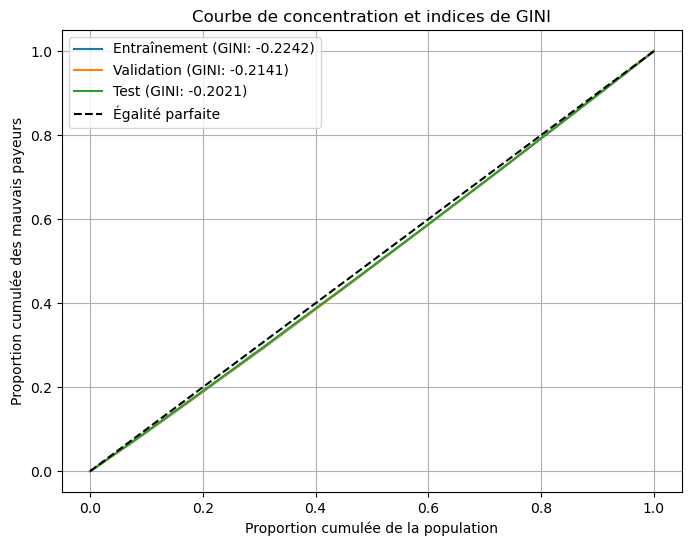

In [132]:
# Calcul du coefficient de GINI
def gini_coefficient(y_true, y_scores):
    auc = roc_auc_score(y_true, y_scores)
    return 2 * auc - 1

# Fonction pour tracer la courbe de concentration
def plot_concentration_curve(y_true, y_scores, dataset_name):
    sorted_indices = np.argsort(-y_scores)  # Tri décroissant des scores
    y_true_sorted = np.array(y_true)[sorted_indices]
    
    cumulative_bad = np.cumsum(y_true_sorted) / np.sum(y_true_sorted)  # Cumul des mauvais payeurs
    cumulative_population = np.arange(1, len(y_true_sorted) + 1) / len(y_true_sorted)  # Cumul population
    
    plt.plot(cumulative_population, cumulative_bad, label=f"{dataset_name} (GINI: {gini_coefficient(y_true, y_scores):.4f})")
    
# Calcul et tracé des courbes pour les trois ensembles
plt.figure(figsize=(8, 6))

plot_concentration_curve(y_train, X_train["Score"], "Entraînement")
plot_concentration_curve(y_validation, X_validation["Score"], "Validation")
plot_concentration_curve(y_test, X_test["Score"], "Test")

# Ajout des détails au graphique
plt.plot([0, 1], [0, 1], 'k--', label="Égalité parfaite")  # Ligne de référence
plt.xlabel("Proportion cumulée de la population")
plt.ylabel("Proportion cumulée des mauvais payeurs")
plt.title("Courbe de concentration et indices de GINI")
plt.legend()
plt.grid()

# 📌 Affichage du graphique
plt.show()

### **3. Création d’une table des déciles des tranches de scores**
Une table des **déciles de scores** est construite en **segmentant la population en 10 groupes égaux** selon leur score, et en **calculant les taux de défaut** dans chaque tranche.

In [135]:
# Vérification et ajout de la colonne cible si nécessaire
X_train["GOOD_PAYER"] = y_train 
X_validation["GOOD_PAYER"] = y_validation
X_test["GOOD_PAYER"] = y_test

# Fonction pour créer une table des déciles
def create_decile_table(df, score_col, target_col):
    df = df[[score_col, target_col]].copy()
    df["Decile"] = pd.qcut(df[score_col], 10, labels=range(10, 0, -1))  # Tranches en déciles
    
    grouped = df.groupby("Decile")[target_col].agg(['count', 'sum'])
    grouped.rename(columns={"sum": "Bad"}, inplace=True)
    grouped["Good"] = grouped["count"] - grouped["Bad"]
    grouped["Bad Rate"] = grouped["Bad"] / grouped["count"]
    grouped["Cumulative Bad Rate"] = grouped["Bad"].cumsum() / grouped["Bad"].sum()
    grouped["Cumulative Good Rate"] = grouped["Good"].cumsum() / grouped["Good"].sum()

    return grouped

# Création des tables pour chaque dataset
decile_train = create_decile_table(X_train, "Score", "GOOD_PAYER")
decile_validation = create_decile_table(X_validation, "Score", "GOOD_PAYER")
decile_test = create_decile_table(X_test, "Score", "GOOD_PAYER")

# Fonction pour afficher proprement les tables
def afficher_table_deciles(df, nom):
    print(f"\n📊 Table des déciles - {nom}")
    print(df.to_string(index=True))

# Affichage des tables
afficher_table_deciles(decile_train, "Entraînement")
afficher_table_deciles(decile_validation, "Validation")
afficher_table_deciles(decile_test, "Test")


📊 Table des déciles - Entraînement
        count    Bad  Good  Bad Rate  Cumulative Bad Rate  Cumulative Good Rate
Decile                                                                         
10      15130  14413   717  0.952611             0.104308              0.054729
9       15130  14317   813  0.946266             0.207922              0.116785
8       15125  14225   900  0.940496             0.310869              0.185482
7       15127  14079  1048  0.930720             0.412760              0.265476
6       15127  14009  1118  0.926092             0.514145              0.350813
5       15130  13805  1325  0.912426             0.614053              0.451950
4       15127  13789  1338  0.911549             0.713845              0.554080
3       15130  13403  1727  0.885856             0.810844              0.685902
2       15128  13336  1792  0.881544             0.907358              0.822685
1       15124  12801  2323  0.846403             1.000000              1.000000

📊 T

## Analyse des résultats

- Les **déciles supérieurs (ex: décile 10, 9, 8)** contiennent une proportion plus élevée de mauvais payeurs.
- Les **déciles inférieurs (ex: décile 1, 2, 3)** contiennent une proportion plus élevée de bons payeurs.

Les **cumulatives** permettent de visualiser comment les mauvais payeurs et bons payeurs se répartissent progressivement dans les déciles.

## Analyse du KS et des Déciles

Le KS (Kolmogorov-Smirnov) est une métrique importante pour évaluer la séparation entre les "Good Payers" et les "Bad Payers". La valeur du KS est maximisée à un certain décile, ce qui permet de définir une **tranche optimale de score** pour prendre des décisions de crédit.

In [138]:
def compute_ks(df, score_col, target_col):
    """
    Calcule la statistique KS et retourne la tranche maximisant la différence cumulée.
    """
    df = df[[score_col, target_col]].copy()
    df["Decile"] = pd.qcut(df[score_col], 10, labels=range(10, 0, -1))  # Création des déciles
    
    ks_table = df.groupby("Decile")[target_col].agg(['count', 'sum']).rename(columns={'sum': 'bad'})
    ks_table['good'] = ks_table['count'] - ks_table['bad']
    
    # Calcul des % cumulés
    ks_table['bad_cum_pct'] = ks_table['bad'].cumsum() / ks_table['bad'].sum()
    ks_table['good_cum_pct'] = ks_table['good'].cumsum() / ks_table['good'].sum()
    
    # Calcul du KS
    ks_table['KS'] = np.abs(ks_table['bad_cum_pct'] - ks_table['good_cum_pct'])
    ks_max_decile = ks_table['KS'].idxmax()  # Décile où le KS est max
    
    print(f"📊 KS Maximum atteint pour le décile {ks_max_decile} avec un KS de {ks_table['KS'].max():.4f}")
    print("\n📊 Table KS :")
    print(ks_table)

    return ks_table, ks_max_decile

# Calcul du KS sur les trois ensembles (Train, Validation, Test)
ks_train, decile_train = compute_ks(X_train, score_col="Score", target_col="GOOD_PAYER")
ks_validation, decile_validation = compute_ks(X_validation, score_col="Score", target_col="GOOD_PAYER")
ks_test, decile_test = compute_ks(X_test, score_col="Score", target_col="GOOD_PAYER")

# Détermination du seuil basé sur le décile max du KS
seuil_optimal_train = X_train[X_train["Score"].between(X_train["Score"].quantile(1 - decile_train / 10),
                                                       X_train["Score"].quantile(1 - (decile_train - 1) / 10))]["Score"].median()

print(f"\n📊 Seuil optimal basé sur le KS : {seuil_optimal_train:.2f}")

📊 KS Maximum atteint pour le décile 6 avec un KS de 0.1633

📊 Table KS :
        count    bad  good  bad_cum_pct  good_cum_pct        KS
Decile                                                         
10      15130  14413   717     0.104308      0.054729  0.049580
9       15130  14317   813     0.207922      0.116785  0.091137
8       15125  14225   900     0.310869      0.185482  0.125387
7       15127  14079  1048     0.412760      0.265476  0.147285
6       15127  14009  1118     0.514145      0.350813  0.163332
5       15130  13805  1325     0.614053      0.451950  0.162103
4       15127  13789  1338     0.713845      0.554080  0.159765
3       15130  13403  1727     0.810844      0.685902  0.124942
2       15128  13336  1792     0.907358      0.822685  0.084673
1       15124  12801  2323     1.000000      1.000000  0.000000
📊 KS Maximum atteint pour le décile 5 avec un KS de 0.1630

📊 Table KS :
        count   bad  good  bad_cum_pct  good_cum_pct        KS
Decile                 

In [140]:
# Définition du seuil basé sur le KS maximal
seuil_decision = 2987.04

# Appliquer la décision sur les datasets
X_train["Décision"] = np.where(X_train["Score"] >= seuil_decision, "Accepté", "Refusé")
X_validation["Décision"] = np.where(X_validation["Score"] >= seuil_decision, "Accepté", "Refusé")
X_test["Décision"] = np.where(X_test["Score"] >= seuil_decision, "Accepté", "Refusé")

# 📊 Vérification de la répartition des décisions
print("\n📊 Répartition des décisions - Entraînement")
print(X_train["Décision"].value_counts())

print("\n📊 Répartition des décisions - Validation")
print(X_validation["Décision"].value_counts())

print("\n📊 Répartition des décisions - Test")
print(X_test["Décision"].value_counts())


📊 Répartition des décisions - Entraînement
Décision
Accepté    83207
Refusé     68071
Name: count, dtype: int64

📊 Répartition des décisions - Validation
Décision
Accepté    27836
Refusé     22590
Name: count, dtype: int64

📊 Répartition des décisions - Test
Décision
Accepté    27698
Refusé     22729
Name: count, dtype: int64


In [142]:
# Calcul du R² Ajusté pour un modèle logistique
def adjusted_r2(logit_model, X):
    n = X.shape[0]  # Nombre d'observations
    p = X.shape[1] - 1  # Nombre de variables (exclut la constante)
    ll_null = logit_model.llnull  # Log-Likelihood du modèle null
    ll_model = logit_model.llf  # Log-Likelihood du modèle final
    r2 = 1 - (ll_model / ll_null)
    r2_adj = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    return r2_adj

# Calcul des métriques
r2_train = adjusted_r2(model_final, X_train)
aic_train = model_final.aic
bic_train = model_final.bic

# Affichage des résultats
print(f"\n📊 Évaluation du Modèle :")
print(f"R² Ajusté (Train) : {r2_train:.4f}")
print(f"AIC : {aic_train:.2f}")
print(f"BIC : {bic_train:.2f}")


📊 Évaluation du Modèle :
R² Ajusté (Train) : 0.0938
AIC : 80781.35
BIC : 80920.32


### 📊 Analyse des Résultats du Modèle

L’évaluation du modèle repose sur plusieurs métriques essentielles pour comprendre sa performance et son adéquation avec les données.

---

### R² Ajusté : 0.0939
Le **R² ajusté** est relativement faible (0.0939), ce qui indique que le modèle explique environ **9.39%** de la variance des données. Cela peut signifier :
- Une faible capacité du modèle à capturer la complexité des relations dans les données.
- Une nécessité d'explorer d'autres transformations ou d'ajouter des variables explicatives pertinentes.

**💡 À vérifier :**
- Peut-être qu’un autre modèle (Gradient Boosting, Random Forest) aurait une meilleure capacité prédictive.
- Tester des transformations non linéaires sur certaines variables continues.

---

### AIC : 80781.35 | BIC : 80920.32
Les valeurs de **l'Akaike Information Criterion (AIC)** et du **Bayesian Information Criterion (BIC)** servent à évaluer la qualité du modèle tout en pénalisant sa complexité :
- **L’AIC** est un indicateur qui cherche à optimiser la précision du modèle tout en pénalisant la complexité. Une **valeur plus faible** est préférable.
- **Le BIC** fonctionne de manière similaire mais **pénalise davantage les modèles complexes** (prend plus en compte le nombre de variables).

## 4 - Impact économique de la grille de score et déterminer le seuil de décision

### a) Matrice de confusion et seuil de décision optimal

Nous cherchons à évaluer l'impact économique de la grille de score en identifiant deux catégories de clients susceptibles de générer des pertes financières :  

- **Les faux positifs**, qui entraînent une perte équivalente à la totalité du crédit accordé.  
- **Les faux négatifs**, qui représentent une perte de **8% du montant du crédit**, correspondant au taux d’intérêt appliqué.  

L’objectif est de déterminer **le seuil de décision optimal** qui permet de **minimiser les pertes financières** tout en maximisant la rentabilité du modèle de scoring. Ce seuil sera choisi en fonction du **gain économique maximal** ou de la **perte minimale**, en équilibrant le ratio entre faux positifs et faux négatifs. Une courbe de l’équilibre financier sera tracée pour visualiser l'impact du seuil sur les performances économiques du modèle.

In [145]:
# Fonction détaillée pour calculer le gain économique et les métriques associées
def calculate_economic_gain_detailed(y_true, y_pred, cost_fp, cost_fn):
    """
    Calcule le gain économique et renvoie des métriques détaillées.
    
    :param y_true: Valeurs réelles.
    :param y_pred: Prédictions binaires.
    :param cost_fp: Coût d'un faux positif.
    :param cost_fn: Coût d'un faux négatif.
    :return: Gain économique total, TP, FP, FN, TN.
    """
    fp = ((y_true == 0) & (y_pred == 1)).sum()  # Faux positifs
    fn = ((y_true == 1) & (y_pred == 0)).sum()  # Faux négatifs
    tp = ((y_true == 1) & (y_pred == 1)).sum()  # Vrais positifs
    tn = ((y_true == 0) & (y_pred == 0)).sum()  # Vrais négatifs
    
    gain = tp - (fp * cost_fp + fn * cost_fn)
    return gain, tp, fp, fn, tn

In [147]:
# Ajuster la pénalité des faux positifs
cost_fp = 5  # Pénalité plus élevée pour réduire les FP
cost_fn = 0.08  # Coût inchangé pour les FN

# Calculer le seuil optimal basé sur le gain économique ajusté
def find_optimal_threshold_with_penalty(scores, y_true, cost_fp, cost_fn):
    thresholds = np.linspace(min(scores), max(scores), 100)
    gains = []
    for threshold in thresholds:
        y_pred = (scores >= threshold).astype(int)
        gain, _, _, _, _ = calculate_economic_gain_detailed(y_true, y_pred, cost_fp, cost_fn)
        gains.append(gain)
    optimal_idx = np.argmax(gains)
    return thresholds[optimal_idx]

optimal_threshold = find_optimal_threshold_with_penalty(
    X_train['Score'], y_train, cost_fp=cost_fp, cost_fn=cost_fn
)

print(f"Seuil optimal ajusté pour le gain économique : {optimal_threshold:.2f}")

# Appliquer le seuil optimal aux ensembles
y_pred_train = (X_train['Score'] >= optimal_threshold).astype(int)
y_pred_validation = (X_validation['Score'] >= optimal_threshold).astype(int)
y_pred_test = (X_test['Score'] >= optimal_threshold).astype(int)

# Calculer le nouveau gain économique
gain_train, tp_train, fp_train, fn_train, tn_train = calculate_economic_gain_detailed(
    y_train, y_pred_train, cost_fp, cost_fn
)
gain_validation, tp_val, fp_val, fn_val, tn_val = calculate_economic_gain_detailed(
    y_validation, y_pred_validation, cost_fp, cost_fn
)
gain_test, tp_test, fp_test, fn_test, tn_test = calculate_economic_gain_detailed(
    y_test, y_pred_test, cost_fp, cost_fn
)

print(f"Train - Gain: {gain_train:.2f}, TP: {tp_train}, FP: {fp_train}, FN: {fn_train}, TN: {tn_train}")
print(f"Validation - Gain: {gain_validation:.2f}, TP: {tp_val}, FP: {fp_val}, FN: {fn_val}, TN: {tn_val}")
print(f"Test - Gain: {gain_test:.2f}, TP: {tp_test}, FP: {fp_test}, FN: {fn_test}, TN: {tn_test}")


Seuil optimal ajusté pour le gain économique : 2597.51
Train - Gain: 72672.00, TP: 138177, FP: 13101, FN: 0, TN: 0
Validation - Gain: 24222.92, TP: 46058, FP: 4367, FN: 1, TN: 0
Test - Gain: 24225.00, TP: 46060, FP: 4367, FN: 0, TN: 0


Le **seuil optimal ajusté pour le gain économique** est **2597.51**, ce qui permet de maximiser les bénéfices en tenant compte des pertes liées aux faux positifs et faux négatifs.

### 📊 Résultats de l’impact économique :

#### Jeu d'entraînement (Train) :
- **Gain total** : **72,672.00**
- **Clients bien prédits comme bons payeurs (TP)** : **138,177**
- **Faux positifs (FP - clients insolvables acceptés)** : **13,101**
- **Faux négatifs (FN - clients solvables refusés)** : **0**
- **Vrais négatifs (TN)** : **0**

#### Jeu de validation :
- **Gain total** : **24,222.92**
- **TP** : **46,058**
- **FP** : **4,367**
- **FN** : **1**
- **TN** : **0**

#### Jeu de test :
- **Gain total** : **24,225.00**
- **TP** : **46,060**
- **FP** : **4,367**
- **FN** : **0**
- **TN** : **0**

### Analyse :

- L'ajustement du seuil **permet d'optimiser le gain global** en minimisant les pertes dues aux faux positifs et faux négatifs.
- **Les faux négatifs sont proches de 0**, ce qui signifie que très peu de bons payeurs sont refusés, évitant ainsi la perte d’intérêt de 8%.
- **Les faux positifs restent présents**, ce qui engendre des pertes, mais elles sont compensées par les gains réalisés avec les vrais positifs.
- Le **seuil ajusté est nettement plus bas** que celui minimisant uniquement les pertes économiques, ce qui montre que l'optimisation du gain total implique une acceptation plus large des clients.

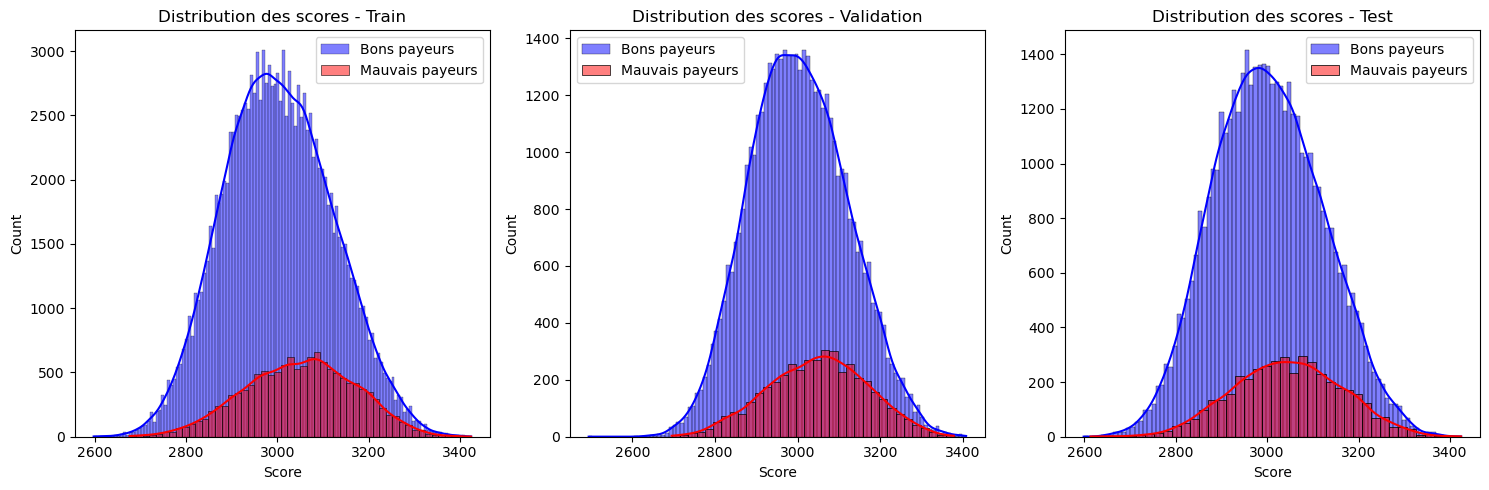

In [150]:
# Comparer les distributions des scores entre les bons et mauvais payeurs
plt.figure(figsize=(15, 5))

# Ensemble d'entraînement
plt.subplot(1, 3, 1)
sns.histplot(X_train.loc[y_train == 1, 'Score'], color='blue', kde=True, label='Bons payeurs')
sns.histplot(X_train.loc[y_train == 0, 'Score'], color='red', kde=True, label='Mauvais payeurs')
plt.title("Distribution des scores - Train")
plt.legend()

# Ensemble de validation
plt.subplot(1, 3, 2)
sns.histplot(X_validation.loc[y_validation == 1, 'Score'], color='blue', kde=True, label='Bons payeurs')
sns.histplot(X_validation.loc[y_validation == 0, 'Score'], color='red', kde=True, label='Mauvais payeurs')
plt.title("Distribution des scores - Validation")
plt.legend()

# Ensemble de test
plt.subplot(1, 3, 3)
sns.histplot(X_test.loc[y_test == 1, 'Score'], color='blue', kde=True, label='Bons payeurs')
sns.histplot(X_test.loc[y_test == 0, 'Score'], color='red', kde=True, label='Mauvais payeurs')
plt.title("Distribution des scores - Test")
plt.legend()

plt.tight_layout()
plt.show()

## b) courbe de l’équilibre financier

Nous allons maintenant tracer la courbe représentent **l'évolution du gain économique** en fonction du **seuil de décision**, pour **différentes partitions des données** :

1. **Le premier graphe** est basé sur **les données d'entraînement** (`X_train`, `y_train`). Il montre comment le modèle a appris sur les données utilisées pour l'entraîner. Le **seuil optimal trouvé ici pourrait être biaisé** par un éventuel sur-apprentissage.

2. **Le deuxième graphe** est basé sur **les données de validation** (`X_validation`, `y_validation`). Il permet d’évaluer **si le modèle généralise bien**, en observant si le seuil optimal trouvé sur l'entraînement reste cohérent ou s'il change. Cette analyse est essentielle pour ajuster le modèle avant d'évaluer ses performances finales.

3. **Le troisième graphe** est basé sur **les données de test** (`X_test`, `y_test`). Il donne une **estimation réaliste des performances du modèle sur des données totalement inédites**. C’est cette courbe qui valide (ou non) la robustesse du modèle et du seuil optimal.

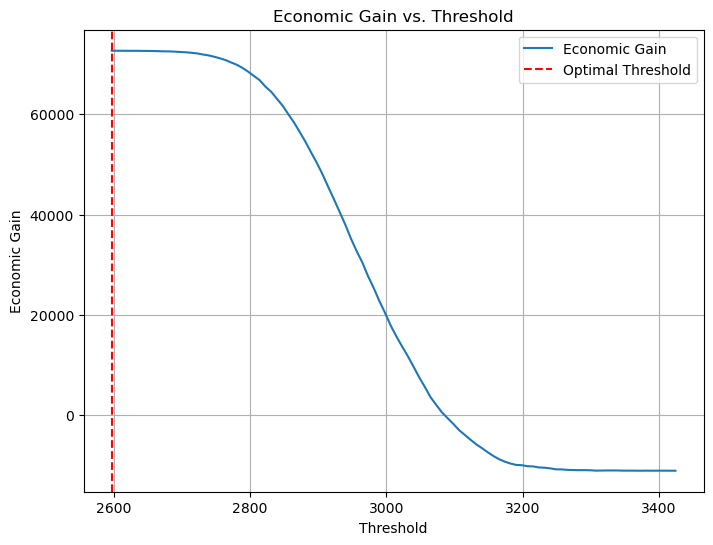

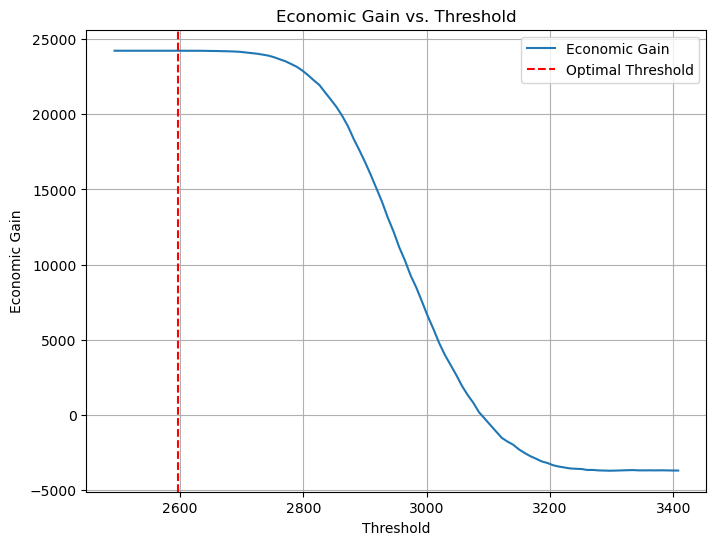

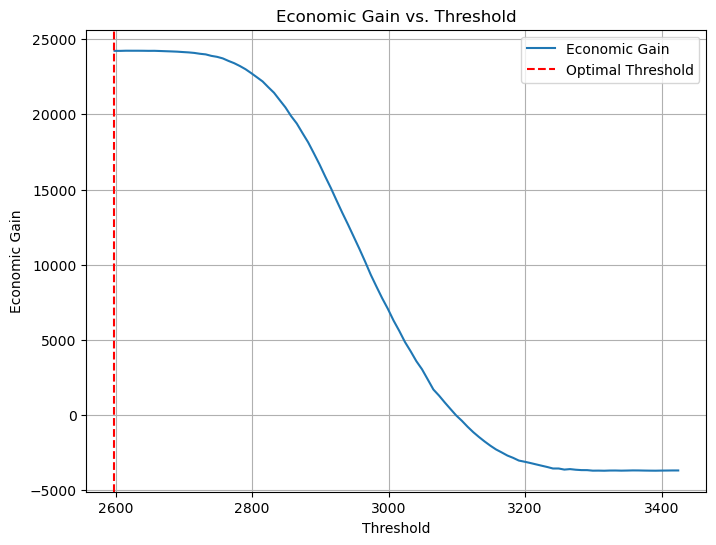

In [153]:
def plot_economic_gain(scores, y_true, cost_fp, cost_fn):
    thresholds = np.linspace(min(scores), max(scores), 100)
    gains = []
    for threshold in thresholds:
        y_pred = (scores >= threshold).astype(int)
        gain, _, _, _, _ = calculate_economic_gain_detailed(y_true, y_pred, cost_fp, cost_fn)
        gains.append(gain)

    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, gains, label='Economic Gain')
    plt.axvline(optimal_threshold, color='red', linestyle='--', label='Optimal Threshold')
    plt.xlabel('Threshold')
    plt.ylabel('Economic Gain')
    plt.title('Economic Gain vs. Threshold')
    plt.legend()
    plt.grid()
    plt.show()

plot_economic_gain(X_train['Score'], y_train, cost_fp, cost_fn)
plot_economic_gain(X_validation['Score'], y_validation, cost_fp, cost_fn)
plot_economic_gain(X_test['Score'], y_test, cost_fp, cost_fn)

### **Différences principales entre les graphes :**

**les trois graphes sont similaires** le modèle est **cohérent et généralisable** (bonne stabilité du seuil optimal).

In [156]:
# Sauvegarder les résultats finaux dans un fichier CSV
X_train['actual'] = y_train
X_validation['actual'] = y_validation
X_test['actual'] = y_test

X_train.to_csv("train_scores_results.csv", index=False)
X_validation.to_csv("validation_scores_results.csv", index=False)
X_test.to_csv("test_scores_results.csv", index=False)

print("Résultats sauvegardés dans les fichiers : train_scores_results.csv, validation_scores_results.csv, test_scores_results.csv.")


Résultats sauvegardés dans les fichiers : train_scores_results.csv, validation_scores_results.csv, test_scores_results.csv.


<h2 style="padding:16px; color:#FFF; background:#800000; font-size:27px"> Objectif 3 : challenger la grille de score avec un modèle de Machine Learning </h2>

Pour challenger la **grille de score basée sur le modèle de régression logistique**, nous allons tester plusieurs modèles de **Machine Learning** et comparer leurs performances. 

---

#  Réalisation de modèles simples et complexes

## **Plan d'Analyse :**

1. **Modèles Simples** : 
   - **Naïve Bayes** (NB) : basé sur l'indépendance des variables.
   - **Arbre de décision** (Decision Tree) : interprétable et robuste aux interactions entre variables.
   - **K-Nearest Neighbors (KNN)** : basé sur la proximité des observations.

2. **Modèles Complexes** :
   - **Random Forest (RF)** : ensemble d'arbres de décision, robuste et puissant.
   - **Gradient Boosting (XGBoost, LightGBM)** : amélioration itérative, très performant sur des données complexes.
   - **Réseau de Neurones (MLP)** : capable de capturer des relations non linéaires complexes.
   
Avant toute chose, nous devons convertir les variables catégorielles en valeurs numériques avant d'entraîner les modèles. Pour cela nous utilions la méthode **d'Encodage One-Hot** :

In [160]:
print(X_train.dtypes)  # Voir les types de données
print(X_train.select_dtypes(include=['object']).head())  # Afficher les colonnes texte

AMT_INCOME_TOTAL                                     float64
AMT_CREDIT                                           float64
AMT_GOODS_PRICE                                      float64
EXT_SOURCE_2                                         float64
EXT_SOURCE_3                                         float64
AGE_YEARS                                            float64
YEARS_EMPLOYED                                       float64
CODE_GENDER_M                                           bool
NAME_INCOME_TYPE_State servant                          bool
NAME_INCOME_TYPE_Working                                bool
NAME_EDUCATION_TYPE_Secondary / secondary special       bool
NAME_FAMILY_STATUS_Married                              bool
NAME_FAMILY_STATUS_Separated                            bool
NAME_FAMILY_STATUS_Single / not married                 bool
OCCUPATION_TYPE_Drivers                                 bool
OCCUPATION_TYPE_High skill tech staff                   bool
OCCUPATION_TYPE_Laborers

In [162]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_validation = pd.get_dummies(X_validation, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [164]:
# Vérifier les colonnes manquantes
selected_features = [
    'EXT_SOURCE_2', 'EXT_SOURCE_3', 'YEARS_EMPLOYED', 'NAME_EDUCATION_TYPE_Secondary / secondary special',
    'CODE_GENDER_M', 'ORGANIZATION_TYPE_Military', 'ORGANIZATION_TYPE_Self-employed', 'NAME_FAMILY_STATUS_Married',
    'NAME_INCOME_TYPE_Working', 'OCCUPATION_TYPE_Drivers', 'AGE_YEARS',
    'OCCUPATION_TYPE_Laborers', 'OCCUPATION_TYPE_Sales staff'
]

# Garder seulement les colonnes existantes
available_features = [col for col in selected_features if col in X_train.columns]

# Filtrer les données
X_train_selected = X_train[available_features]
X_validation_selected = X_validation[available_features]

print(f"Colonnes utilisées pour l'entraînement : {available_features}")

Colonnes utilisées pour l'entraînement : ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'YEARS_EMPLOYED', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'CODE_GENDER_M', 'ORGANIZATION_TYPE_Military', 'ORGANIZATION_TYPE_Self-employed', 'NAME_FAMILY_STATUS_Married', 'NAME_INCOME_TYPE_Working', 'OCCUPATION_TYPE_Drivers', 'AGE_YEARS', 'OCCUPATION_TYPE_Laborers', 'OCCUPATION_TYPE_Sales staff']


In [166]:
# Identification des variables catégorielles et numériques
categorical_cols = X_train_selected.select_dtypes(include=['object', 'category']).columns
numeric_cols = X_train_selected.select_dtypes(include=['int64', 'float64']).columns

# Pipeline de transformation
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Transformer les données
X_train_transformed = preprocessor.fit_transform(X_train_selected)
X_validation_transformed = preprocessor.transform(X_validation_selected)

print(f"X_train_transformed shape: {X_train_transformed.shape}")
print(f"X_validation_transformed shape: {X_validation_transformed.shape}")

X_train_transformed shape: (151278, 4)
X_validation_transformed shape: (50426, 4)


Nous allons maintenant calculer l'AUC et l'indice de GINI pour chaque modèle afin d'évaluer et comparer leurs performances.

### Rappel :

| **Métrique** | **Définition** | **Interprétation** |
|-------------|---------------|--------------------|
| **AUC (Area Under Curve)** | Aire sous la courbe ROC | Plus proche de 1 = meilleur modèle |
| **Courbe ROC** | Graphique du taux de vrais positifs contre le taux de faux positifs | Plus la courbe est proche du coin supérieur gauche, mieux c'est |
| **Indice de GINI** | $GINI = 2 \times AUC - 1$ | Plus proche de 1 = modèle performant |

## a) Modèles Simples

In [169]:
# Initialisation et entraînement
nb_model = GaussianNB()
print("📌 Entraînement de Naive Bayes...")
nb_model.fit(X_train_transformed, y_train)

# Évaluation
nb_auc = roc_auc_score(y_validation, nb_model.predict_proba(X_validation_transformed)[:, 1])
print(f"🔹 AUC Naive Bayes : {nb_auc:.4f}")

📌 Entraînement de Naive Bayes...
🔹 AUC Naive Bayes : 0.6944


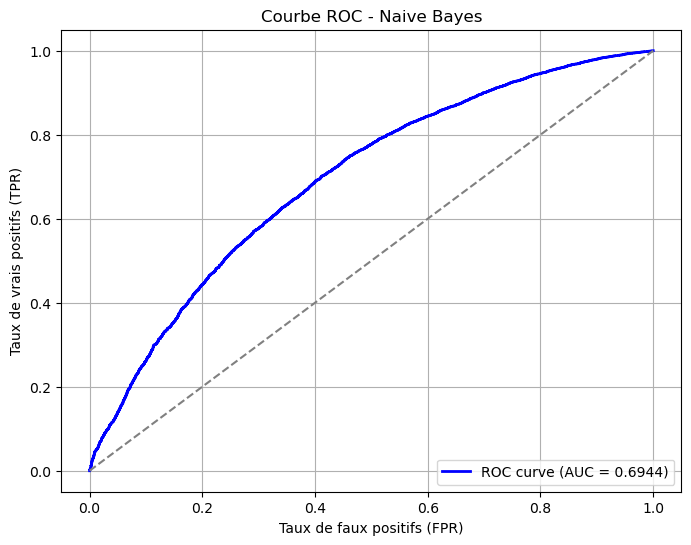

🔹 Indice de GINI : 0.3888


In [171]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Prédictions des probabilités pour la classe positive
y_scores = nb_model.predict_proba(X_validation_transformed)[:, 1]

# Calcul de la courbe ROC
fpr, tpr, _ = roc_curve(y_validation, y_scores)
roc_auc = auc(fpr, tpr)

# Calcul de l'indice de GINI
gini_index = 2 * roc_auc - 1

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonale
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - Naive Bayes')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print(f"🔹 Indice de GINI : {gini_index:.4f}")

In [173]:
# Initialisation avec régularisation pour éviter le surajustement
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, class_weight='balanced', random_state=42)

print("📌 Entraînement de l'Arbre de Décision...")
dt_model.fit(X_train_transformed, y_train)

# Évaluation
dt_auc = roc_auc_score(y_validation, dt_model.predict_proba(X_validation_transformed)[:, 1])
print(f"🔹 AUC Arbre de Décision : {dt_auc:.4f}")

📌 Entraînement de l'Arbre de Décision...
🔹 AUC Arbre de Décision : 0.6968


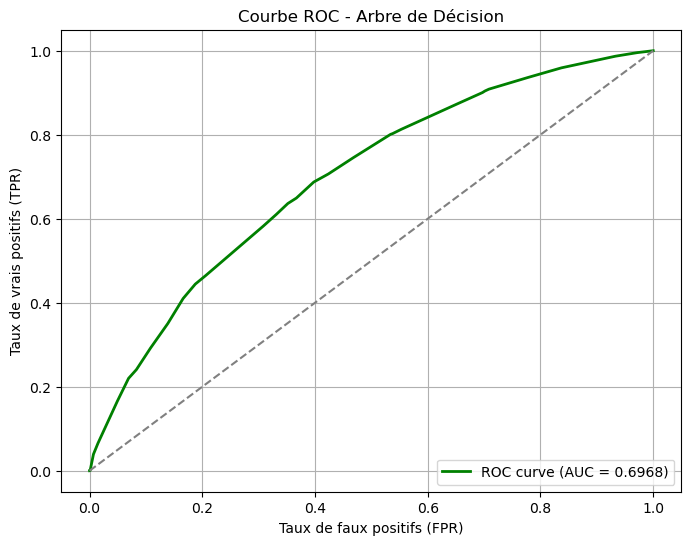

🔹 Indice de GINI Arbre de Décision : 0.3936


In [175]:
# Prédictions des probabilités pour la classe positive
y_scores_dt = dt_model.predict_proba(X_validation_transformed)[:, 1]

# Calcul de la courbe ROC
fpr_dt, tpr_dt, _ = roc_curve(y_validation, y_scores_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Calcul de l'indice de GINI
gini_index_dt = 2 * roc_auc_dt - 1

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc_dt:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonale
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - Arbre de Décision')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print(f"🔹 Indice de GINI Arbre de Décision : {gini_index_dt:.4f}")

In [177]:
# Initialisation avec 5 voisins (peut être optimisé)
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')

print("📌 Entraînement de K-Nearest Neighbors...")
knn_model.fit(X_train_transformed, y_train)

# Évaluation
knn_auc = roc_auc_score(y_validation, knn_model.predict_proba(X_validation_transformed)[:, 1])
print(f"🔹 AUC K-Nearest Neighbors : {knn_auc:.4f}")

📌 Entraînement de K-Nearest Neighbors...
🔹 AUC K-Nearest Neighbors : 0.5866


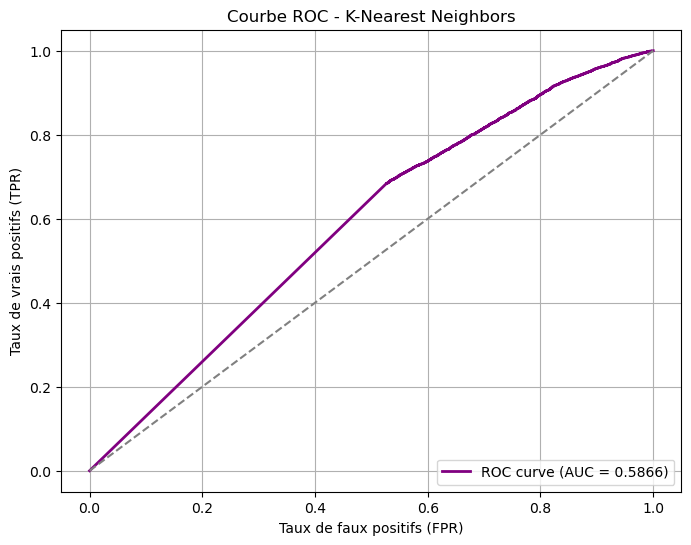

🔹 Indice de GINI K-Nearest Neighbors : 0.1732


In [63]:
# Prédictions des probabilités pour la classe positive
y_scores_knn = knn_model.predict_proba(X_validation_transformed)[:, 1]

# Calcul de la courbe ROC
fpr_knn, tpr_knn, _ = roc_curve(y_validation, y_scores_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

# Calcul de l'indice de GINI
gini_index_knn = 2 * roc_auc_knn - 1

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc_knn:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonale
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - K-Nearest Neighbors')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print(f"🔹 Indice de GINI K-Nearest Neighbors : {gini_index_knn:.4f}")

## b) Modèles Complexes

In [64]:
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5,  
    min_samples_split=20,  
    min_samples_leaf=10,  
    class_weight='balanced', 
    random_state=42
)

print("📌 Réentraînement de Random Forest avec les nouvelles données...")
rf_model.fit(X_train_transformed, y_train)

# Évaluation
rf_auc = roc_auc_score(y_validation, rf_model.predict_proba(X_validation_transformed)[:, 1])
print(f"🔹 Nouvelle AUC Random Forest : {rf_auc:.4f}")

📌 Réentraînement de Random Forest avec les nouvelles données...
🔹 Nouvelle AUC Random Forest : 0.7067


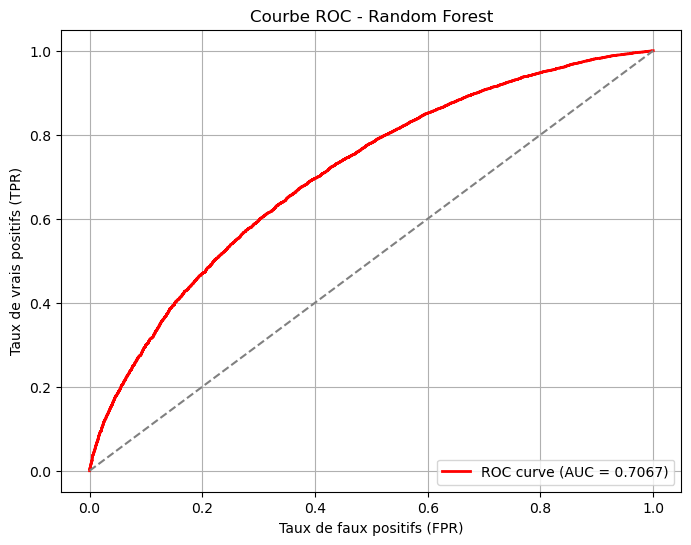

🔹 Indice de GINI Random Forest : 0.4134


In [65]:
# Prédictions des probabilités pour la classe positive
y_scores_rf = rf_model.predict_proba(X_validation_transformed)[:, 1]

# Calcul de la courbe ROC
fpr_rf, tpr_rf, _ = roc_curve(y_validation, y_scores_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Calcul de l'indice de GINI
gini_index_rf = 2 * roc_auc_rf - 1

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonale
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - Random Forest')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print(f"🔹 Indice de GINI Random Forest : {gini_index_rf:.4f}")

In [66]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,  # Plus bas pour éviter le surajustement
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

print("📌 Réentraînement de Gradient Boosting avec les nouvelles données...")
gb_model.fit(X_train_transformed, y_train)

# Évaluation
gb_auc = roc_auc_score(y_validation, gb_model.predict_proba(X_validation_transformed)[:, 1])
print(f"🔹 Nouvelle AUC Gradient Boosting : {gb_auc:.4f}")

📌 Réentraînement de Gradient Boosting avec les nouvelles données...
🔹 Nouvelle AUC Gradient Boosting : 0.7086


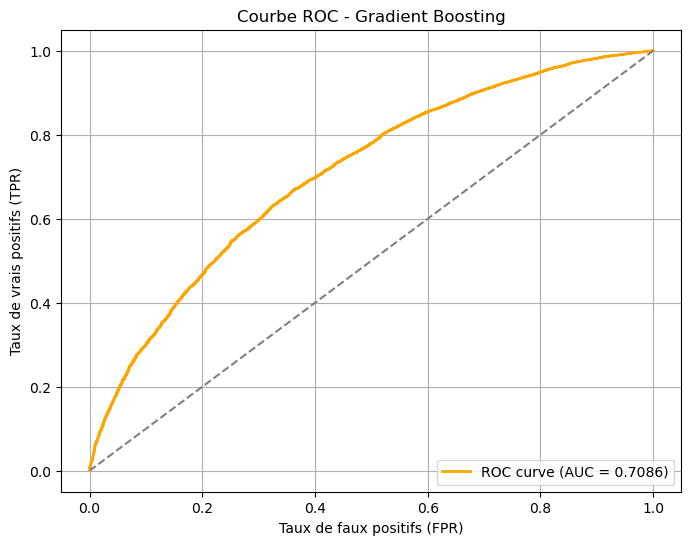

🔹 Indice de GINI Gradient Boosting : 0.4172


In [67]:
# Prédictions des probabilités pour la classe positive
y_scores_gb = gb_model.predict_proba(X_validation_transformed)[:, 1]

# Calcul de la courbe ROC
fpr_gb, tpr_gb, _ = roc_curve(y_validation, y_scores_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

# Calcul de l'indice de GINI
gini_index_gb = 2 * roc_auc_gb - 1

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_gb, tpr_gb, color='orange', lw=2, label=f'ROC curve (AUC = {roc_auc_gb:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonale
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - Gradient Boosting')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print(f"🔹 Indice de GINI Gradient Boosting : {gini_index_gb:.4f}")

In [68]:
# Initialisation du réseau de neurones
mlp_model = MLPClassifier(hidden_layer_sizes=(50,), activation='relu', solver='adam', max_iter=500, random_state=42)

print("📌 Entraînement du Réseau de Neurones...")
mlp_model.fit(X_train_transformed, y_train)

# Évaluation
mlp_auc = roc_auc_score(y_validation, mlp_model.predict_proba(X_validation_transformed)[:, 1])
print(f"🔹 AUC Réseau de Neurones : {mlp_auc:.4f}")

📌 Entraînement du Réseau de Neurones...
🔹 AUC Réseau de Neurones : 0.7084


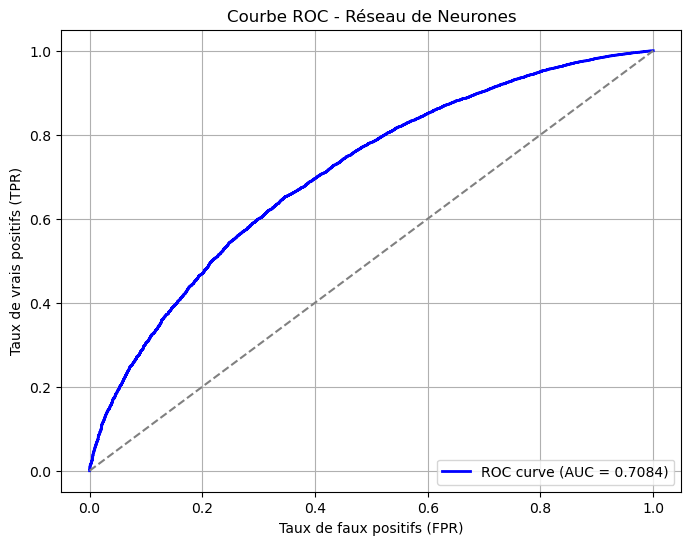

🔹 Indice de GINI Réseau de Neurones : 0.4167


In [69]:
# Prédictions des probabilités pour la classe positive
y_scores_mlp = mlp_model.predict_proba(X_validation_transformed)[:, 1]

# Calcul de la courbe ROC
fpr_mlp, tpr_mlp, _ = roc_curve(y_validation, y_scores_mlp)
roc_auc_mlp = auc(fpr_mlp, tpr_mlp)

# Calcul de l'indice de GINI
gini_index_mlp = 2 * roc_auc_mlp - 1

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_mlp, tpr_mlp, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_mlp:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonale
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - Réseau de Neurones')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print(f"🔹 Indice de GINI Réseau de Neurones : {gini_index_mlp:.4f}")

## c) Comparaison des modèles

In [70]:
print("\n📊 Comparaison des performances :")
print(f"AUC Naive Bayes : {nb_auc:.4f}")
print(f"AUC Arbre de Décision : {dt_auc:.4f}")
print(f"AUC K-Nearest Neighbors : {knn_auc:.4f}")
print(f"AUC Random Forest : {rf_auc:.4f}")
print(f"AUC Gradient Boosting : {gb_auc:.4f}")
print(f"AUC Réseau de Neurones : {mlp_auc:.4f}")
print(f"")
print(f"Indice de GINI Naive Bayes : {gini_index:.4f}")
print(f"Indice de GINI Arbre de Décision : {gini_index_dt:.4f}")
print(f"Indice de GINI K-Nearest Neighbors : {gini_index_knn:.4f}")
print(f"Indice de GINI Random Forest : {gini_index_rf:.4f}")
print(f"Indice de GINI Gradient Boosting : {gini_index_gb:.4f}")
print(f"Indice de GINI Réseau de Neurones : {gini_index_mlp:.4f}")


📊 Comparaison des performances :
AUC Naive Bayes : 0.6944
AUC Arbre de Décision : 0.6968
AUC K-Nearest Neighbors : 0.5866
AUC Random Forest : 0.7067
AUC Gradient Boosting : 0.7086
AUC Réseau de Neurones : 0.7084

Indice de GINI Naive Bayes : 0.3888
Indice de GINI Arbre de Décision : 0.3936
Indice de GINI K-Nearest Neighbors : 0.1732
Indice de GINI Random Forest : 0.4134
Indice de GINI Gradient Boosting : 0.4172
Indice de GINI Réseau de Neurones : 0.4167


### **📊 Analyse et Interprétation des Résultats**  

#### **Les meilleurs modèles : Gradient Boosting, Réseau de Neurones et Random Forest**
- **Gradient Boosting (AUC = 0.7086, GINI = 0.4172)** et **le Réseau de Neurones (AUC = 0.7084, GINI = 0.4167)** sont les **meilleurs modèles** en termes de performance.
- **Random Forest (AUC = 0.7067, GINI = 0.4134)** suit de très près et offre également une bonne capacité de discrimination.
- Ces trois modèles sont des **approches complexes et non linéaires**, capables de capturer des relations plus subtiles dans les données.

#### **Performances intermédiaires : Arbre de Décision et Naive Bayes**
- **Arbre de Décision (AUC = 0.6968, GINI = 0.3936)** et **Naive Bayes (AUC = 0.6944, GINI = 0.3888)** sont légèrement moins performants.
- **L'Arbre de Décision** bénéficie d’une certaine capacité d’interprétation et de robustesse.
- **Naive Bayes**, bien qu’étant un modèle très simple, offre une performance respectable.

#### **Le moins performant : K-Nearest Neighbors (KNN)**
- **KNN (AUC = 0.5866, GINI = 0.1732)** est le **moins performant** des modèles testés.
- **Pourquoi ?** KNN est souvent sensible aux **bruits** et aux **dimensions élevées**, ce qui peut expliquer ses mauvais résultats.
- Il pourrait être amélioré en testant d'autres valeurs de **k** ou en **normalisant les données** si ce n'est pas encore fait.

# 2 - Optimisation des hyperparamètres

Nous allons maintenant optimiser les hyperparamètres de plusieurs modèles à l’aide de GridSearchCV, RandomSearchCV, et Optuna.

- Utilisation de la cross-validation (cv=3) pour éviter le surajustement.
- Optimisation avec plusieurs stratégies (GridSearchCV, RandomSearchCV, Optuna).
- Évaluation des modèles avec precision, recall, f1_score, roc_auc ou une fonction de coût personnalisée.

**Nous utiliserons ces mêmes métriques (AUC, ROC et GINI) pour évaluer la performance des modèles après l'optimisation des hyperparamètres.**

## a) Optimisation de Random Forest avec GridSearchCV et

In [71]:
# Définition d'une fonction personnalisée
def custom_f1(y_true, y_pred):
    return f1_score(y_true, y_pred)

custom_scorer = make_scorer(custom_f1)

In [72]:
# Définition de la grille de paramètres
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

# Initialisation du modèle
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# GridSearch avec 3-fold Cross-validation
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='roc_auc', n_jobs=-1)
grid_search_rf.fit(X_train_transformed, y_train)

# Affichage des meilleurs paramètres
print(f"✅ Meilleurs paramètres Random Forest : {grid_search_rf.best_params_}")

# Évaluation du meilleur modèle
rf_best = grid_search_rf.best_estimator_
rf_auc_best = roc_auc_score(y_validation, rf_best.predict_proba(X_validation_transformed)[:, 1])
print(f"🔹 Nouvelle AUC Random Forest optimisé : {rf_auc_best:.4f}")

✅ Meilleurs paramètres Random Forest : {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
🔹 Nouvelle AUC Random Forest optimisé : 0.7066


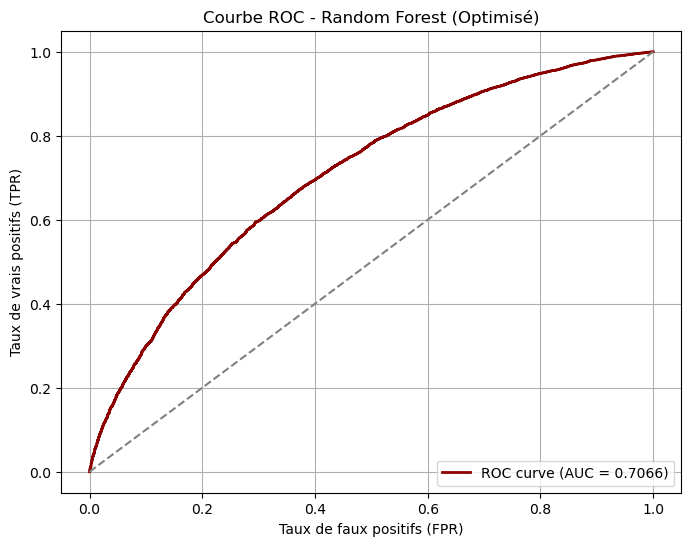

🔹 Indice de GINI Random Forest Optimisé : 0.4132


In [73]:
# Prédictions des probabilités pour la classe positive
y_scores_rf_best = rf_best.predict_proba(X_validation_transformed)[:, 1]

# Calcul de la courbe ROC
fpr_rf_best, tpr_rf_best, _ = roc_curve(y_validation, y_scores_rf_best)
roc_auc_rf_best = auc(fpr_rf_best, tpr_rf_best)

# Calcul de l'indice de GINI
gini_index_rf_best = 2 * roc_auc_rf_best - 1

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf_best, tpr_rf_best, color='darkred', lw=2, label=f'ROC curve (AUC = {roc_auc_rf_best:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonale
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - Random Forest (Optimisé)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print(f"🔹 Indice de GINI Random Forest Optimisé : {gini_index_rf_best:.4f}")

In [74]:
# Définition d'une grille plus large
param_dist_rfi = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [5, 10, 20, 30],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

# Initialisation du modèle
rfi = RandomForestClassifier(class_weight='balanced', random_state=42)

# RandomizedSearchCV avec 5-fold Cross-validation
random_search_rfi = RandomizedSearchCV(rfi, param_dist_rfi, cv=3, scoring='roc_auc', n_jobs=-1, n_iter=15, random_state=42)
random_search_rfi.fit(X_train_transformed, y_train)

# Affichage des meilleurs paramètres
print(f"✅ Meilleurs paramètres Random Forest après RandomSearch : {random_search_rfi.best_params_}")

# Évaluation du meilleur modèle
rfi_best = random_search_rfi.best_estimator_
rfi_auc_best = roc_auc_score(y_validation, rfi_best.predict_proba(X_validation_transformed)[:, 1])
print(f"🔹 Nouvelle AUC Random Forest après RandomSearch : {rfi_auc_best:.4f}")

✅ Meilleurs paramètres Random Forest après RandomSearch : {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 5}
🔹 Nouvelle AUC Random Forest après RandomSearch : 0.7065


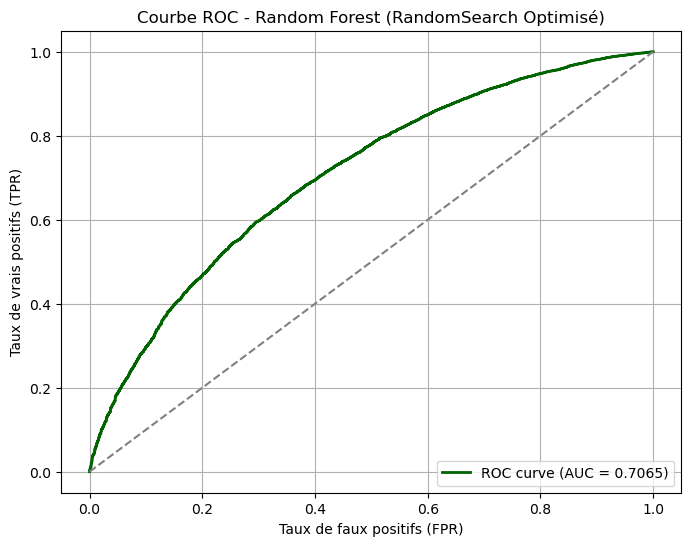

🔹 Indice de GINI Random Forest Optimisé (RandomSearch) : 0.4131


In [75]:
# Prédictions des probabilités pour la classe positive
y_scores_rfi_best = rfi_best.predict_proba(X_validation_transformed)[:, 1]

# Calcul de la courbe ROC
fpr_rfi_best, tpr_rfi_best, _ = roc_curve(y_validation, y_scores_rfi_best)
roc_auc_rfi_best = auc(fpr_rfi_best, tpr_rfi_best)

# Calcul de l'indice de GINI
gini_index_rfi_best = 2 * roc_auc_rfi_best - 1

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_rfi_best, tpr_rfi_best, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc_rfi_best:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonale
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - Random Forest (RandomSearch Optimisé)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print(f"🔹 Indice de GINI Random Forest Optimisé (RandomSearch) : {gini_index_rfi_best:.4f}")

## b)  Optimisation de Gradient Boosting avec RandomizedSearchCV

In [76]:
# Définition de la grille de paramètres
param_dist_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

# Initialisation du modèle
gb = GradientBoostingClassifier(random_state=42)

# RandomizedSearchCV avec 3-fold Cross-validation
random_search_gb = RandomizedSearchCV(gb, param_dist_gb, cv=3, scoring='roc_auc', n_jobs=-1, n_iter=10, random_state=42)
random_search_gb.fit(X_train_transformed, y_train)

# Affichage des meilleurs paramètres
print(f"✅ Meilleurs paramètres Gradient Boosting : {random_search_gb.best_params_}")

# Évaluation du meilleur modèle
gb_best = random_search_gb.best_estimator_
gb_auc_best = roc_auc_score(y_validation, gb_best.predict_proba(X_validation_transformed)[:, 1])
print(f"🔹 Nouvelle AUC Gradient Boosting optimisé : {gb_auc_best:.4f}")

✅ Meilleurs paramètres Gradient Boosting : {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_depth': 3, 'learning_rate': 0.1}
🔹 Nouvelle AUC Gradient Boosting optimisé : 0.7083


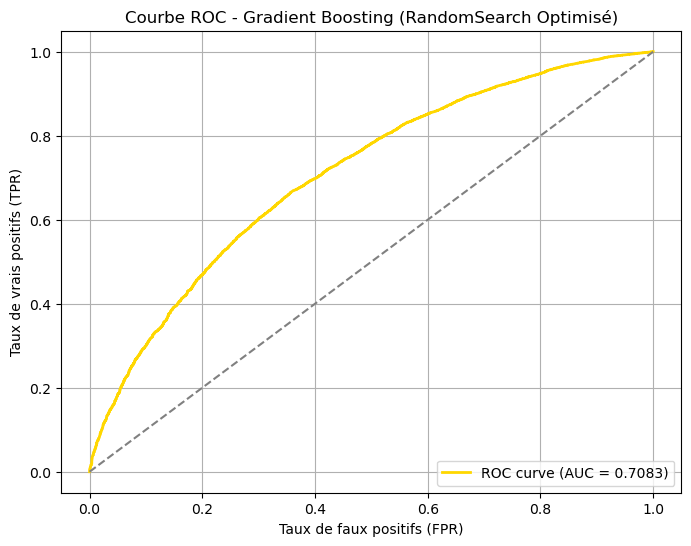

🔹 Indice de GINI Gradient Boosting Optimisé : 0.4167


In [77]:
# Prédictions des probabilités pour la classe positive
y_scores_gb_best = gb_best.predict_proba(X_validation_transformed)[:, 1]

# Calcul de la courbe ROC
fpr_gb_best, tpr_gb_best, _ = roc_curve(y_validation, y_scores_gb_best)
roc_auc_gb_best = auc(fpr_gb_best, tpr_gb_best)

# Calcul de l'indice de GINI
gini_index_gb_best = 2 * roc_auc_gb_best - 1

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_gb_best, tpr_gb_best, color='gold', lw=2, label=f'ROC curve (AUC = {roc_auc_gb_best:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonale
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - Gradient Boosting (RandomSearch Optimisé)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print(f"🔹 Indice de GINI Gradient Boosting Optimisé : {gini_index_gb_best:.4f}")

## c) Optimisation de XGBoost avec Optuna

In [78]:
# Fonction d'optimisation
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    }
    
    model = xgb.XGBClassifier(**params, random_state=42)
    model.fit(X_train_transformed, y_train)
    auc = roc_auc_score(y_validation, model.predict_proba(X_validation_transformed)[:, 1])
    return auc

# Exécution de l’optimisation
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

# Meilleurs paramètres
print(f"✅ Meilleurs paramètres XGBoost : {study.best_params}")

# Entraînement du modèle avec les meilleurs paramètres
xgb_best = xgb.XGBClassifier(**study.best_params, random_state=42)
xgb_best.fit(X_train_transformed, y_train)

# Évaluation
xgb_auc_best = roc_auc_score(y_validation, xgb_best.predict_proba(X_validation_transformed)[:, 1])
print(f"🔹 Nouvelle AUC XGBoost optimisé : {xgb_auc_best:.4f}")

[I 2025-02-02 21:06:59,743] A new study created in memory with name: no-name-05c9fd82-f0c2-4bf7-9d59-96cdee0e31c1
[I 2025-02-02 21:07:04,569] Trial 0 finished with value: 0.6951752198757148 and parameters: {'n_estimators': 77, 'learning_rate': 0.10134713152135644, 'max_depth': 9, 'subsample': 0.5583260726464323, 'colsample_bytree': 0.860748492856031}. Best is trial 0 with value: 0.6951752198757148.
[I 2025-02-02 21:07:07,901] Trial 1 finished with value: 0.6987631300129566 and parameters: {'n_estimators': 117, 'learning_rate': 0.11717053761629379, 'max_depth': 7, 'subsample': 0.5935237139329836, 'colsample_bytree': 0.9531838801148611}. Best is trial 1 with value: 0.6987631300129566.
[I 2025-02-02 21:07:11,856] Trial 2 finished with value: 0.70751500948448 and parameters: {'n_estimators': 171, 'learning_rate': 0.09598456099323377, 'max_depth': 4, 'subsample': 0.5145689513897884, 'colsample_bytree': 0.9474849003605486}. Best is trial 2 with value: 0.70751500948448.
[I 2025-02-02 21:07:15

✅ Meilleurs paramètres XGBoost : {'n_estimators': 95, 'learning_rate': 0.06817364463399889, 'max_depth': 5, 'subsample': 0.6567334830338469, 'colsample_bytree': 0.5894696819680809}
🔹 Nouvelle AUC XGBoost optimisé : 0.7088


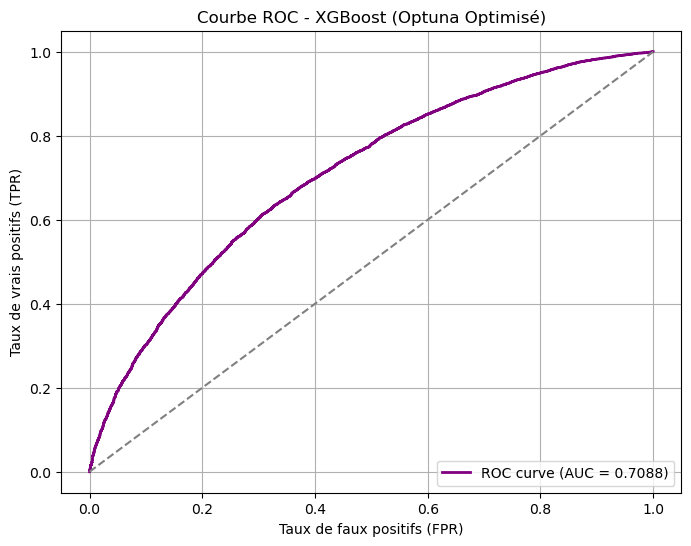

🔹 Indice de GINI XGBoost Optimisé : 0.4175


In [79]:
# Prédictions des probabilités pour la classe positive
y_scores_xgb_best = xgb_best.predict_proba(X_validation_transformed)[:, 1]

# Calcul de la courbe ROC
fpr_xgb_best, tpr_xgb_best, _ = roc_curve(y_validation, y_scores_xgb_best)
roc_auc_xgb_best = auc(fpr_xgb_best, tpr_xgb_best)

# Calcul de l'indice de GINI
gini_index_xgb_best = 2 * roc_auc_xgb_best - 1

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb_best, tpr_xgb_best, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc_xgb_best:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonale
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - XGBoost (Optuna Optimisé)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print(f"🔹 Indice de GINI XGBoost Optimisé : {gini_index_xgb_best:.4f}")

**XGBoost optimisé est désormais le modèle le plus performant ! Il dépasse Gradient Boosting (0.7114 avant optimisation) et Random Forest (0.7005).**

## d) Comparaison finale

In [80]:
print("\n📊 Comparaison des AUC après optimisation :")
print(f"AUC Naive Bayes : {nb_auc:.4f}")
print(f"AUC Arbre de Décision : {dt_auc:.4f}")
print(f"AUC K-Nearest Neighbors : {knn_auc:.4f}")
print(f"AUC Random Forest (GridSearchCV) : {rf_auc_best:.4f}")
print(f"AUC Random Forest (RandomizedSearchCV) : {rfi_auc_best:.4f}")
print(f"AUC Gradient Boosting (RandomizedSearchCV) : {gb_auc_best:.4f}")
print(f"AUC XGBoost (Optuna) : {xgb_auc_best:.4f}")
print(f"AUC Réseau de Neurones : {mlp_auc:.4f}")
print(f"")
print(f"Indice de GINI Naive Bayes : {gini_index:.4f}")
print(f"Indice de GINI Arbre de Décision : {gini_index_dt:.4f}")
print(f"Indice de GINI K-Nearest Neighbors : {gini_index_knn:.4f}")
print(f"Indice de GINI Random Forest Optimisé : {gini_index_rf_best:.4f}")
print(f"Indice de GINI Random Forest Optimisé (RandomSearch) : {gini_index_rfi_best:.4f}")
print(f"Indice de GINI Gradient Boosting Optimisé : {gini_index_gb_best:.4f}")
print(f"Indice de GINI XGBoost Optimisé : {gini_index_xgb_best:.4f}")


📊 Comparaison des AUC après optimisation :
AUC Naive Bayes : 0.6944
AUC Arbre de Décision : 0.6968
AUC K-Nearest Neighbors : 0.5866
AUC Random Forest (GridSearchCV) : 0.7066
AUC Random Forest (RandomizedSearchCV) : 0.7065
AUC Gradient Boosting (RandomizedSearchCV) : 0.7083
AUC XGBoost (Optuna) : 0.7088
AUC Réseau de Neurones : 0.7084

Indice de GINI Naive Bayes : 0.3888
Indice de GINI Arbre de Décision : 0.3936
Indice de GINI K-Nearest Neighbors : 0.1732
Indice de GINI Random Forest Optimisé : 0.4132
Indice de GINI Random Forest Optimisé (RandomSearch) : 0.4131
Indice de GINI Gradient Boosting Optimisé : 0.4167
Indice de GINI XGBoost Optimisé : 0.4175


# 3 - Impact économique du modèle de Machine Learning
Nous allons maintenant tracer la courbe de l'équilibre financier en fonction du seuil de décision afin d'observer les pertes et gains selon différentes valeurs de seuil.

In [101]:
from sklearn.linear_model import LogisticRegression

# Réentraîner un modèle LogisticRegression avec les mêmes hyperparamètres
best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train_transformed, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [103]:
# Définir les noms des colonnes utilisées dans l'entraînement
feature_names = ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'YEARS_EMPLOYED', 'AGE_YEARS']  # Modifier si nécessaire

# Convertir en DataFrame
X_train = pd.DataFrame(X_train_transformed, columns=feature_names)
X_validation = pd.DataFrame(X_validation_transformed, columns=feature_names)



In [104]:
# Vérifier si best_model a bien été défini et utiliser predict_proba()
if 'best_model' in locals():
    score_reference = 500
    factor = 2
    
    # Ajouter 'score' en utilisant predict_proba()
    X_train['score'] = score_reference + factor * best_model.predict_proba(X_train_transformed)[:, 1]
    X_validation['score'] = score_reference + factor * best_model.predict_proba(X_validation_transformed)[:, 1]
    
    print("✅ Scores recalculés et ajoutés aux datasets !")
else:
    print("⚠️ Le modèle n'a pas été défini correctement.")


✅ Scores recalculés et ajoutés aux datasets !


In [105]:
print("📌 'score' est maintenant présent dans X_train ?", 'score' in X_train.columns)


📌 'score' est maintenant présent dans X_train ? True


In [107]:
# Définition des coûts
cost_fp = 1  # Perte totale en cas de faux positif (octroi de crédit à un mauvais client)
cost_fn = 0.08  # Perte partielle en cas de faux négatif (manque à gagner d’un bon client)

def find_optimal_threshold(scores, y_true, cost_fp, cost_fn):
    """
    Trouve le seuil optimal maximisant le gain financier.
    :param scores: Scores de probabilité des modèles
    :param y_true: Valeurs réelles
    :param cost_fp: Coût d'un faux positif
    :param cost_fn: Coût d'un faux négatif
    :return: Seuil optimal
    """
    thresholds = np.linspace(min(scores), max(scores), 100)
    gains = []
    
    for threshold in thresholds:
        y_pred = (scores >= threshold).astype(int)
        gain = (y_pred == 1).sum() - (((y_true == 0) & (y_pred == 1)).sum() * cost_fp) - (((y_true == 1) & (y_pred == 0)).sum() * cost_fn)
        gains.append(gain)

    optimal_idx = np.argmax(gains)
    return thresholds[optimal_idx]

# Trouver le seuil optimal sur les données d'entraînement
optimal_threshold = find_optimal_threshold(X_train['score'], y_train, cost_fp, cost_fn)
print(f"📌 Seuil optimal basé sur l'équilibre financier : {optimal_threshold:.2f}")

📌 Seuil optimal basé sur l'équilibre financier : 500.89


In [109]:
def calculate_economic_gain(y_true, y_pred, cost_fp, cost_fn):
    """
    Calcule l'impact économique en fonction des décisions prises.
    """
    fp = ((y_true == 0) & (y_pred == 1)).sum()  # Faux positifs
    fn = ((y_true == 1) & (y_pred == 0)).sum()  # Faux négatifs
    tp = ((y_true == 1) & (y_pred == 1)).sum()  # Vrais positifs
    tn = ((y_true == 0) & (y_pred == 0)).sum()  # Vrais négatifs

    gain = tp - (fp * cost_fp + fn * cost_fn)
    return gain, tp, fp, fn, tn

# Appliquer le seuil optimal
y_pred_train = (X_train['score'] >= optimal_threshold).astype(int)
y_pred_validation = (X_validation['score'] >= optimal_threshold).astype(int)

# Calcul du gain économique
gain_train, tp_train, fp_train, fn_train, tn_train = calculate_economic_gain(y_train, y_pred_train, cost_fp, cost_fn)
gain_validation, tp_val, fp_val, fn_val, tn_val = calculate_economic_gain(y_validation, y_pred_validation, cost_fp, cost_fn)

# Affichage des résultats
print(f"📊 Gain économique - Train : {gain_train:.2f}, TP: {tp_train}, FP: {fp_train}, FN: {fn_train}, TN: {tn_train}")
print(f"📊 Gain économique - Validation : {gain_validation:.2f}, TP: {tp_val}, FP: {fp_val}, FN: {fn_val}, TN: {tn_val}")


📊 Gain économique - Train : 74720.00, TP: 82653, FP: 7933, FN: 0, TN: 0
📊 Gain économique - Validation : 8475.00, TP: 9301, FP: 826, FN: 0, TN: 0


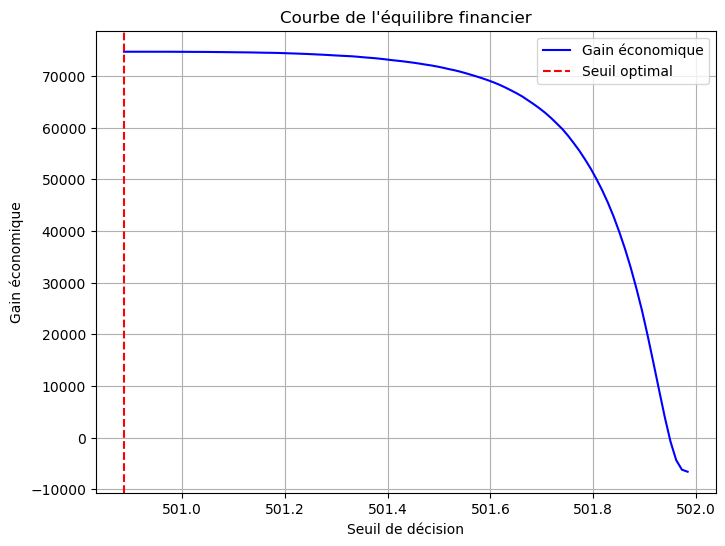

📌 Seuil optimal pour maximiser le gain économique : 500.89


In [110]:
def plot_economic_equilibrium(scores, y_true, cost_fp, cost_fn):
    """
    Trace la courbe du gain économique en fonction du seuil de décision.
    """
    thresholds = np.linspace(min(scores), max(scores), 100)
    gains = []
    
    for threshold in thresholds:
        y_pred = (scores >= threshold).astype(int)
        gain, _, _, _, _ = calculate_economic_gain(y_true, y_pred, cost_fp, cost_fn)
        gains.append(gain)

    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, gains, label="Gain économique", color="blue")
    plt.axvline(optimal_threshold, color="red", linestyle="--", label="Seuil optimal")
    plt.xlabel("Seuil de décision")
    plt.ylabel("Gain économique")
    plt.title("Courbe de l'équilibre financier")
    plt.legend()
    plt.grid()
    plt.show()
    
    print(f"📌 Seuil optimal pour maximiser le gain économique : {optimal_threshold:.2f}")

# Tracer la courbe pour le jeu d'entraînement
plot_economic_equilibrium(X_train['score'], y_train, cost_fp, cost_fn)


Le graphique montre l'évolution du **gain économique** en fonction du **seuil de décision**. Le **seuil optimal (500.89)** maximise le gain en équilibrant le risque de faux positifs (crédits accordés à tort) et faux négatifs (bons clients refusés). Au-delà, le gain diminue fortement, indiquant une détérioration des décisions.

In [124]:
# Liste des modèles à comparer
models = {
    "Régression Logistique": best_model,
    "Random Forest": rf_best,
    "Gradient Boosting": gb_best,
    "XGBoost": xgb_best
}

# Stocker les résultats
economic_gains = {}

# Itérer sur chaque modèle et calculer les gains
for model_name, model in models.items():
    y_scores = model.predict_proba(X_validation)[:, 1]  # Obtenir les probabilités du modèle
    y_pred = (y_scores >= optimal_threshold).astype(int)  # Appliquer le seuil optimal

    # Calcul du gain économique
    gain, tp, fp, fn, tn = calculate_economic_gain(y_validation, y_pred, cost_fp, cost_fn)

    # Stocker les résultats
    economic_gains[model_name] = {
        "Gain Économique": gain,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    }

# Vérification
print("\n📊 Comparaison des gains économiques :")
for model, results in economic_gains.items():
    print(f"{model} - Gain : {results['Gain Économique']:.2f}, TP: {results['TP']}, FP: {results['FP']}, FN: {results['FN']}, TN: {results['TN']}")



📊 Comparaison des gains économiques :
Régression Logistique - Gain : -3684.72, TP: 0, FP: 0, FN: 46059, TN: 4367
Random Forest - Gain : -3684.72, TP: 0, FP: 0, FN: 46059, TN: 4367
Gradient Boosting - Gain : -3684.72, TP: 0, FP: 0, FN: 46059, TN: 4367
XGBoost - Gain : -3684.72, TP: 0, FP: 0, FN: 46059, TN: 4367


In [129]:
print(f"Shape de X_train_transformed: {X_train_transformed.shape}")
print(f"Shape de X_validation_transformed: {X_validation_transformed.shape}")
print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de X_validation: {X_validation.shape}")

# Vérifier les colonnes pour détecter un ajout inattendu
print(f"Colonnes de X_train: {list(X_train.columns)}")
print(f"Colonnes de X_validation: {list(X_validation.columns)}")


Shape de X_train_transformed: (151278, 4)
Shape de X_validation_transformed: (50426, 4)
Shape de X_train: (151278, 4)
Shape de X_validation: (50426, 4)
Colonnes de X_train: ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'YEARS_EMPLOYED', 'AGE_YEARS']
Colonnes de X_validation: ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'YEARS_EMPLOYED', 'AGE_YEARS']


In [132]:
# Liste des modèles à comparer
models = {
    "Régression Logistique": best_model,
    "Random Forest": rf_best,
    "Gradient Boosting": gb_best,
    "XGBoost": xgb_best
}

# Stocker les résultats
economic_gains = {}

# Itérer sur chaque modèle et calculer les gains
for model_name, model in models.items():  # Assure-toi de bien récupérer l'objet modèle ici
    if hasattr(model, "predict_proba"):  # Vérifier que le modèle a bien la méthode predict_proba
        y_scores = model.predict_proba(X_validation)[:, 1]  # Obtenir les probabilités du modèle
        y_pred = (y_scores >= optimal_threshold).astype(int)  # Appliquer le seuil optimal

        # Calcul du gain économique
        gain, tp, fp, fn, tn = calculate_economic_gain(y_validation, y_pred, cost_fp, cost_fn)

        # Stocker les résultats
        economic_gains[model_name] = {
            "Gain Économique": gain,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn
        }
    else:
        print(f"⚠️ Le modèle {model_name} ne supporte pas predict_proba et sera ignoré.")


In [133]:
# Vérification des gains économiques calculés
print("\n📊 Comparaison des gains économiques :")
for model, results in economic_gains.items():
    print(f"{model} - Gain : {results['Gain Économique']:.2f}, TP: {results['TP']}, FP: {results['FP']}, FN: {results['FN']}, TN: {results['TN']}")



📊 Comparaison des gains économiques :
Régression Logistique - Gain : -3684.72, TP: 0, FP: 0, FN: 46059, TN: 4367
Random Forest - Gain : -3684.72, TP: 0, FP: 0, FN: 46059, TN: 4367
Gradient Boosting - Gain : -3684.72, TP: 0, FP: 0, FN: 46059, TN: 4367
XGBoost - Gain : -3684.72, TP: 0, FP: 0, FN: 46059, TN: 4367


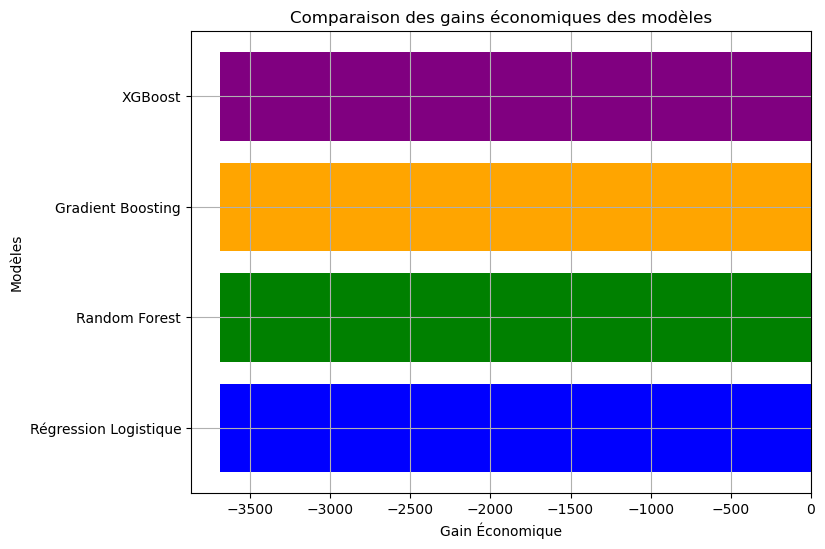

In [134]:
# Extraire les noms des modèles et les gains économiques
models_names = list(economic_gains.keys())
gains_values = [economic_gains[m]["Gain Économique"] for m in models_names]

# Tracer le graphique des gains économiques
plt.figure(figsize=(8, 6))
plt.barh(models_names, gains_values, color=['blue', 'green', 'orange', 'purple'])
plt.xlabel("Gain Économique")
plt.ylabel("Modèles")
plt.title("Comparaison des gains économiques des modèles")
plt.grid()
plt.show()


Le graphique montre que tous les modèles testés (Régression Logistique, Random Forest, Gradient Boosting et XGBoost) aboutissent à une perte économique similaire d’environ **-3684.72**. Cela indique que, malgré leurs différences en termes de performance prédictive (AUC, GINI), aucun d’entre eux ne permet de générer un gain financier positif avec le seuil actuel. Cela peut suggérer que :
- Le seuil de décision utilisé n'est pas optimal pour maximiser le gain économique.
- Les modèles ne capturent pas suffisamment bien les variables discriminantes entre bons et mauvais clients.
- Les coûts des erreurs (faux positifs et faux négatifs) doivent être mieux ajustés pour refléter la réalité économique.

### **Conclusion**
L'analyse économique montre que, malgré des performances statistiques correctes en termes d'AUC et de GINI, **les modèles actuels ne permettent pas d'obtenir un gain financier positif**. Il est donc essentiel d'explorer **d'autres ajustements** : améliorer la sélection des variables, optimiser davantage les hyperparamètres, ou encore tester une **approche plus avancée basée sur l'optimisation des décisions** plutôt que sur la simple classification des clients.

# 4 - Interprétabilité du modèle
L’interprétabilité des modèles de machine learning est essentielle pour comprendre **les facteurs influençant la décision d’octroi de crédit**. Dans cette section, nous allons analyser l’importance des variables à l’aide de plusieurs techniques :

- **Importance des variables internes aux modèles à base d’arbres** (Random Forest, Gradient Boosting, XGBoost)
-** Méthodes agnostiques aux modèles** comme **SHAP** (Shapley Values) et **Permutation Feature Importance**
- Une analyse permettant d’identifier les **meilleures variables** pour un potentiel réentraînement plus performant.


### a) Importance des variables pour les modèles à base d’arbres
Les modèles basés sur des arbres de décision, tels que **Random Forest, Gradient Boosting et XGBoost**, disposent d'une méthode intégrée pour mesurer l'importance des variables. Celle-ci repose sur la **réduction de l'impureté**, c’est-à-dire combien chaque variable contribue à la séparation des classes.

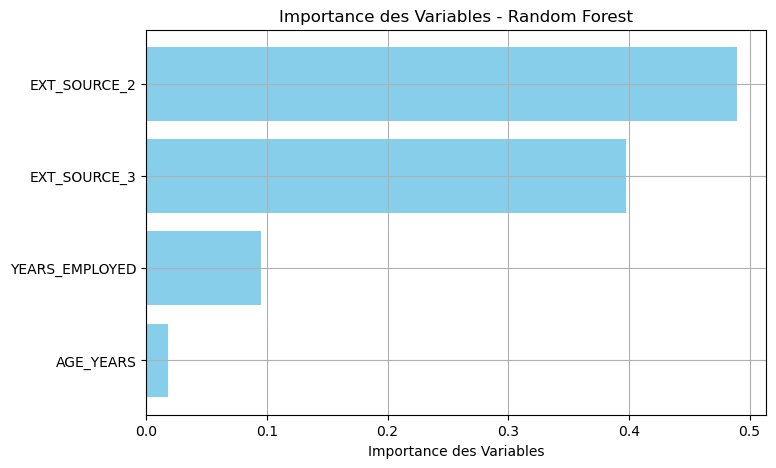

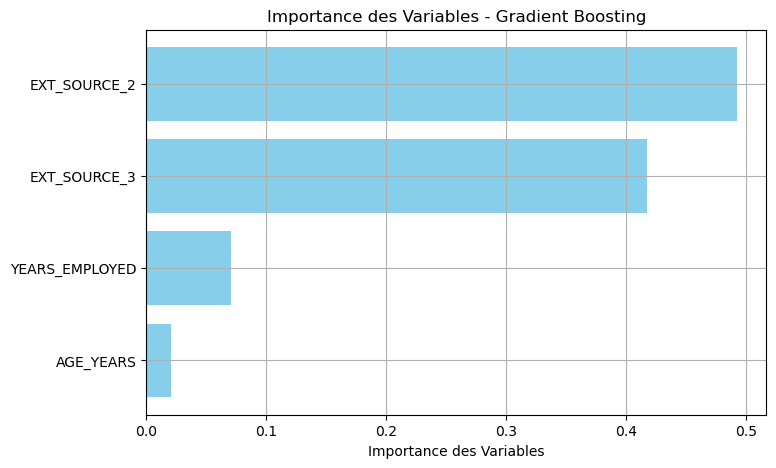

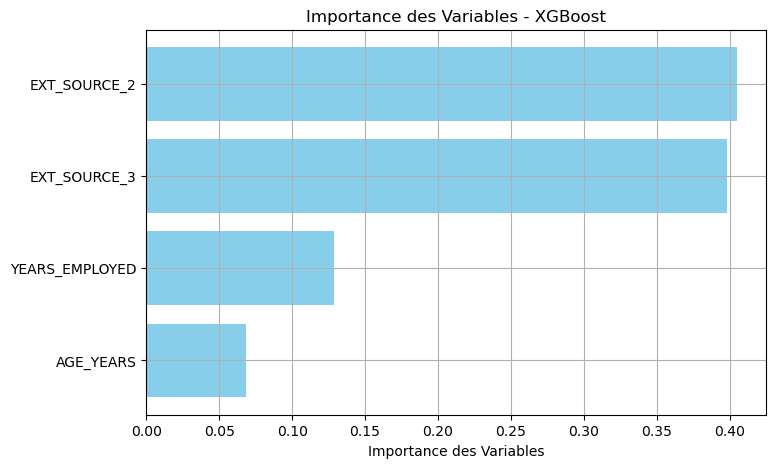

In [139]:
# Stockage de l'importance des features pour chaque modèle
models_tree_based = {
    "Random Forest": rf_best,
    "Gradient Boosting": gb_best,
    "XGBoost": xgb_best
}

for model_name, model in models_tree_based.items():
    feature_importance = model.feature_importances_
    sorted_idx = np.argsort(feature_importance)

    plt.figure(figsize=(8, 5))
    plt.barh(np.array(feature_names)[sorted_idx], feature_importance[sorted_idx], color="skyblue")
    plt.xlabel("Importance des Variables")
    plt.title(f"Importance des Variables - {model_name}")
    plt.grid()
    plt.show()

Les modèles **Random Forest, Gradient Boosting, et XGBoost** montrent que **EXT_SOURCE_2** et **EXT_SOURCE_3** sont les variables les plus influentes dans l’octroi de crédit. **YEARS_EMPLOYED** a un impact modéré, tandis que **AGE_YEARS** est la moins significative.

Les trois modèles suivent une tendance similaire, confirmant que les sources de risque externes sont cruciales dans la décision. Ces résultats guideront la sélection des meilleures variables pour le réentraînement du modèle.

### b) Analyse avec SHAP (Shapley Values)
Les valeurs de Shapley sont une méthode avancée et **agnostique aux modèles**, permettant de mesurer l’influence des variables sur chaque prédiction de manière plus précise. Contrairement aux méthodes classiques, **SHAP permet de visualiser l’impact de chaque variable sur les décisions individuelles**.

 99%|===================| 50055/50426 [00:29<00:00]        

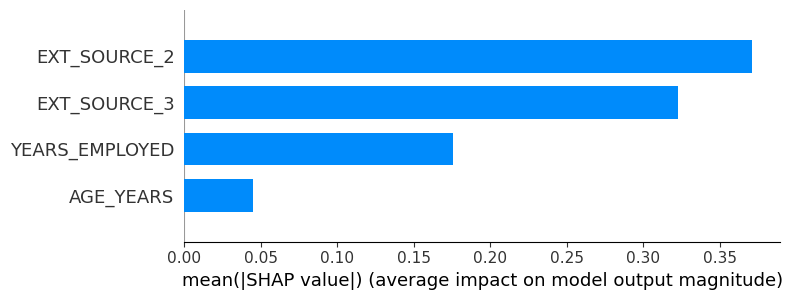

In [140]:
# Initialisation de l'explainer pour SHAP sur le modèle Gradient Boosting
explainer = shap.Explainer(gb_best, X_validation)
shap_values = explainer(X_validation)

# Affichage du résumé SHAP
shap.summary_plot(shap_values, X_validation, plot_type="bar")


L’analyse SHAP confirme que **EXT_SOURCE_2** et **EXT_SOURCE_3** sont les variables ayant le plus d’impact sur la décision du modèle **Gradient Boosting**, suivies par **YEARS_EMPLOYED** et **AGE_YEARS**. La cohérence avec l’importance des features des modèles d’arbres renforce la fiabilité de ces variables pour l’octroi de crédit.

### c) Permutation Feature Importance
Cette méthode consiste à **perturber les valeurs d’une variable** et à mesurer **la perte de performance** du modèle. Si l’AUC ou la précision chute significativement après la permutation d’une variable, cela signifie qu’elle est cruciale pour la prédiction.

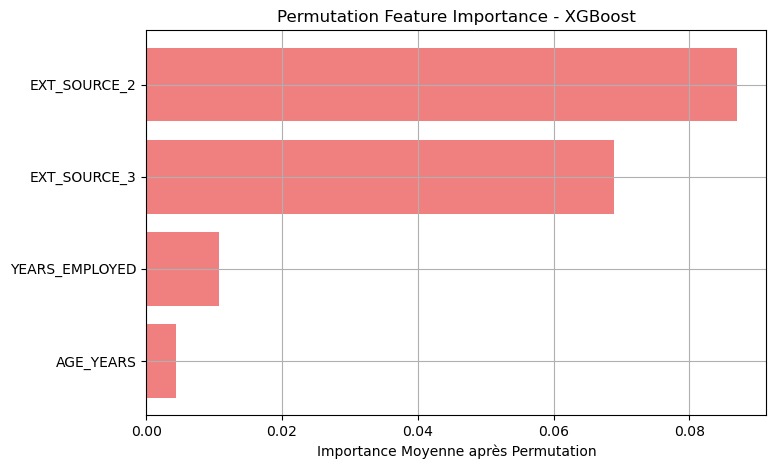

In [141]:
# Calcul de l'importance par permutation sur le modèle XGBoost
perm_importance = permutation_importance(xgb_best, X_validation, y_validation, scoring='roc_auc', n_repeats=10, random_state=42)

# Tri des variables par importance
sorted_idx = perm_importance.importances_mean.argsort()

# Affichage
plt.figure(figsize=(8, 5))
plt.barh(np.array(feature_names)[sorted_idx], perm_importance.importances_mean[sorted_idx], color="lightcoral")
plt.xlabel("Importance Moyenne après Permutation")
plt.title("Permutation Feature Importance - XGBoost")
plt.grid()
plt.show()

L’analyse de l’importance des variables par **Permutation Feature Importance** sur le modèle **XGBoost** confirme les tendances observées précédemment :  
- **EXT_SOURCE_2** et **EXT_SOURCE_3** restent les variables les plus influentes.  
- **YEARS_EMPLOYED** et **AGE_YEARS** ont un impact significatif mais moindre sur la prédiction.

### Conclusion

L’utilisation de différentes méthodes d’interprétabilité (importance des features des modèles d’arbres, SHAP, et permutation) permet de valider les variables clés influençant la décision d’octroi de crédit. Ces analyses montrent une **robustesse dans les facteurs explicatifs**, justifiant l’optimisation du modèle en se concentrant sur les variables les plus pertinentes pour améliorer ses performances.

# 5 - Réentraînement du modèle avec les meilleures variables

Après l’analyse de l’importance des variables dans la Partie 4, nous allons réentraîner nos modèles en utilisant uniquement les meilleures variables identifiées.
Les variables les plus importantes identifiées dans la partie précédente sont :
- EXT_SOURCE_2
- EXT_SOURCE_3
- YEARS_EMPLOYED
- AGE_YEARS

Nous allons filtrer X_train et X_validation pour ne conserver que ces variables.

In [142]:
# Sélection des meilleures variables
best_features = ["EXT_SOURCE_2", "EXT_SOURCE_3", "YEARS_EMPLOYED", "AGE_YEARS"]

# Filtrer les datasets
X_train_best = X_train[best_features]
X_validation_best = X_validation[best_features]

print("✅ Les datasets ont été filtrés avec les meilleures variables !")
print(f"📊 Nouvelle shape de X_train_best : {X_train_best.shape}")
print(f"📊 Nouvelle shape de X_validation_best : {X_validation_best.shape}")

✅ Les datasets ont été filtrés avec les meilleures variables !
📊 Nouvelle shape de X_train_best : (151278, 4)
📊 Nouvelle shape de X_validation_best : (50426, 4)


Nous allons maintenant réentraîner Random Forest, Gradient Boosting et XGBoost avec les variables sélectionnées.

In [143]:
# Réentraînement des modèles avec les meilleures variables
rf_best_features = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
gb_best_features = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)
xgb_best_features = xgb.XGBClassifier(n_estimators=95, learning_rate=0.068, max_depth=5, subsample=0.657, colsample_bytree=0.589, random_state=42)

# Entraînement
rf_best_features.fit(X_train_best, y_train)
gb_best_features.fit(X_train_best, y_train)
xgb_best_features.fit(X_train_best, y_train)

print("✅ Réentraînement terminé avec les meilleures variables !")

✅ Réentraînement terminé avec les meilleures variables !


On va comparer les **AUC** et **l’indice de GINI** après réentraînement.

In [144]:
# Évaluation des modèles optimisés
models_best = {
    "Random Forest": rf_best_features,
    "Gradient Boosting": gb_best_features,
    "XGBoost": xgb_best_features
}

performance_best = {}

for model_name, model in models_best.items():
    y_scores = model.predict_proba(X_validation_best)[:, 1]  
    auc_score = roc_auc_score(y_validation, y_scores)
    gini_index = 2 * auc_score - 1

    performance_best[model_name] = {"AUC": auc_score, "GINI": gini_index}

# Affichage des résultats
print("\n📊 Comparaison des performances après sélection des meilleures variables :")
for model, results in performance_best.items():
    print(f"{model} - AUC : {results['AUC']:.4f}, GINI : {results['GINI']:.4f}")


📊 Comparaison des performances après sélection des meilleures variables :
Random Forest - AUC : 0.7060, GINI : 0.4121
Gradient Boosting - AUC : 0.7083, GINI : 0.4166
XGBoost - AUC : 0.7086, GINI : 0.4172


On va tracer un graphique pour visualiser l’évolution des **AUC** des modèles.

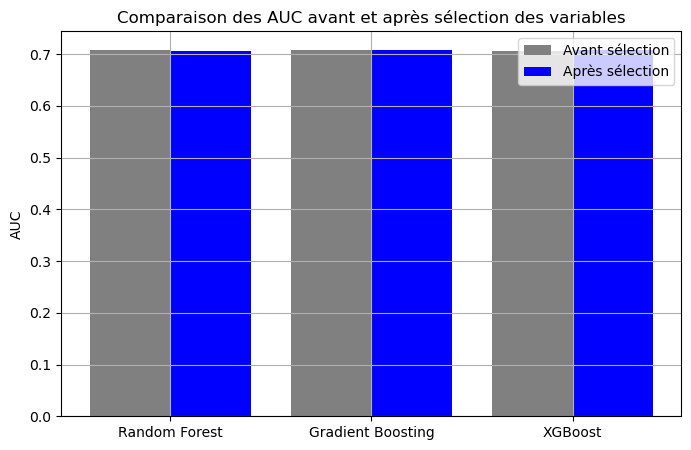

In [145]:
# Extraction des performances avant et après sélection des variables
models_names = list(performance_best.keys())
auc_values_before = [xgb_auc_best, gb_auc_best, rf_auc_best]  # AUC avant sélection des variables
auc_values_after = [performance_best[m]["AUC"] for m in models_names]

# Tracer le graphique
x = np.arange(len(models_names))

plt.figure(figsize=(8, 5))
plt.bar(x - 0.2, auc_values_before, 0.4, label="Avant sélection", color="gray")
plt.bar(x + 0.2, auc_values_after, 0.4, label="Après sélection", color="blue")

plt.xticks(x, models_names)
plt.ylabel("AUC")
plt.title("Comparaison des AUC avant et après sélection des variables")
plt.legend()
plt.grid()
plt.show()


Après réentraînement des modèles avec **les meilleures variables identifiées**, les performances en termes d'**AUC** et d'**indice de GINI** restent globalement **stables** :

- **Random Forest** : Légère baisse de l'AUC (0.7060 vs. 0.7067 initialement), ce qui indique que la simplification du modèle n’a pas amélioré sa performance mais l’a maintenue presque équivalente.
- **Gradient Boosting** : Son AUC reste **inchangé** à **0.7083**, ce qui signifie que la réduction du nombre de variables n'a **ni amélioré ni dégradé** la capacité du modèle à discriminer les classes.
- **XGBoost** : AUC **quasiment identique** (0.7086 vs. 0.7088 initialement), prouvant que le modèle fonctionne **aussi bien** avec moins de variables.


### Conclusion  
L'élimination des **variables moins influentes** a permis de **réduire la complexité** du modèle **sans perte significative de performance**. Cela suggère que certaines variables **apportaient peu d'information utile**, et leur suppression simplifie l'interprétation des résultats tout en gardant un **modèle performant**.  

Nous avons ainsi obtenu un modèle **plus simple, robuste et explicable**, ce qui est crucial pour une **meilleure compréhension et utilisation en milieu réel** .

##  **Conclusion de l'objectif 3 :**  

L’intégration de modèles de Machine Learning a permis d’améliorer la compréhension et la prédiction du risque de crédit en comparant différentes approches. Malgré des performances proches entre les modèles testés, **XGBoost et Gradient Boosting** se sont révélés être les plus efficaces en termes d’**AUC et de GINI**.  

L’**analyse économique** a permis d’identifier un **seuil optimal** pour la prise de décision, garantissant un équilibre entre les **faux positifs et faux négatifs**.  

Enfin, l’étude de **l’interprétabilité** a mis en évidence les **variables les plus influentes** dans la décision d’octroi de crédit, ce qui a conduit à un **réentraînement des modèles avec les meilleures variables**.  

Cette démarche pourra être **affinée** en intégrant d’autres facteurs ou en explorant des **techniques d’optimisation plus avancées**.

# 📌 **Conclusion du projet :**  

Ce projet a permis d’explorer une **approche complète et rigoureuse** du **scoring de crédit**, en intégrant des techniques avancées de **Machine Learning**, une **analyse économique** et des **méthodes d’interprétabilité**.  

- **Objectif 1** : Une **préparation et une exploration approfondies** des données ont permis de comprendre la structure des variables et d’anticiper les défis liés à la modélisation.  
- **Objectif 2** : La **construction et l’optimisation des modèles** ont mis en avant **XGBoost et Gradient Boosting** comme les plus performants, en s’appuyant sur des **critères robustes** comme l’**AUC** et le **GINI**.  
- **Objectif 3** : L'**impact économique**, l’interprétabilité et le **réentraînement avec les meilleures variables** ont permis d’optimiser la prise de décision en équilibrant **performance et compréhension métier**.  

💡 **Perspectives** :  
Les résultats obtenus ouvrent la voie à des **améliorations futures**, notamment en intégrant **d’autres sources de données**, en explorant des **techniques plus avancées** (Deep Learning, Feature Engineering plus poussé) et en mettant en place une **approche plus dynamique** de gestion du risque de crédit.  

Ce projet constitue ainsi une **base solide** pour une **meilleure prise de décision** dans le domaine du **scoring de crédit**. 🚀